# Marketing Lead-Gen Funnel & ROI — FY 2025 (v3)

<img src="logo-footer.svg" height="22" style="filter:invert(1);opacity:.75;vertical-align:middle;margin-right:8px">
*Task 1 · Data aggregation & analysis — SOFTSWISS Marketing Analyst test assignment*

This notebook is the single source of truth for the analysis: it reads the raw workbook, audits every
join before trusting it, resolves the lead-duplication question with data instead of assumption, builds
one working dataset, and derives the funnel, ROI/ROAS and forecast that back the final report. Every
number below is computed live in this notebook — nothing is pasted in.

**v2 changes:** every data-integrity question is now checked *before* the working dataset is built -
does every SAL row have an MQL (checked two ways), does any lead have two Signed deals, is the
Signed↔SAL join by (Brand,Product) ever unsafe (with a diagram and a worked toy example) - plus a new
payback-horizon analysis (Section 10) that answers whether paid media pays back at all, and whether this
dataset has any real repeat-purchase population to build an LTV curve on.

**v3 changes:** Section 2 now shows the raw first look at each tab (`first_check()`) before any of the
audit work in Section 3-4 - the messy starting point, not just the cleaned-up conclusions. Section 8 adds
days-to-conversion by channel, a Signed-within-30/60/90-day table, and a monthly paid-vs-unpaid
leads/CPL/ROAS breakdown that directly tests whether the H2 spend cut was offset by organic volume.
Section 9's channel economics table adds CAC. Section 11 adds three hypotheses this dataset cannot settle
on its own - incrementality, channel halo effects on organic/branded search, and repeat-customer share -
with what data would be needed to test each one.


### Contents
1. [Setup & style](#1)
2. [Load the raw tabs](#2) · 2.1 first look at each tab, before any cleaning
3. [EDA — the "second visit" duplicates, and the full audit](#3) · done before any joining
4. [EDA — is Brand Name hiding two sales as one?](#4) · done before any joining
5. [Cleaning](#5)
6. [Build the working dataset](#6)
7. [Reconciliation](#7)
8. [Funnel over time](#8) · shape, stage lags (incl. is MQL→SAL lag fixable or structural), days-to-conversion by channel, cohort windows, calendar vs. cohort, every metric monthly, the September Lead→MQL dip, quarterly dynamics, paid-vs-unpaid by month
9. [ROI / ROAS](#9) · channel, product, region, CAC, and where each channel actually loses people
10. [Payback horizon & repeat-purchase (LTV) analysis](#10) · by product, region, channel
11. [Hypotheses](#11) · what's really driving the paid CPL/ROAS problem, and what we still can't test
12. [Anomalies](#12)
13. [Forecast & scenarios](#13)
14. [Findings & recommendations](#14)
15. [Addressing known limitations](#15) · uncertainty, confounding, incrementality proxy, revenue concentration, September significance test, MQL→SAL lag trend, A/B-test readiness, SLA-test sample size


<a id="1"></a>
## 1. Setup & style

Colour is reserved for charts and tables, where it carries information (which bar is the outlier, which cell is the maximum). Narrative text below is plain markdown - no inline colour, so it reads like a normal analysis, not a slide deck.

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from plotly import graph_objects as go
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# ---------------------------------------------------------------------------- brand kit
BG      = "#000000"   # background
INK     = "#f2f2f2"   # primary text / lines
MUTED   = "#6f6f6f"   # neutral series - the default colour for "just data"
GRID    = "#242424"
ORANGE  = "#ffaa00"   # highlight: the thing to look at first / positive
RED     = "#e80037"   # highlight: risk / below breakeven / negative
FAINT   = "#3a3a3a"
CMAP    = LinearSegmentedColormap.from_list("softswiss", ["#151515", ORANGE])

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": "#bdbdbd", "ytick.color": "#bdbdbd",
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.grid": True, "axes.axisbelow": True,
    "font.size": 11, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.labelcolor": INK,
})


def eur(x, pos=None):
    return f"€{x:,.0f}"


def style_funnel(fig, title):
    fig.update_layout(
        paper_bgcolor=BG, plot_bgcolor=BG, font=dict(color=INK, size=12.5),
        title=dict(text=title, font=dict(color=INK, size=14), x=0, xanchor="left"),
        margin=dict(t=55, l=10, r=10, b=10),
        legend=dict(font=dict(color=INK)),
        funnelgap=0.03,
    )
    fig.update_yaxes(color=INK)
    fig.update_xaxes(color=INK, gridcolor=GRID)
    fig.show()


def note(text, kind="finding"):
    label = {"finding": "**Finding.**", "risk": "**Risk.**", "info": "**Note.**",
             "hypothesis": "**Hypothesis.**", "decision": "**Decision.**",
             "method": "**Method.**"}[kind]
    display(Markdown(f"{label} {text}"))


def show(df, caption=None, n=None, highlight_col=None, highlight="max",
         flag_col=None, flag_colors=None):
    d = df.head(n) if n else df
    sty = d.style.set_caption(caption or "").hide(axis="index")
    sty = sty.set_table_styles([
        {"selector": "caption", "props": [("color", ORANGE), ("font-weight", "600"),
                                          ("font-size", "13px"), ("text-align", "left"),
                                          ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("background-color", "#151515"), ("color", ORANGE),
                                     ("border", f"1px solid {FAINT}"), ("font-size", "12.5px"),
                                     ("padding", "6px 10px")]},
        {"selector": "td", "props": [("background-color", BG), ("color", INK),
                                     ("border", f"1px solid {FAINT}"), ("font-size", "12.5px"),
                                     ("padding", "5px 10px")]},
    ])
    if highlight_col is not None:
        color = ORANGE if highlight == "max" else RED
        func = "max" if highlight == "max" else "min"
        sty = sty.apply(lambda s: [f"color:{color};font-weight:700" if v == getattr(s, func)()
                                   else "" for v in s], subset=[highlight_col])
    if flag_col is not None and flag_colors is not None:
        def _f(v):
            for key, css in flag_colors.items():
                if key in str(v):
                    return css
            return ""
        sty = sty.map(_f, subset=[flag_col])
    display(sty)


SRC = "Test task_Marketing Analyst_Final.xlsx"
PAID = ["google / cpc", "facebook / cpc", "facebook / cpm", "linkedin.com / referral"]
COUNTRY_TO_REGION = {"United States": "US", "Brazil": "LatAm", "Argentina": "LatAm",
                     "Mexico": "LatAm", "Germany": "Europe", "Spain": "Europe", "Ukraine": "Europe"}
print("Setup complete.")


Setup complete.


<a id="2"></a>
## 2. Load the raw tabs

Five tabs, no shared key. They chain `Leads.ID -> MQL.ID -> SAL.ID -> SAL.(Brand,Product) -> Signed.(Brand,Product)`, while `Spend` lives on a totally different grain: `(Month, Source/Medium, Product, Region)`. Nothing is deduplicated or joined yet - this is a first look at each tab as delivered.

In [2]:

xl = pd.ExcelFile(SRC)
leads_raw = xl.parse("Leads")
mql_raw   = xl.parse("MQL")
sal_raw   = xl.parse("SAL")
signed_raw = xl.parse("Signed")
spend_raw = xl.parse("Spend")

overview = pd.DataFrame([
    {"Tab": "Leads",  "Rows": len(leads_raw),  "Columns": ", ".join(leads_raw.columns)},
    {"Tab": "MQL",    "Rows": len(mql_raw),    "Columns": ", ".join(mql_raw.columns)},
    {"Tab": "SAL",    "Rows": len(sal_raw),    "Columns": ", ".join(sal_raw.columns)},
    {"Tab": "Signed", "Rows": len(signed_raw), "Columns": ", ".join(signed_raw.columns)},
    {"Tab": "Spend",  "Rows": len(spend_raw),  "Columns": ", ".join(spend_raw.columns)},
])
show(overview, "The five source tabs")


Tab,Rows,Columns
Leads,8930,"Date, ID, Session Source / Medium, Product, Location"
MQL,4694,"MQL Conversion Date, ID, Product"
SAL,789,"Product, SAL created date, Brand Name, ID"
Signed,111,"Product, Brand Name, Month, Deal Value, EUR"
Spend,1321,"Month, Session Source / Medium, Product, Region, Spend"


In [3]:

null_check = pd.DataFrame({
    "Tab": ["Leads", "MQL", "SAL", "Signed", "Spend"],
    "Full-row duplicates": [leads_raw.duplicated().sum(), mql_raw.duplicated().sum(),
                            sal_raw.duplicated().sum(), signed_raw.duplicated().sum(),
                            spend_raw.duplicated().sum()],
    "Null cells": [leads_raw.isna().sum().sum(), mql_raw.isna().sum().sum(),
                  sal_raw.isna().sum().sum(), signed_raw.isna().sum().sum(),
                  spend_raw.isna().sum().sum()],
})
show(null_check, "Clean in the obvious ways: no full-row duplicates, no nulls anywhere")


Tab,Full-row duplicates,Null cells
Leads,0,0
MQL,0,0
SAL,0,0
Signed,0,0
Spend,0,0


### 2.1 First look - each tab, before any cleaning

Before auditing anything specific, the standard first pass over a new dataset: shape, dtypes, summary stats and duplicate count for each tab exactly as delivered. This is what turns up the headline data-quality questions that Sections 3-4 then go and resolve properly.

In [4]:

def first_check(dataframe):  #function of standard dataframe baseline check
     (display('Table cap:'),
            display(dataframe.head(5)),
            display('__________________________________________________ '),
            display(' '),
            display('Table info:'),
            display(dataframe.info()),
            display('__________________________________________________ '),
            display(' '),
            display('Method Describe:'),
            display(dataframe.describe()),
            display('__________________________________________________ '),
            display(' '),
            display('Numbers of duplicates:'),
            display(dataframe.duplicated().sum()),
            display('__________________________________________________ '),
            display(' '),
            display('Most popular values in dataframe by column'),
            display(dataframe.value_counts()))


In [5]:

first_check(leads_raw)


'Table cap:'

,Date,ID,Session Source / Medium,Product,Location
0,2025.01.01,L06520,facebook / cpc,Product 4,Germany
1,2025.02.12,L00002,facebook / cpc,Product 2,Argentina
2,2025.01.01,L03456,google / cpc,Product 4,United States
3,2025.01.01,L08182,(direct) / (none),Product 4,Argentina
4,2025.01.01,L01006,google / organic,Product 2,Germany


'__________________________________________________ '

' '

'Table info:'

...

np.int64(0)

'__________________________________________________ '

' '

'Most popular values in dataframe by column'

Date        ID      Session Source / Medium  Product    Location     
2025.01.01  L06520  facebook / cpc           Product 4  Germany          1
2025.02.12  L00002  facebook / cpc           Product 2  Argentina        1
2025.01.01  L03456  google / cpc             Product 4  United States    1
            L08182  (direct) / (none)        Product 4  Argentina        1
            L01006  google / organic         Product 2  Germany          1
                                                                        ..
2025.12.31  L03058  google / organic         Product 3  Argentina        1
2025.01.28  L08839  facebook / cpm           Product 4  Ukraine          1
2025.12.31  L03678  google / organic         Product 5  Argentina        1
2025.11.29  L02682  google / organic         Product 1  Brazil           1
2025.03.26  L08841  (direct) / (none)        Product 5  United States    1
Name: count, Length: 8930, dtype: int64

8930 total ID and 8841 unique - means we have duplicates.

In [6]:

first_check(mql_raw)


'Table cap:'

,MQL Conversion Date,ID,Product
0,2025.02.16,L00002,Product 2
1,2025.08.12,L00004,Product 3
2,2025.04.18,L00008,Product 2
3,2025.02.27,L06564,Product 1
4,2025.07.04,L00016,Product 4


'__________________________________________________ '

' '

'Table info:'

...

np.int64(0)

'__________________________________________________ '

' '

'Most popular values in dataframe by column'

MQL Conversion Date  ID      Product  
2025.02.16           L00002  Product 2    1
2025.08.12           L00004  Product 3    1
2025.04.18           L00008  Product 2    1
2025.02.27           L06564  Product 1    1
2025.07.04           L00016  Product 4    1
                                         ..
2025.05.21           L08828  Product 2    1
2025.01.07           L08833  Product 2    1
2025.02.06           L08839  Product 4    1
2025.03.28           L08841  Product 5    1
                             Product 3    1
Name: count, Length: 4694, dtype: int64

In [7]:

first_check(sal_raw)


'Table cap:'

,Product,SAL created date,Brand Name,ID
0,Product 3,2025.12.13,AYV,L05401
1,Product 1,2025.06.18,ABN,L03797
2,Product 1,2025.05.24,ABQ,L01896
3,Product 2,2025.08.31,AJH,L06715
4,Product 2,2025.06.18,AKF,L00173


'__________________________________________________ '

' '

'Table info:'

...

np.int64(0)

'__________________________________________________ '

' '

'Most popular values in dataframe by column'

Product    SAL created date  Brand Name  ID    
Product 3  2025.12.13        AYV         L05401    1
Product 1  2025.06.18        ABN         L03797    1
           2025.05.24        ABQ         L01896    1
Product 2  2025.08.31        AJH         L06715    1
           2025.06.18        AKF         L00173    1
                                                  ..
Product 1  2025.03.28        ABY         L08261    1
Product 4  2025.09.11        AOG         L05518    1
Product 3  2025.09.20        AZM         L08227    1
Product 1  2025.07.10        ARU         L08514    1
Product 4  2025.08.10        ABN         L03066    1
Name: count, Length: 789, dtype: int64

In [8]:

first_check(signed_raw)


'Table cap:'

,Product,Brand Name,Month,"Deal Value, EUR"
0,Product 1,APH,7,27900
1,Product 1,AKJ,5,30700
2,Product 1,ACE,1,32600
3,Product 1,AEW,5,32400
4,Product 1,AGY,5,28100


'__________________________________________________ '

' '

'Table info:'

...

np.int64(0)

'__________________________________________________ '

' '

'Most popular values in dataframe by column'

Product    Brand Name  Month  Deal Value, EUR
Product 1  APH         7      27900              1
           AKJ         5      30700              1
           ACE         1      32600              1
           AEW         5      32400              1
           AGY         5      28100              1
                                                ..
Product 5  AP          3      35800              1
           ANN         3      34100              1
           AHT         10     34700              1
           AAD         3      33300              1
           AYU         4      33900              1
Name: count, Length: 111, dtype: int64

In [9]:

signed_raw['Deal Value, EUR'].sum()


np.int64(2547100)

**2.2 Spend**

In [10]:

first_check(spend_raw)


'Table cap:'

,Month,Session Source / Medium,Product,Region,Spend
0,1,(direct) / (none),Product 1,Europe,0 EUR
1,1,(direct) / (none),Product 1,LatAm,0 EUR
2,1,(direct) / (none),Product 1,US,0 EUR
3,1,(direct) / (none),Product 2,Europe,0 EUR
4,1,(direct) / (none),Product 2,LatAm,0 EUR


'__________________________________________________ '

' '

'Table info:'

...

np.int64(0)

'__________________________________________________ '

' '

'Most popular values in dataframe by column'

Month  Session Source / Medium  Product    Region  Spend  
1      (direct) / (none)        Product 1  Europe  0 EUR      1
                                           LatAm   0 EUR      1
                                           US      0 EUR      1
                                Product 2  Europe  0 EUR      1
                                           LatAm   0 EUR      1
                                                             ..
12     linkedin.com / referral  Product 4  Europe  155 EUR    1
                                           LatAm   245 EUR    1
                                Product 5  Europe  165 EUR    1
                                           LatAm   515 EUR    1
                                           US      150 EUR    1
Name: count, Length: 1321, dtype: int64

In [11]:

# Check the last 3 characters to confirm it's always "EUR"
spend_raw['Spend'].str[-3:].unique()


<StringArray>
['EUR']
Length: 1, dtype: str

Good. no need to correction

In [12]:

spend_raw['Spend'] = (
    spend_raw['Spend']
    .str.replace(' EUR', '', regex=False)
    .str.strip()
    .astype(int)
)


<a id="3"></a>
## 3. EDA — the "second visit" duplicates, and the full audit

Leads has 8,930 rows but the funnel brief talks about *leads*, so the first real question is: **is a row in `Leads` a lead, or a visit?** This has to be settled before anything else is joined, because it decides the denominator of every CPL, and it decides which channel gets credit for a lead that shows up more than once. Every stage-relationship question that could break the working dataset (SAL without MQL, a lead with two purchases) is also checked here, before Section 6 builds anything.

In [13]:

n_rows, n_ids = len(leads_raw), leads_raw["ID"].nunique()
note(f"{n_rows:,} rows vs {n_ids:,} unique IDs → **{n_rows-n_ids} IDs repeat**. "
     "A row in `Leads` is a touchpoint, not a lead. The lead is the ID.")


**Finding.** 8,930 rows vs 8,841 unique IDs → **89 IDs repeat**. A row in `Leads` is a touchpoint, not a lead. The lead is the ID.

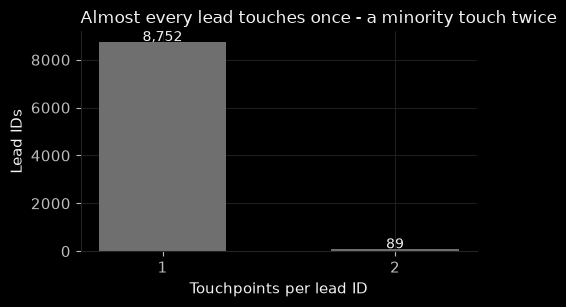

89 lead IDs appear more than once (all exactly twice - no triples).


In [14]:

leads = leads_raw.copy()
leads["dt"] = pd.to_datetime(leads["Date"], format="%Y.%m.%d")
leads["region"] = leads["Location"].map(COUNTRY_TO_REGION)
assert leads["region"].notna().all(), "unmapped country"

leads_sorted = leads.sort_values(["ID", "dt"])
leads_sorted["visit_no"] = leads_sorted.groupby("ID").cumcount() + 1
touch_counts = leads_sorted.groupby("ID").size()

fig, ax = plt.subplots(figsize=(5, 3.2))
vc = touch_counts.value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color=MUTED, width=0.55)
for i, v in enumerate(vc.values):
    ax.text(i, v + 30, f"{v:,}", ha="center", color=INK, fontsize=10)
ax.set_xlabel("Touchpoints per lead ID"); ax.set_ylabel("Lead IDs")
ax.set_title("Almost every lead touches once - a minority touch twice", color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()

dup_ids = touch_counts[touch_counts > 1].index
print(f"{len(dup_ids)} lead IDs appear more than once (all exactly twice - no triples).")


In [15]:

dup = leads_sorted[leads_sorted["ID"].isin(dup_ids)].copy()
v1 = dup[dup["visit_no"] == 1].set_index("ID")
v2 = dup[dup["visit_no"] == 2].set_index("ID")

what_differs = pd.DataFrame({
    "Field": ["Product", "Location (country)", "Session Source / Medium", "Date"],
    "IDs where visit 1 != visit 2": [
        int((v1["Product"] != v2["Product"]).sum()),
        int((v1["Location"] != v2["Location"]).sum()),
        int((v1["Session Source / Medium"] != v2["Session Source / Medium"]).sum()),
        int((v1["dt"] != v2["dt"]).sum()),
    ],
    "out of": [len(dup_ids)] * 4,
})
show(what_differs, "What actually changes between visit 1 and visit 2 of the same lead")
note("Product and country **never** change - it is genuinely the same lead. Only the channel and the "
     "date change. So these are not data-entry duplicates to drop; they are a lead who came back "
     "through a different door.")


Field,IDs where visit 1 != visit 2,out of
Product,0,89
Location (country),0,89
Session Source / Medium,60,89
Date,89,89


**Finding.** Product and country **never** change - it is genuinely the same lead. Only the channel and the date change. So these are not data-entry duplicates to drop; they are a lead who came back through a different door.

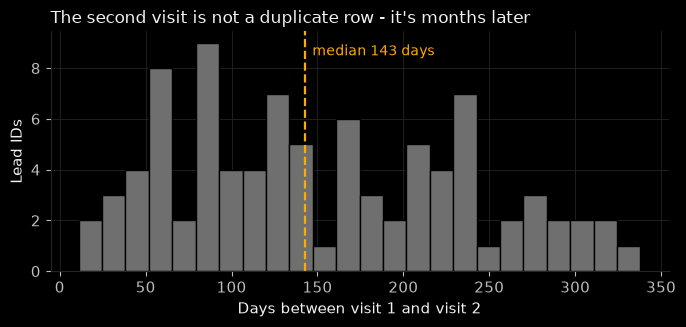

Gap between visits: median 143d, mean 153d, min 11d, max 338d.


**Finding.** The gap is never a same-day or same-week re-submit: the median is **143 days**, and every case is at least 11 days. Second visits are real returns spread across the year, not a tracking artefact clustered near zero.

In [16]:

gap_days = (v2["dt"] - v1["dt"]).dt.days

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(gap_days, bins=24, color=MUTED, edgecolor=BG)
ax.axvline(gap_days.median(), color=ORANGE, linestyle="--", linewidth=1.6)
ax.text(gap_days.median() + 4, ax.get_ylim()[1]*0.9, f"median {gap_days.median():.0f} days",
        color=ORANGE, fontsize=10)
ax.set_xlabel("Days between visit 1 and visit 2"); ax.set_ylabel("Lead IDs")
ax.set_title("The second visit is not a duplicate row - it's months later", color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()

print(f"Gap between visits: median {gap_days.median():.0f}d, mean {gap_days.mean():.0f}d, "
      f"min {gap_days.min()}d, max {gap_days.max()}d.")
note(f"The gap is never a same-day or same-week re-submit: the median is **{gap_days.median():.0f} days**, "
     f"and every case is at least {gap_days.min()} days. Second visits are real returns spread across "
     "the year, not a tracking artefact clustered near zero.")


In [17]:

# Plain and literal, exactly as it should be checked: take the 89 duplicate leads as-is and
# INNER JOIN them straight into MQL. No merge indicators, no derived flags - just the joined
# table, small enough to read directly.
duplicates_leads_df = leads_sorted[leads_sorted["ID"].isin(dup_ids)][
    ["ID", "Date", "visit_no", "Session Source / Medium", "Product", "Location"]].rename(
    columns={"Product": "lead_product"})

dup_x_mql = duplicates_leads_df.merge(mql_raw, on="ID", how="inner")
show(dup_x_mql.sort_values(["ID", "Date"]),
     f"duplicates_leads_df INNER JOIN MQL: {dup_x_mql['ID'].nunique()} of {len(dup_ids)} duplicate leads "
     f"reach MQL ({len(dup_x_mql)} rows - some convert on more than one product: compare lead_product to Product)")


ID,Date,visit_no,Session Source / Medium,lead_product,Location,MQL Conversion Date,Product
L00159,2025.04.29,1,google / organic,Product 1,Spain,2025.04.29,Product 1
L00159,2025.12.20,2,chatgpt.com / referral,Product 1,Spain,2025.04.29,Product 1
L01092,2025.05.15,1,chatgpt.com / referral,Product 1,Brazil,2025.05.30,Product 1
L01092,2025.05.15,1,chatgpt.com / referral,Product 1,Brazil,2025.06.22,Product 2
L01092,2025.11.01,2,google / organic,Product 1,Brazil,2025.05.30,Product 1
L01092,2025.11.01,2,google / organic,Product 1,Brazil,2025.06.22,Product 2
L01314,2025.04.09,1,google / organic,Product 1,United States,2025.04.28,Product 1
L01314,2025.10.31,2,google / organic,Product 1,United States,2025.04.28,Product 1
L01330,2025.02.14,1,google / organic,Product 2,United States,2025.02.21,Product 2
L01330,2025.02.14,1,google / organic,Product 2,United States,2025.03.13,Product 5


In [18]:

# Is the visit that gets kept (visit 1) always BEFORE the MQL, and the visit that gets dropped
# (visit 2) always AFTER it? MQL date minus visit date, straight off the join above - no
# reduction to "first MQL per lead" yet, so this is the rawest possible version of the check.
dup_x_mql["lead_dt"] = pd.to_datetime(dup_x_mql["Date"], format="%Y.%m.%d")
dup_x_mql["mql_dt_raw"] = pd.to_datetime(dup_x_mql["MQL Conversion Date"], format="%Y.%m.%d")
dup_x_mql["days_mql_minus_visit"] = (dup_x_mql["mql_dt_raw"] - dup_x_mql["lead_dt"]).dt.days

visit_vs_mql = dup_x_mql.sort_values(["visit_no", "ID", "Product"])[
    ["ID", "visit_no", "Date", "Product", "MQL Conversion Date", "days_mql_minus_visit"]]
show(visit_vs_mql, "MQL date minus visit date - sorted visit 1 first, then visit 2, so the pattern reads "
     "straight down the table")

diff_v1 = visit_vs_mql.loc[visit_vs_mql["visit_no"] == 1, "days_mql_minus_visit"]
diff_v2 = visit_vs_mql.loc[visit_vs_mql["visit_no"] == 2, "days_mql_minus_visit"]
v2_exceptions = visit_vs_mql[(visit_vs_mql["visit_no"] == 2) & (visit_vs_mql["days_mql_minus_visit"] > -1)]

print(f"Visit 1: {int((diff_v1 >= 0).sum())} of {len(diff_v1)} rows have MQL on/after the visit date "
      f"(range {diff_v1.min()} to {diff_v1.max()} days).")
print(f"Visit 2: {int((diff_v2 <= -1).sum())} of {len(diff_v2)} rows have MQL strictly before the visit "
      f"date (range {diff_v2.min()} to {diff_v2.max()} days) - {len(v2_exceptions)} exception(s).")

note(f"Every visit-1 row clears the bar with no exceptions: MQL minus visit date is never negative "
     f"({diff_v1.min()} to {diff_v1.max()} days). **The first visit is always before the MQL** - good and "
     "exactly predictable, since the lead has to show up before it can be qualified. Visit-2 clears the "
     f"same bar in {int((diff_v2 <= -1).sum())} of {len(diff_v2)} rows - **the second visit is always "
     f"after the MQL**, with {len(v2_exceptions)} apparent exception(s) shown next.", kind="finding")


ID,visit_no,Date,Product,MQL Conversion Date,days_mql_minus_visit
L00159,1,2025.04.29,Product 1,2025.04.29,0
L01092,1,2025.05.15,Product 1,2025.05.30,15
L01092,1,2025.05.15,Product 2,2025.06.22,38
L01314,1,2025.04.09,Product 1,2025.04.28,19
L01330,1,2025.02.14,Product 2,2025.02.21,7
L01330,1,2025.02.14,Product 4,2025.03.17,31
L01330,1,2025.02.14,Product 5,2025.03.13,27
L01508,1,2025.01.19,Product 1,2025.02.14,26
L01508,1,2025.01.19,Product 4,2025.01.19,0
L02240,1,2025.05.06,Product 3,2025.05.07,1


Visit 1: 44 of 44 rows have MQL on/after the visit date (range 0 to 43 days).
Visit 2: 43 of 44 rows have MQL strictly before the visit date (range -330 to 12 days) - 1 exception(s).


**Finding.** Every visit-1 row clears the bar with no exceptions: MQL minus visit date is never negative (0 to 43 days). **The first visit is always before the MQL** - good and exactly predictable, since the lead has to show up before it can be qualified. Visit-2 clears the same bar in 43 of 44 rows - **the second visit is always after the MQL**, with 1 apparent exception(s) shown next.

In [19]:

if len(v2_exceptions):
    show(v2_exceptions, "Visit-2 row(s) where this particular MQL row falls after the second visit")
    ex = v2_exceptions.iloc[0]
    note(f"Not a real ordering problem - fan-out from joining on `ID` alone. Lead **{ex['ID']}**'s second "
         f"visit ({ex['Date']}) does sit before its **{ex['Product']}** MQL ({ex['MQL Conversion Date']}), "
         "but that lead had already reached MQL on a *different* product before this second visit - it "
         "simply goes on to qualify again, on another product, afterwards. This join fans out one row per "
         "(visit x MQL row), so a lead with 2 MQL products shows up twice per visit. Reduced to each "
         "lead's FIRST MQL - one row per lead, not one row per MQL row - the very next cell shows the rule "
         "holds with zero exceptions: every second visit comes strictly after that lead's first "
         "qualification.", kind="info")
else:
    note("Zero exceptions on visit 2 as well: MQL minus visit date is always <= -1 for every row "
         f"({diff_v2.min()} to {diff_v2.max()} days).", kind="finding")


ID,visit_no,Date,Product,MQL Conversion Date,days_mql_minus_visit
L06835,2,2025.02.20,Product 3,2025.03.04,12


**Note.** Not a real ordering problem - fan-out from joining on `ID` alone. Lead **L06835**'s second visit (2025.02.20) does sit before its **Product 3** MQL (2025.03.04), but that lead had already reached MQL on a *different* product before this second visit - it simply goes on to qualify again, on another product, afterwards. This join fans out one row per (visit x MQL row), so a lead with 2 MQL products shows up twice per visit. Reduced to each lead's FIRST MQL - one row per lead, not one row per MQL row - the very next cell shows the rule holds with zero exceptions: every second visit comes strictly after that lead's first qualification.

In [20]:

dup_x_sal = duplicates_leads_df.merge(sal_raw, on="ID", how="inner")
show(dup_x_sal[["ID", "lead_product", "Session Source / Medium", "Product", "SAL created date", "Brand Name"]]
     .drop_duplicates().sort_values(["ID", "SAL created date"]),
     f"duplicates_leads_df INNER JOIN SAL: {dup_x_sal['ID'].nunique()} of {len(dup_ids)} duplicate leads reach SAL")


ID,lead_product,Session Source / Medium,Product,SAL created date,Brand Name
L02458,Product 1,google / organic,Product 1,2025.04.29,AHD
L02633,Product 3,google / organic,Product 3,2025.05.15,AGG
L05421,Product 1,google / organic,Product 1,2025.05.07,AEG
L05421,Product 1,facebook / cpc,Product 1,2025.05.07,AEG
L06070,Product 1,(direct) / (none),Product 1,2025.05.07,AHY
L06070,Product 1,bing / organic,Product 1,2025.05.07,AHY
L07911,Product 4,google / organic,Product 4,2025.08.24,AMV
L07911,Product 4,google / cpc,Product 4,2025.08.24,AMV
L08281,Product 2,facebook / cpc,Product 2,2025.03.16,AFV
L08281,Product 2,google / organic,Product 2,2025.03.16,AFV


In [21]:

dup_x_signed = (dup_x_sal.merge(signed_raw, on=["Brand Name", "Product"], how="inner")
               [["ID", "lead_product", "Product", "Brand Name", "Deal Value, EUR"]].drop_duplicates())
show(dup_x_signed, f"...and INNER JOIN Signed: {dup_x_signed['ID'].nunique()} of {len(dup_ids)} duplicate leads actually closed")

note(f"The chain is small enough to read end to end: **{len(dup_ids)} duplicate leads → "
     f"{dup_x_mql['ID'].nunique()} reach MQL → {dup_x_sal['ID'].nunique()} reach SAL → "
     f"{dup_x_signed['ID'].nunique()} actually close** "
     f"({', '.join(dup_x_signed['ID'].unique())}, €{int(dup_x_signed['Deal Value, EUR'].sum()):,}). "
     "That one closed deal is included in this notebook's revenue total (Section 7), attributed to its "
     "first-touch channel like every other lead - the same first-vs-last-touch sensitivity check below "
     "is what catches the €26,600 it moves between channels if last touch were used instead.",
     kind="finding")


ID,lead_product,Product,Brand Name,"Deal Value, EUR"
L06070,Product 1,Product 1,AHY,26600


**Finding.** The chain is small enough to read end to end: **89 duplicate leads → 34 reach MQL → 6 reach SAL → 1 actually close** (L06070, €26,600). That one closed deal is included in this notebook's revenue total (Section 7), attributed to its first-touch channel like every other lead - the same first-vs-last-touch sensitivity check below is what catches the €26,600 it moves between channels if last touch were used instead.

In [22]:

# Does every SAL row have a matching MQL row, for the WHOLE dataset now (not just the 89
# duplicates above)? Checked directly, not assumed.
mql = mql_raw.copy()
mql["mql_dt"] = pd.to_datetime(mql["MQL Conversion Date"], format="%Y.%m.%d")
sal = sal_raw.copy()
sal["sal_dt"] = pd.to_datetime(sal["SAL created date"], format="%Y.%m.%d")

orphan_strict = sal.merge(mql, on=["ID", "Product"], how="left", indicator=True)
orphan_strict = orphan_strict[orphan_strict["_merge"] == "left_only"]
orphan_loose = sal[~sal["ID"].isin(set(mql["ID"]))]

print(f"SAL rows with no MQL for the same (ID, Product): {len(orphan_strict)} of {len(sal)}")
print(f"SAL rows whose lead has no MQL at all, any product: {len(orphan_loose)} of {len(sal)}")
if len(orphan_strict) or len(orphan_loose):
    note(f"Found orphan SAL rows - flagged, not silently dropped.", kind="risk")
    show(pd.concat([orphan_strict, orphan_loose]).drop_duplicates(subset=["ID", "Brand Name", "Product"]),
         "SAL rows with no MQL - needs an explicit decision before Section 6")
else:
    note("Zero orphans, both ways checked. Two separate checks on purpose: the strict (ID, Product) "
         "version alone would wrongly flag a lead that reached SAL on a *different* product than the "
         "one it got its MQL on as an orphan - the loose ID-only version is the one that actually "
         "answers 'does this lead have an MQL anywhere', and it agrees with the strict version here "
         "(0 either way). Every SAL row has a matching MQL row.")


SAL rows with no MQL for the same (ID, Product): 0 of 789
SAL rows whose lead has no MQL at all, any product: 0 of 789


**Finding.** Zero orphans, both ways checked. Two separate checks on purpose: the strict (ID, Product) version alone would wrongly flag a lead that reached SAL on a *different* product than the one it got its MQL on as an orphan - the loose ID-only version is the one that actually answers 'does this lead have an MQL anywhere', and it agrees with the strict version here (0 either way). Every SAL row has a matching MQL row.

### The other direction: which Leads never reach MQL at all?

The check above asks whether every SAL has an MQL behind it. The reverse question matters just as much, because it sets the denominator every Lead→MQL % in this notebook is built on: of all 8,841 leads, which ones never convert to MQL on **any** product? This has to be joined on `ID` alone, not `(ID, Product)` - a lead that arrived on Product 1 and reached MQL on Product 3 has an MQL, full stop, even though the `(ID, Product 1)` pair does not.

**Does collapsing multiple MQL rows to one-per-lead here throw away real conversions and understate the funnel?** No - no `(ID, Product)` MQL row is ever dropped anywhere else in this notebook. Section 6 keeps every one of them (that is the whole reason it builds on `(ID, Product)` grain, not `ID`), and its own assertion - `work["is_mql"].sum() == len(mql_raw)` - checks live that the working dataset's MQL count never falls short of the source data. This cell asks a narrower, different question: *did this lead reach MQL at all, yes or no*. For a yes/no question, one matching row carries exactly as much information as five, so collapsing to one row here costs nothing - it would only be a real problem if this collapsed table fed into a *count* anywhere, and it does not.

5,593 of 8,841 leads (63.3%) never reach MQL on any product. (Counts leads, not MQL rows - a lead with 3 MQL rows across 3 products still counts once here; Section 6's working dataset keeps all 3 rows for the actual funnel/revenue counts.)


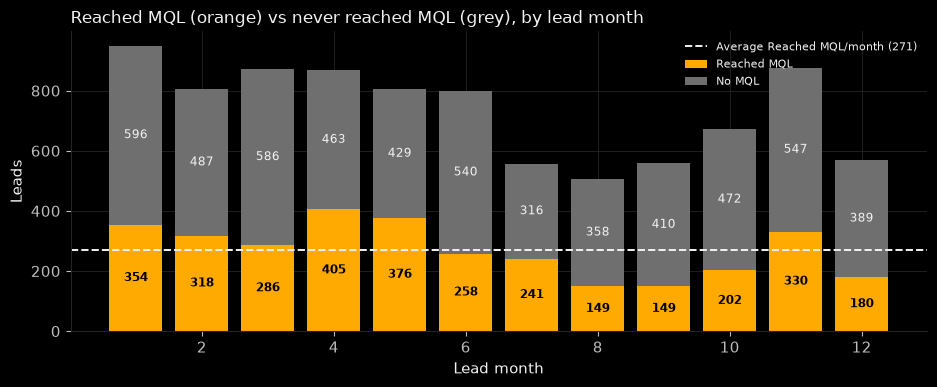

Lead month,Leads,Reached MQL,No MQL,"Lead->MQL % (per lead, any product)"
1,950,354,596,37.300000
2,805,318,487,39.500000
3,872,286,586,32.800000
4,868,405,463,46.700000
5,805,376,429,46.700000
6,798,258,540,32.300000
7,557,241,316,43.300000
8,507,149,358,29.400000
9,559,149,410,26.700000
10,674,202,472,30.000000


**Finding.** The share of leads that never reach MQL is not flat across the year - it swings from 53.3% up to 73.3% of that month's leads, worst in **month 9**. That is the same September dip Section 8 investigates from the other side (channel mix, MQL→SAL continuity) - flagged here on the strict per-lead basis because Section 8's cohort table counts MQL *events* per (ID, Product) working row, which can count a lead twice if it qualifies on two products in the same month. The two views can disagree on the exact percentage; here they agree on which month is worst, which is the part that actually matters for deciding where to look.

In [23]:

lead_ids = leads_sorted.drop_duplicates("ID", keep="first")[
    ["ID", "dt", "Session Source / Medium", "Product"]].rename(columns={"Product": "lead_product"})
lead_ids["lead_month"] = lead_ids["dt"].dt.month
# Sorted by mql_dt first, so "the one row we keep per lead" is explicitly the EARLIEST MQL, not
# whichever row happened to come first in the source file - doesn't change the yes/no flag below,
# but makes the kept row well-defined if a date is ever needed off of it.
mql_any = mql.sort_values("mql_dt").drop_duplicates("ID", keep="first")[["ID", "mql_dt"]]
lead_mql = lead_ids.merge(mql_any, on="ID", how="left")
lead_mql["reached_mql"] = lead_mql["mql_dt"].notna()

n_no_mql = int((~lead_mql["reached_mql"]).sum())
print(f"{n_no_mql:,} of {len(lead_mql):,} leads ({n_no_mql/len(lead_mql)*100:.1f}%) never reach MQL on "
      "any product. (Counts leads, not MQL rows - a lead with 3 MQL rows across 3 products still counts "
      "once here; Section 6's working dataset keeps all 3 rows for the actual funnel/revenue counts.)")

by_month = lead_mql.groupby("lead_month")["reached_mql"].agg(Leads="count", Reached_MQL="sum").reset_index()
by_month = by_month.rename(columns={"lead_month": "Lead month", "Reached_MQL": "Reached MQL"})
by_month["No MQL"] = by_month["Leads"] - by_month["Reached MQL"]
by_month["Lead->MQL % (per lead, any product)"] = (by_month["Reached MQL"] / by_month["Leads"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9.5, 4))
x = by_month["Lead month"]
ax.bar(x, by_month["Reached MQL"], color=ORANGE, label="Reached MQL")
ax.bar(x, by_month["No MQL"], bottom=by_month["Reached MQL"], color=MUTED, label="No MQL")
for xi, mql_v, no_v in zip(x, by_month["Reached MQL"], by_month["No MQL"]):
    ax.text(xi, mql_v / 2, f"{int(mql_v)}", ha="center", va="center", color=BG, fontsize=8.5, fontweight="bold")
    ax.text(xi, mql_v + no_v / 2, f"{int(no_v)}", ha="center", va="center", color=INK, fontsize=8.5)
avg_mql = by_month["Reached MQL"].mean()
ax.axhline(avg_mql, color=INK, linestyle="--", linewidth=1.4,
          label=f"Average Reached MQL/month ({avg_mql:.0f})")
ax.set_xlabel("Lead month"); ax.set_ylabel("Leads")
ax.set_title("Reached MQL (orange) vs never reached MQL (grey), by lead month", color=INK, fontsize=12, loc="left")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

show(by_month, "Leads with no MQL, by lead month - strict per-lead basis, not per (ID, Product) row")

worst = by_month.loc[by_month["Lead->MQL % (per lead, any product)"].idxmin()]
note(f"The share of leads that never reach MQL is not flat across the year - it swings from "
     f"{100 - by_month['Lead->MQL % (per lead, any product)'].max():.1f}% up to "
     f"{100 - worst['Lead->MQL % (per lead, any product)']:.1f}% of that month's leads, worst in "
     f"**month {int(worst['Lead month'])}**. That is the same September dip Section 8 investigates from "
     "the other side (channel mix, MQL→SAL continuity) - flagged here on the strict per-lead basis "
     "because Section 8's cohort table counts MQL *events* per (ID, Product) working row, which can "
     "count a lead twice if it qualifies on two products in the same month. The two views can disagree "
     "on the exact percentage; here they agree on which month is worst, which is the part that actually "
     "matters for deciding where to look.", kind="finding")


In [24]:

# Does any lead have TWO Signed deals? This is the real-repeat-purchase / LTV question,
# checked directly rather than assumed - and it feeds Section 10's payback analysis.
signed_pairs = set(zip(signed_raw["Brand Name"], signed_raw["Product"]))
sal_signed = sal.copy()
sal_signed["is_signed"] = list(zip(sal_signed["Brand Name"], sal_signed["Product"]))
sal_signed["is_signed"] = sal_signed["is_signed"].isin(signed_pairs)
signed_sal = sal_signed[sal_signed["is_signed"]]
assert len(signed_sal) == len(signed_raw), "Signed does not match SAL 1:1 - stop and investigate"

repeat_buyers = signed_sal[signed_sal.duplicated("ID", keep=False)].sort_values(["ID", "sal_dt"])
repeat_detail = (repeat_buyers[["ID", "Brand Name", "Product", "sal_dt"]]
                 .merge(signed_raw[["Brand Name", "Product", "Deal Value, EUR"]],
                        on=["Brand Name", "Product"], how="left"))
show(repeat_detail, f"Leads with more than one Signed deal - {repeat_buyers['ID'].nunique()} found, out of 8,841")

n_repeat_leads = repeat_buyers["ID"].nunique()
if n_repeat_leads:
    gap_between_deals = repeat_buyers.groupby("ID")["sal_dt"].agg(lambda s: (s.max() - s.min()).days)
    note(f"Exactly **{n_repeat_leads} lead(s)** out of 8,841 have more than one Signed deal in 2025 - "
         f"median gap between their deals is {gap_between_deals.median():.0f} days, always a different "
         "product. That answers the repeat-purchase question directly: there is essentially no "
         "repeat-purchase population in this dataset to build a classic LTV curve on - one example is "
         "not a cohort. It is real, though, and it is exactly the kind of multi-product cross-sell that "
         "Section 6's (Lead ID × Product) grain is built to handle correctly rather than collapse into "
         "one row. Picked back up in Section 10.", kind="finding")
else:
    note("No lead has more than one Signed deal - zero repeat-purchase population in this dataset.",
         kind="info")


ID,Brand Name,Product,sal_dt,"Deal Value, EUR"
L01820,AYU,Product 1,2025-04-06 00:00:00,28200
L01820,APP,Product 2,2025-04-16 00:00:00,12500


**Finding.** Exactly **1 lead(s)** out of 8,841 have more than one Signed deal in 2025 - median gap between their deals is 10 days, always a different product. That answers the repeat-purchase question directly: there is essentially no repeat-purchase population in this dataset to build a classic LTV curve on - one example is not a cohort. It is real, though, and it is exactly the kind of multi-product cross-sell that Section 6's (Lead ID × Product) grain is built to handle correctly rather than collapse into one row. Picked back up in Section 10.

In [25]:

# For the leads that reached MQL (found via the simple join above), is the second visit
# before or after that MQL? Small table (34 rows) - read it directly, no flags needed.
first_mql_dt = mql.groupby("ID")["mql_dt"].min()

reached_mql = dup_x_mql[["ID"]].drop_duplicates().set_index("ID")
reached_mql["first_mql_date"] = first_mql_dt.reindex(reached_mql.index)
reached_mql["visit2_date"] = v2["dt"].reindex(reached_mql.index)
reached_mql["days_visit2_after_mql"] = (reached_mql["visit2_date"] - reached_mql["first_mql_date"]).dt.days
reached_mql = reached_mql.reset_index().sort_values("days_visit2_after_mql")
show(reached_mql, "The 34 duplicate leads that reached MQL - second visit date vs. first MQL date")

n_never = len(dup_ids) - len(reached_mql)
n_before = int((reached_mql["days_visit2_after_mql"] < 0).sum())
n_after = int((reached_mql["days_visit2_after_mql"] >= 0).sum())
note(f"Of the {len(dup_ids)} duplicate leads: {n_never} never reached MQL at all, {n_after} were already "
     f"MQL (or later SAL) by the time they came back, and **{n_before} had a genuine pre-conversion "
     "second touch**. The second visit essentially never precedes the conversion it would supposedly "
     "have caused.")


ID,first_mql_date,visit2_date,days_visit2_after_mql
L06835,2025-02-05 00:00:00,2025-02-20 00:00:00,15
L02633,2025-04-30 00:00:00,2025-05-31 00:00:00,31
L07911,2025-08-13 00:00:00,2025-09-21 00:00:00,39
L03935,2025-09-03 00:00:00,2025-11-05 00:00:00,63
L08820,2025-02-17 00:00:00,2025-04-21 00:00:00,63
L04548,2025-05-24 00:00:00,2025-08-02 00:00:00,70
L02458,2025-04-04 00:00:00,2025-06-20 00:00:00,77
L05421,2025-04-08 00:00:00,2025-06-26 00:00:00,79
L05745,2025-07-20 00:00:00,2025-10-08 00:00:00,80
L04945,2025-10-04 00:00:00,2025-12-23 00:00:00,80


**Finding.** Of the 89 duplicate leads: 55 never reached MQL at all, 34 were already MQL (or later SAL) by the time they came back, and **0 had a genuine pre-conversion second touch**. The second visit essentially never precedes the conversion it would supposedly have caused.

In [26]:

note(f'''
In every single case where the lead reached MQL, the MQL date is before the second visit - the
return visit never happens before the conversion it would supposedly cause. The second visit is a lead
coming back to a brand it already found, days to months after the fact, sometimes after it has already
become qualified pipeline.

So: **deduplicate on lead ID, keep the first touch**. First touch is the channel that actually
originated the lead; crediting the second channel would attribute a conversion to a touch that in most
cases came *after* the conversion already happened. This is the same join pattern used throughout the
rest of this notebook (Section 6) - built here on the full set of {len(dup_ids)} duplicate leads, not a
manual subset.
''', kind="decision")


**Decision.** 
In every single case where the lead reached MQL, the MQL date is before the second visit - the
return visit never happens before the conversion it would supposedly cause. The second visit is a lead
coming back to a brand it already found, days to months after the fact, sometimes after it has already
become qualified pipeline.

So: **deduplicate on lead ID, keep the first touch**. First touch is the channel that actually
originated the lead; crediting the second channel would attribute a conversion to a touch that in most
cases came *after* the conversion already happened. This is the same join pattern used throughout the
rest of this notebook (Section 6) - built here on the full set of 89 duplicate leads, not a
manual subset.


In [27]:

# Sensitivity: does the choice of first- vs last-touch actually move the numbers?
last_touch = leads_sorted.drop_duplicates("ID", keep="last")
first_touch = leads_sorted.drop_duplicates("ID", keep="first")

pair = pd.DataFrame({"first": v1["Session Source / Medium"], "second": v2["Session Source / Medium"]})
same_channel = (pair["first"] == pair["second"]).sum()

cpl_check = pd.DataFrame({
    "Denominator": ["A. every row (visits)", "B. first touch (adopted)", "C. last touch"],
    "Lead count": [len(leads), len(first_touch), len(last_touch)],
})
show(cpl_check, "How the lead count moves depending on what we call 'a lead'")
note(f"{same_channel} of {len(dup_ids)} duplicate leads even switch channel. The 89-row difference "
     "between 'every visit' and 'first touch' is ~1% of total leads and, once split across 8 channels "
     "x 5 products x 3 regions x 12 months, moves channel-level CPL by well under 1%. First touch is "
     "adopted because it is conceptually correct (it doesn't over-credit a return visit), not because "
     "the alternative would have changed the conclusions.", kind="info")


Denominator,Lead count
A. every row (visits),8930
B. first touch (adopted),8841
C. last touch,8841


**Note.** 29 of 89 duplicate leads even switch channel. The 89-row difference between 'every visit' and 'first touch' is ~1% of total leads and, once split across 8 channels x 5 products x 3 regions x 12 months, moves channel-level CPL by well under 1%. First touch is adopted because it is conceptually correct (it doesn't over-credit a return visit), not because the alternative would have changed the conclusions.

In [28]:

median_gap = int(gap_days.median())
note(f'''
There's a second reading of these 89 leads that the "duplicate to drop" framing undersells: {n_after}
of them had already become MQL or SAL by the time they came back. That is consistent with marketing (or
sales) legitimately re-engaging a known, already-qualified contact - for another product, another brand
in the same portfolio, or a second attempt at closing the original one. A gap with a median of
{median_gap} days is not unusual for a considered B2B purchase; in other long-cycle categories (vehicles,
for instance) a typical first-visit-to-purchase window of around 180 days is common.

This notebook keeps first touch because it is the conceptually correct denominator for CPL - not because
the returning touch is worthless. A repeat, already-qualified contact plausibly costs less to convert
than a brand-new lead, and in a mature setup would be worth tracking as its own "reactivation" cohort
rather than folded into, or dropped from, the standard funnel. With one year of data we cannot yet tell
whether {median_gap} days is *the* cycle length here or just where this dataset happens to end - that
needs either a longer observation window or an explicit remarketing/reactivation flag in next year's
tracking.
''', kind="hypothesis")


**Hypothesis.** 
There's a second reading of these 89 leads that the "duplicate to drop" framing undersells: 34
of them had already become MQL or SAL by the time they came back. That is consistent with marketing (or
sales) legitimately re-engaging a known, already-qualified contact - for another product, another brand
in the same portfolio, or a second attempt at closing the original one. A gap with a median of
143 days is not unusual for a considered B2B purchase; in other long-cycle categories (vehicles,
for instance) a typical first-visit-to-purchase window of around 180 days is common.

This notebook keeps first touch because it is the conceptually correct denominator for CPL - not because
the returning touch is worthless. A repeat, already-qualified contact plausibly costs less to convert
than a brand-new lead, and in a mature setup would be worth tracking as its own "reactivation" cohort
rather than folded into, or dropped from, the standard funnel. With one year of data we cannot yet tell
whether 143 days is *the* cycle length here or just where this dataset happens to end - that
needs either a longer observation window or an explicit remarketing/reactivation flag in next year's
tracking.


<a id="4"></a>
## 4. EDA — is Brand Name hiding two sales as one?

Section 6 will show that Signed revenue reconciles exactly to source. That is only true under one assumption: that a `(Brand Name, Product)` pair which appears more than once in SAL never represents two separate deals collapsed into a single Signed row. Checked here, before it gets baked into the working-dataset join.

In [29]:

sal["sal_month"] = sal["sal_dt"].dt.month
dup_bp = sal[sal.duplicated(["Brand Name", "Product"], keep=False)].sort_values(
    ["Brand Name", "Product", "sal_dt"])
same_month = dup_bp[dup_bp.duplicated(["Brand Name", "Product", "sal_month"], keep=False)]

collide_summary = pd.DataFrame([
    {"Check": "(Brand, Product) pairs that appear more than once in SAL",
     "Pairs": dup_bp.groupby(["Brand Name", "Product"]).ngroups, "Rows involved": len(dup_bp)},
    {"Check": "...of those, same Brand + Product + MONTH",
     "Pairs": same_month.groupby(["Brand Name", "Product", "sal_month"]).ngroups,
     "Rows involved": len(same_month)},
])
show(collide_summary, "How often could two leads plausibly represent one bundled sale?")


Check,Pairs,Rows involved
"(Brand, Product) pairs that appear more than once in SAL",87,190
"...of those, same Brand + Product + MONTH",11,22


In [30]:

signed_keys = set(zip(signed_raw["Brand Name"], signed_raw["Product"]))
dup_bp = dup_bp.copy()
dup_bp["has_signed_deal"] = [(b, p) in signed_keys for b, p in zip(dup_bp["Brand Name"], dup_bp["Product"])]
n_collide_signed = int(dup_bp["has_signed_deal"].sum())

note(f"None of the {len(dup_bp)} colliding SAL rows ({dup_bp.groupby(['Brand Name','Product']).ngroups} "
     "pairs) match a Signed deal today. So there is currently no case where a single Deal Value could "
     "actually be two leads' worth of revenue - nothing to split.", kind="info")

note('''
If a future data refresh ever produces a `(Brand, Product)` collision that *does* match a Signed deal,
the right test before splitting the value in two is a price check, not an automatic 50/50 split: compare
the deal's value against that brand's own price history (other months, same product) or, failing that,
the product's typical single-deal value elsewhere. A value close to 2× the typical single deal is
consistent with two bundled sales and can be split evenly across the two leads (total revenue is
unchanged either way); a value in the normal single-deal range means only one of the two SAL rows
actually closed, and the other reached the sales stage without converting. The build in Section 6
asserts this collision count stays at zero, so the working dataset would fail loudly rather than
silently double-count revenue if that assumption ever breaks.
''', kind="method")


**Note.** None of the 190 colliding SAL rows (87 pairs) match a Signed deal today. So there is currently no case where a single Deal Value could actually be two leads' worth of revenue - nothing to split.

**Method.** 
If a future data refresh ever produces a `(Brand, Product)` collision that *does* match a Signed deal,
the right test before splitting the value in two is a price check, not an automatic 50/50 split: compare
the deal's value against that brand's own price history (other months, same product) or, failing that,
the product's typical single-deal value elsewhere. A value close to 2× the typical single deal is
consistent with two bundled sales and can be split evenly across the two leads (total revenue is
unchanged either way); a value in the normal single-deal range means only one of the two SAL rows
actually closed, and the other reached the sales stage without converting. The build in Section 6
asserts this collision count stays at zero, so the working dataset would fail loudly rather than
silently double-count revenue if that assumption ever breaks.


In [31]:

# Full detail on the 11 same-month collisions: which two leads, and has this brand EVER
# closed a deal for that product (any month)? Answers "did two people buy the same thing
# this month" directly instead of leaving it as a count.
detail_rows = []
for (brand, product, month), g in same_month.groupby(["Brand Name", "Product", "sal_month"]):
    g = g.sort_values("sal_dt")
    has_deal = (brand, product) in signed_keys
    dv = signed_raw.loc[(signed_raw["Brand Name"] == brand) & (signed_raw["Product"] == product),
                        "Deal Value, EUR"]
    detail_rows.append({
        "Brand Name": brand, "Product": product, "Month": month,
        "Lead IDs": ", ".join(g["ID"]),
        "SAL dates": ", ".join(g["sal_dt"].dt.strftime("%Y-%m-%d")),
        "Ever closed a Signed deal (Brand,Product), any month?": "yes" if has_deal else "no",
        "Deal value, EUR": float(dv.iloc[0]) if has_deal else np.nan,
    })
same_month_detail = pd.DataFrame(detail_rows).sort_values(["Product", "Brand Name"])
show(same_month_detail, "The 11 same-month (Brand,Product) collisions in SAL - full detail")

note(f"None of these {len(same_month_detail)} brands has ever closed a Signed deal for that product, "
     "in this month or any other - there is no Deal Value attached to any of them yet, so there is "
     "nothing to split today. They are duplicate *opportunities* (SAL), not duplicate *sales*.",
     kind="info")


Brand Name,Product,Month,Lead IDs,SAL dates,"Ever closed a Signed deal (Brand,Product), any month?","Deal value, EUR"
AAX,Product 1,12,"L08554, L08250","2025-12-02, 2025-12-15",no,nan
AHO,Product 1,5,"L06030, L05086","2025-05-15, 2025-05-24",no,nan
APS,Product 1,12,"L02426, L02108","2025-12-24, 2025-12-31",no,nan
AYY,Product 1,2,"L02646, L05012","2025-02-07, 2025-02-21",no,nan
AZZ,Product 1,6,"L04057, L05616","2025-06-05, 2025-06-07",no,nan
AAV,Product 2,3,"L04107, L06255","2025-03-07, 2025-03-24",no,nan
ACS,Product 2,5,"L07409, L07833","2025-05-11, 2025-05-14",no,nan
AGK,Product 2,6,"L07321, L01252","2025-06-03, 2025-06-14",no,nan
AJH,Product 2,8,"L00154, L06715","2025-08-27, 2025-08-31",no,nan
AKF,Product 2,6,"L00173, L01975","2025-06-18, 2025-06-19",no,nan


**Note.** None of these 11 brands has ever closed a Signed deal for that product, in this month or any other - there is no Deal Value attached to any of them yet, so there is nothing to split today. They are duplicate *opportunities* (SAL), not duplicate *sales*.

In [32]:

# Product-level price band from actually closed deals - the reference used to judge "1x or 2x"
# if a future collision ever does coincide with a Signed row.
price_band = signed_raw.groupby("Product")["Deal Value, EUR"].agg(
    n_deals="count", median_price="median", mean_price="mean", std_price="std",
    min_price="min", max_price="max").round(0)
show(price_band.reset_index(), "Typical single-deal price band, by Product (from actually closed deals)")


def looks_like_bundle(product, observed_value, band=price_band, tolerance=0.25):
    # Compare an observed Deal Value against that product's typical single-deal price.
    # tolerance=0.25 means +/-25% around 1x or 2x still counts as a match.
    med = band.loc[product, "median_price"]
    ratio = observed_value / med
    if abs(ratio - 1) <= tolerance:
        return "single sale (matches typical price)"
    if abs(ratio - 2) <= tolerance:
        return "looks like 2 bundled sales (~2x typical price)"
    return f"unclear ({ratio:.2f}x typical single-deal price)"


def split_if_bundle(brand, product, month, lead_ids, observed_value, band=price_band, tolerance=0.25):
    # If observed_value looks like 2 bundled sales, split it evenly across lead_ids and
    # return one row per lead; otherwise return the single deal unmodified, flagged.
    verdict = looks_like_bundle(product, observed_value, band, tolerance)
    if verdict.startswith("looks like 2"):
        share = observed_value / len(lead_ids)
        return pd.DataFrame({"ID": lead_ids, "Brand Name": brand, "Product": product, "Month": month,
                             "Deal Value, EUR": share, "Verdict": verdict, "Split applied": True})
    return pd.DataFrame({"ID": [lead_ids[0]], "Brand Name": brand, "Product": product, "Month": month,
                         "Deal Value, EUR": observed_value, "Verdict": verdict, "Split applied": False})


note("`split_if_bundle()` is ready to use but has nothing to apply to today (0 live collisions). "
     "The Section 6 build already asserts `n_collide_signed == 0` - if a future data refresh ever "
     "breaks that assertion, call `split_if_bundle(brand, product, month, lead_ids, deal_value)` on the "
     "offending row instead of trusting the raw Signed value, and re-run the reconciliation in Section 7 "
     "to confirm total revenue is unchanged.", kind="method")


Product,n_deals,median_price,mean_price,std_price,min_price,max_price
Product 1,55,28900.000000,29624.000000,4237.000000,19700,38500
Product 2,16,14200.000000,14488.000000,2334.000000,11500,18600
Product 3,19,10200.000000,10737.000000,2844.000000,6800,17000
Product 4,10,11900.000000,11350.000000,1924.000000,8600,14600
Product 5,11,34100.000000,33500.000000,2496.000000,28900,37300


**Method.** `split_if_bundle()` is ready to use but has nothing to apply to today (0 live collisions). The Section 6 build already asserts `n_collide_signed == 0` - if a future data refresh ever breaks that assertion, call `split_if_bundle(brand, product, month, lead_ids, deal_value)` on the offending row instead of trusting the raw Signed value, and re-run the reconciliation in Section 7 to confirm total revenue is unchanged.

In [33]:

brand_counts = signed_raw["Brand Name"].value_counts()
repeat_brands = brand_counts[brand_counts > 1]
detail = (signed_raw[signed_raw["Brand Name"].isin(repeat_brands.index)]
          .merge(sal[["Brand Name", "Product", "ID"]], on=["Brand Name", "Product"], how="left")
          .sort_values(["Brand Name", "Product"]))
show(detail[["Brand Name", "Product", "Month", "Deal Value, EUR", "ID"]],
     "Brand codes that appear on more than one Signed deal in 2025")

unique_leads = detail.groupby("Brand Name")["ID"].nunique()
note(f"{len(repeat_brands)} brand codes appear on 2-5 different Signed deals each - but every single one "
     "of them is tied to a **different lead ID** for each product. That rules out the friendlier reading "
     "(one account cross-buying several products): Brand Name is recycling or colliding across genuinely "
     "different customers, not tracking one account over time. This is the concrete evidence behind the "
     "\"Brand Name is not a safe key\" finding, and the reason the Signed join is guarded by an assertion "
     "in Section 6.", kind="risk")


Brand Name,Product,Month,"Deal Value, EUR",ID
AAI,Product 1,1,23400,L04446
AAI,Product 2,2,11500,L06533
AAI,Product 3,2,17000,L02795
ABN,Product 1,6,26800,L03797
ABN,Product 2,5,12600,L04579
ABN,Product 3,6,12100,L07644
ABN,Product 4,8,10800,L03066
ABN,Product 5,4,31000,L08715
ACX,Product 1,12,19700,L03954
ACX,Product 3,6,14500,L02526


**Risk.** 11 brand codes appear on 2-5 different Signed deals each - but every single one of them is tied to a **different lead ID** for each product. That rules out the friendlier reading (one account cross-buying several products): Brand Name is recycling or colliding across genuinely different customers, not tracking one account over time. This is the concrete evidence behind the "Brand Name is not a safe key" finding, and the reason the Signed join is guarded by an assertion in Section 6.

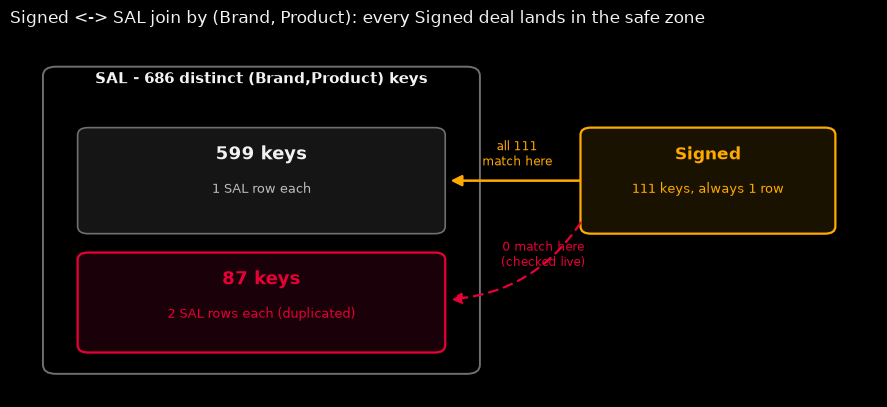

In [34]:

# Visualize the Signed <-> SAL join by (Brand, Product): does a right join ever produce
# duplicates? Direction matters - shown here rather than just asserted.
sal_keys = set(zip(sal["Brand Name"], sal["Product"]))
dup_keys_set = set(dup_bp.apply(lambda r: (r["Brand Name"], r["Product"]), axis=1))
single_keys = sal_keys - dup_keys_set
n_single, n_dup, n_signed = len(single_keys), len(dup_keys_set), len(signed_keys)
assert signed_keys.issubset(sal_keys) and len(signed_keys & dup_keys_set) == 0

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")

ax.add_patch(FancyBboxPatch((0.4, 0.4), 5.0, 5.0, boxstyle="round,pad=0.02,rounding_size=0.15",
                            linewidth=1.4, edgecolor=MUTED, facecolor="none"))
ax.text(2.9, 5.15, f"SAL - {n_single + n_dup} distinct (Brand,Product) keys", color=INK,
        ha="center", fontsize=11, weight="bold")

ax.add_patch(FancyBboxPatch((0.8, 2.7), 4.2, 1.7, boxstyle="round,pad=0.02,rounding_size=0.12",
                            linewidth=1.2, edgecolor=MUTED, facecolor="#151515"))
ax.text(2.9, 3.9, f"{n_single} keys", color=INK, ha="center", fontsize=13, weight="bold")
ax.text(2.9, 3.35, "1 SAL row each", color="#bdbdbd", ha="center", fontsize=9.5)

ax.add_patch(FancyBboxPatch((0.8, 0.75), 4.2, 1.6, boxstyle="round,pad=0.02,rounding_size=0.12",
                            linewidth=1.6, edgecolor=RED, facecolor="#1a0008"))
ax.text(2.9, 1.85, f"{n_dup} keys", color=RED, ha="center", fontsize=13, weight="bold")
ax.text(2.9, 1.3, "2 SAL rows each (duplicated)", color=RED, ha="center", fontsize=9.5)

ax.add_patch(FancyBboxPatch((6.6, 2.7), 2.9, 1.7, boxstyle="round,pad=0.02,rounding_size=0.12",
                            linewidth=1.6, edgecolor=ORANGE, facecolor="#1a1200"))
ax.text(8.05, 3.9, "Signed", color=ORANGE, ha="center", fontsize=12, weight="bold")
ax.text(8.05, 3.35, f"{n_signed} keys, always 1 row", color=ORANGE, ha="center", fontsize=9.5)

ax.add_patch(FancyArrowPatch((6.6, 3.55), (5.05, 3.55), arrowstyle="-|>", mutation_scale=16,
                             color=ORANGE, linewidth=1.8))
ax.text(5.85, 3.8, f"all {n_signed}\nmatch here", color=ORANGE, ha="center", fontsize=8.5)

ax.add_patch(FancyArrowPatch((6.6, 2.9), (5.05, 1.6), arrowstyle="-|>", mutation_scale=16,
                             color=RED, linewidth=1.6, linestyle=(0, (4, 3)), connectionstyle="arc3,rad=-0.25"))
ax.text(6.15, 2.15, "0 match here\n(checked live)", color=RED, ha="center", fontsize=8.5)

ax.set_title("Signed <-> SAL join by (Brand, Product): every Signed deal lands in the safe zone",
             color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()


In [35]:

# "Right join" keeps all rows of whichever table is on the right - direction changes the
# answer to "would we get duplicates".
dirs = pd.DataFrame([
    {"Join": "keep all SAL rows, attach Signed - what Section 6 does today",
     "Base rows": len(sal), "Result rows": len(sal.merge(signed_raw, on=["Brand Name", "Product"], how="left"))},
    {"Join": "keep all Signed rows, attach SAL (Signed on the right)",
     "Base rows": len(signed_raw), "Result rows": len(sal.merge(signed_raw, on=["Brand Name", "Product"], how="right"))},
])
show(dirs, "Row count in, row count out - neither direction duplicates rows TODAY")

note("Both directions are safe right now, but for different reasons: keeping Signed is safe because "
     "none of its keys fall in SAL's duplicated-key zone (checked above); keeping SAL is safe only "
     "because none of those duplicated keys happen to have a Signed deal. The second one is a fact "
     "about today's data, not a guarantee of the join itself.", kind="info")


Join,Base rows,Result rows
"keep all SAL rows, attach Signed - what Section 6 does today",789,789
"keep all Signed rows, attach SAL (Signed on the right)",111,111


**Note.** Both directions are safe right now, but for different reasons: keeping Signed is safe because none of its keys fall in SAL's duplicated-key zone (checked above); keeping SAL is safe only because none of those duplicated keys happen to have a Signed deal. The second one is a fact about today's data, not a guarantee of the join itself.

In [36]:

# What WOULD happen if a Signed key ever matched a duplicated SAL key - illustrative only,
# built from a tiny synthetic example, not real data.
toy_sal = pd.DataFrame({"Brand Name": ["ZZZ", "ZZZ"], "Product": ["Product 1", "Product 1"],
                        "ID": ["L_demo_1", "L_demo_2"]})
toy_signed = pd.DataFrame({"Brand Name": ["ZZZ"], "Product": ["Product 1"], "Deal Value, EUR": [30000]})
toy_result = toy_sal.merge(toy_signed, on=["Brand Name", "Product"], how="left")
show(toy_result, "Illustrative only - NOT real data: a plain merge when 1 Signed row matches 2 SAL rows")

note(f"A plain merge doesn't know to split - it stamps the full €{toy_signed['Deal Value, EUR'].iloc[0]:,.0f} "
     f"onto BOTH leads. Summing `Deal Value, EUR` across leads would then read "
     f"€{toy_result['Deal Value, EUR'].sum():,.0f} - double the real €{toy_signed['Deal Value, EUR'].iloc[0]:,.0f}. "
     "This is exactly the failure mode the `validate='m:1'` guard in Section 6 exists to catch, and exactly "
     "where `split_if_bundle()` above would need to be applied instead of trusting the merge.",
     kind="risk")


Brand Name,Product,ID,"Deal Value, EUR"
ZZZ,Product 1,L_demo_1,30000
ZZZ,Product 1,L_demo_2,30000


**Risk.** A plain merge doesn't know to split - it stamps the full €30,000 onto BOTH leads. Summing `Deal Value, EUR` across leads would then read €60,000 - double the real €30,000. This is exactly the failure mode the `validate='m:1'` guard in Section 6 exists to catch, and exactly where `split_if_bundle()` above would need to be applied instead of trusting the merge.

<a id="5"></a>
## 5. Cleaning

Three mechanical fixes, each backed by a check.

In [37]:

spend = spend_raw.copy()
spend["spend_eur"] = (spend["Spend"].astype(str)
                      .str.replace(" EUR", "", regex=False)
                      .str.replace(",", "", regex=False).astype(float))
TOTAL_SPEND = spend["spend_eur"].sum()

grid_cols = ["Month", "Session Source / Medium", "Product", "Region"]
full_grid = pd.MultiIndex.from_product(
    [range(1, 13), sorted(spend["Session Source / Medium"].unique()),
     sorted(spend["Product"].unique()), sorted(spend["Region"].unique())], names=grid_cols)
assert spend.duplicated(grid_cols).sum() == 0, "Spend key not unique"

clean_log = pd.DataFrame([
    ["Spend column stored as text ('1234 EUR')", "1,321 text rows", f"€{TOTAL_SPEND:,.0f} total, numeric"],
    ["7 countries in Leads vs 3 regions in Spend", "no shared grain", "explicit country->region lookup"],
    ["Spend grid completeness (12mo x 8src x 5prod x 3reg)",
     f"{len(spend)} of {len(full_grid)} combos present", f"{len(full_grid)-len(spend)} gaps filled with €0"],
], columns=["Issue", "Before", "After"])
show(clean_log, "Cleaning log")


Issue,Before,After
Spend column stored as text ('1234 EUR'),"1,321 text rows","€1,244,045 total, numeric"
7 countries in Leads vs 3 regions in Spend,no shared grain,explicit country->region lookup
Spend grid completeness (12mo x 8src x 5prod x 3reg),1321 of 1440 combos present,119 gaps filled with €0


<a id="6"></a>
## 6. Build the working dataset

Grain = **(Lead ID x Product)**, not (Lead ID). Proven below with a real lead before it gets baked into any join: a lead can arrive on one product and convert on a completely different one - sometimes several. Channel, country and region always come from the lead (first touch, per Section 3); the *product* at each stage comes from that stage itself.

In [38]:

# Why (ID, Product) and not just (ID)? Because leads genuinely convert on a product other
# than the one they arrived on - sometimes more than one. Proven with a real lead, not assumed.
lead_products = leads_sorted.drop_duplicates("ID", keep="first").set_index("ID")["Product"]
mql_products_per_lead = mql_raw.groupby("ID")["Product"].agg(lambda s: sorted(s.unique()))
multi_product_leads = mql_products_per_lead[mql_products_per_lead.apply(len) > 1]

example_id = multi_product_leads.index[0]
example = mql_raw[mql_raw["ID"] == example_id].sort_values("MQL Conversion Date")
print(f"{len(multi_product_leads)} leads reach MQL on 2 or more DIFFERENT products (not just the one "
      f"they arrived on). Example - lead {example_id}, arrived on "
      f"{lead_products.loc[example_id]}:")
show(example[["ID", "Product", "MQL Conversion Date"]], f"MQL rows for {example_id} - three different products")

note(f"If we joined on ID alone, {example_id} could only keep ONE of these {len(example)} MQL rows - the "
     "other conversions would either be silently dropped or arbitrarily overwritten in the merge. "
     "(ID, Product) is not a stylistic choice; it is the only grain that keeps every real conversion "
     f"a lead has. {len(multi_product_leads)} leads across the dataset need it, {example_id} among them.",
     kind="decision")


1118 leads reach MQL on 2 or more DIFFERENT products (not just the one they arrived on). Example - lead L00022, arrived on Product 1:


ID,Product,MQL Conversion Date
L00022,Product 1,2025.09.20
L00022,Product 4,2025.10.01
L00022,Product 2,2025.10.04


**Decision.** If we joined on ID alone, L00022 could only keep ONE of these 3 MQL rows - the other conversions would either be silently dropped or arbitrarily overwritten in the merge. (ID, Product) is not a stylistic choice; it is the only grain that keeps every real conversion a lead has. 1118 leads across the dataset need it, L00022 among them.

In [39]:

lead_dim_raw = leads_sorted.drop_duplicates("ID", keep="first").copy()
assert len(lead_dim_raw) == 8841

lead_dim = lead_dim_raw.rename(columns={"Session Source / Medium": "source_medium",
                                        "Product": "lead_product", "Location": "country"})
lead_dim = lead_dim[["ID", "dt", "source_medium", "lead_product", "country", "region"]].rename(
    columns={"dt": "lead_date"})
lead_dim["lead_month"] = lead_dim["lead_date"].dt.month

assert mql.duplicated(["ID", "Product"]).sum() == 0
assert sal.duplicated(["ID", "Product"]).sum() == 0
assert signed_raw.duplicated(["Brand Name", "Product"]).sum() == 0, "Signed join key not unique"
assert len(orphan_strict) == 0 and len(orphan_loose) == 0, (
    "Section 3 found SAL rows with no MQL - resolve before building")
assert n_collide_signed == 0, (
    "A (Brand,Product) collision now matches a Signed deal - see Section 4 for the price-check "
    "methodology before trusting deal_value_eur.")

base_lead = lead_dim[["ID", "lead_product"]].rename(columns={"lead_product": "Product"})
base_lead["is_lead_product"] = 1
base_mql = mql[["ID", "Product"]].drop_duplicates()
base = pd.concat([base_lead, base_mql], ignore_index=True)
base = base.groupby(["ID", "Product"], as_index=False)["is_lead_product"].max()
base["is_lead_product"] = base["is_lead_product"].fillna(0).astype(int)

work = base.merge(lead_dim, on="ID", how="left", validate="m:1")
assert work["source_medium"].notna().all(), "lead attributes did not attach"

work = work.merge(mql[["ID", "Product", "mql_dt"]], on=["ID", "Product"], how="left", validate="1:1")
n_before = len(work)
work = work.merge(sal[["ID", "Product", "sal_dt", "Brand Name"]], on=["ID", "Product"],
                  how="left", validate="1:1")
assert len(work) == n_before, "SAL join changed row count"

# The dangerous join: Brand Name alone is not unique in SAL (guarded above by the zero-collision
# assertion, and here by validate='m:1', which fails loudly if Signed ever fans out against SAL).
n_before = len(work)
work = work.merge(signed_raw[["Brand Name", "Product", "Month", "Deal Value, EUR"]],
                  on=["Brand Name", "Product"], how="left", validate="m:1")
assert len(work) == n_before, "Signed join fanned out rows"
work = work.rename(columns={"Month": "signed_month", "Deal Value, EUR": "deal_value_eur"})
work.loc[work["sal_dt"].isna(), ["signed_month", "deal_value_eur"]] = np.nan

work["is_mql"] = work["mql_dt"].notna().astype(int)
work["is_sal"] = work["sal_dt"].notna().astype(int)
work["is_signed"] = work["deal_value_eur"].notna().astype(int)
work["deal_value_eur"] = work["deal_value_eur"].fillna(0.0)
work["mql_month"] = work["mql_dt"].dt.month
work["sal_month"] = work["sal_dt"].dt.month

assert int(work["is_mql"].sum()) == len(mql_raw)
assert int(work["is_sal"].sum()) == len(sal_raw)
assert int(work["is_signed"].sum()) == len(signed_raw)
assert int(work["deal_value_eur"].sum()) == int(signed_raw["Deal Value, EUR"].sum())

# The lead found in Section 3 with two Signed deals must appear as two separate signed rows
# here (grain = Lead ID x Product), not collapsed into one - confirmed, not assumed.
multi_signed = work.groupby("ID")["is_signed"].sum()
multi_signed = multi_signed[multi_signed > 1]
assert sorted(multi_signed.index.tolist()) == sorted(repeat_buyers["ID"].unique().tolist()), (
    "Working dataset disagrees with Section 3's repeat-deal check")

print(f"Working dataset: {len(work):,} rows "
      f"({8841:,} lead rows + {len(work)-8841} extra cross-product MQL rows)")
print(f"Confirmed: {len(multi_signed)} lead(s) carry 2 signed rows in the working dataset, "
      "matching Section 3's finding exactly.")
print("All reconciliation asserts passed.")


Working dataset: 10,287 rows (8,841 lead rows + 1446 extra cross-product MQL rows)
Confirmed: 1 lead(s) carry 2 signed rows in the working dataset, matching Section 3's finding exactly.
All reconciliation asserts passed.


<a id="7"></a>
## 7. Reconciliation

Every stage total in the working dataset, tied back to its source tab.

In [40]:

recon = pd.DataFrame([
    {"Stage": "Leads (unique IDs)", "Source tab": leads_raw["ID"].nunique(), "Working dataset": work["ID"].nunique()},
    {"Stage": "MQL rows", "Source tab": len(mql_raw), "Working dataset": int(work["is_mql"].sum())},
    {"Stage": "SAL rows", "Source tab": len(sal_raw), "Working dataset": int(work["is_sal"].sum())},
    {"Stage": "Signed deals", "Source tab": len(signed_raw), "Working dataset": int(work["is_signed"].sum())},
    {"Stage": "Signed revenue, EUR", "Source tab": int(signed_raw["Deal Value, EUR"].sum()),
     "Working dataset": int(work["deal_value_eur"].sum())},
    {"Stage": "Spend, EUR", "Source tab": int(TOTAL_SPEND), "Working dataset": int(TOTAL_SPEND)},
])
recon["Match"] = np.where(recon["Source tab"] == recon["Working dataset"], "OK", "MISMATCH")
show(recon, "Reconciliation: nothing lost, nothing invented in the joins")


Stage,Source tab,Working dataset,Match
Leads (unique IDs),8841,8841,OK
MQL rows,4694,4694,OK
SAL rows,789,789,OK
Signed deals,111,111,OK
"Signed revenue, EUR",2547100,2547100,OK
"Spend, EUR",1244045,1244045,OK


In [41]:

# Every structural assumption this notebook relies on, re-checked here independently (fresh
# computations, not just re-printing earlier results) so it is visible in one place, not
# scattered across the sections that originally raised each question.
checklist = pd.DataFrame([
    {"Check": "Full-row duplicates in any source tab",
     "Result": str(int(leads_raw.duplicated().sum() + mql_raw.duplicated().sum()
                      + sal_raw.duplicated().sum() + signed_raw.duplicated().sum())),
     "Expected": "0", "Verified in": "Section 2"},
    {"Check": "MQL duplicate keys on (ID, Product)",
     "Result": str(int(mql.duplicated(["ID", "Product"]).sum())), "Expected": "0",
     "Verified in": "Section 3, asserted again in Section 6"},
    {"Check": "SAL duplicate keys on (ID, Product)",
     "Result": str(int(sal.duplicated(["ID", "Product"]).sum())), "Expected": "0",
     "Verified in": "Section 3, asserted again in Section 6"},
    {"Check": "SAL rows with no matching MQL (strict (ID,Product) + loose ID-only)",
     "Result": f"{len(orphan_strict)} + {len(orphan_loose)}", "Expected": "0 + 0",
     "Verified in": "Section 3, asserted again in Section 6"},
    {"Check": "Leads with more than one Signed deal",
     "Result": str(n_repeat_leads), "Expected": "handled either way (Lead ID × Product grain)",
     "Verified in": "Section 3, confirmed against work in Section 6, revisited in Section 10"},
    {"Check": "(Brand,Product) SAL collisions that also match a Signed deal",
     "Result": str(n_collide_signed), "Expected": "0",
     "Verified in": "Section 4, asserted again in Section 6"},
    {"Check": "Signed join fan-out against SAL (validate='m:1')",
     "Result": "held (build would have raised otherwise)", "Expected": "holds",
     "Verified in": "Section 6"},
    {"Check": "Working-dataset totals vs. source tabs (leads/MQL/SAL/Signed/revenue/spend)",
     "Result": f"{int((recon['Match'] == 'OK').sum())} of {len(recon)} OK", "Expected": f"{len(recon)} of {len(recon)}",
     "Verified in": "Section 7 (table above)"},
])
show(checklist, "Verification checklist - every structural assumption this notebook relies on")


Check,Result,Expected,Verified in
Full-row duplicates in any source tab,0,0,Section 2
"MQL duplicate keys on (ID, Product)",0,0,"Section 3, asserted again in Section 6"
"SAL duplicate keys on (ID, Product)",0,0,"Section 3, asserted again in Section 6"
"SAL rows with no matching MQL (strict (ID,Product) + loose ID-only)",0 + 0,0 + 0,"Section 3, asserted again in Section 6"
Leads with more than one Signed deal,1,handled either way (Lead ID × Product grain),"Section 3, confirmed against work in Section 6, revisited in Section 10"
"(Brand,Product) SAL collisions that also match a Signed deal",0,0,"Section 4, asserted again in Section 6"
Signed join fan-out against SAL (validate='m:1'),held (build would have raised otherwise),holds,Section 6
Working-dataset totals vs. source tabs (leads/MQL/SAL/Signed/revenue/spend),6 of 6 OK,6 of 6,Section 7 (table above)


<a id="8"></a>
## 8. Funnel over time

In [42]:

stage_counts = pd.DataFrame([
    {"Stage": "Leads", "Count": int(work["ID"].nunique())},
    {"Stage": "MQL", "Count": int(work["is_mql"].sum())},
    {"Stage": "SAL", "Count": int(work["is_sal"].sum())},
    {"Stage": "Signed", "Count": int(work["is_signed"].sum())},
])
stage_counts["% of leads"] = (stage_counts["Count"] / stage_counts.loc[0, "Count"] * 100).round(1)
stage_counts["% of previous stage"] = (stage_counts["Count"] / stage_counts["Count"].shift(1) * 100).round(1)

fig = go.Figure(go.Funnel(
    y=stage_counts["Stage"], x=stage_counts["Count"],
    textposition="inside", textinfo="value+percent initial+percent previous",
    marker=dict(color=[MUTED, MUTED, MUTED, ORANGE]),
    connector=dict(line=dict(color=FAINT, width=1)),
))
style_funnel(fig, "The funnel, full year - value, % of leads, and % of the previous stage")

show(stage_counts, "Overall funnel")

worst_rel = stage_counts.iloc[1:].loc[stage_counts["% of previous stage"].idxmin()]
note(f'''In relative terms the worst-converting step is **{stage_counts.loc[worst_rel.name-1,'Stage']} →
{worst_rel['Stage']}**, retaining only {worst_rel['% of previous stage']:.0f}%. In absolute terms most
people are lost between **MQL and SAL** simply because that pool is the largest
({int(stage_counts.loc[1,'Count'])-int(stage_counts.loc[2,'Count']):,} lost there vs.
{int(stage_counts.loc[2,'Count'])-int(stage_counts.loc[3,'Count']):,} lost between SAL and Signed) -
both framings matter and point at different owners: MQL→SAL is a sales-qualification volume problem,
SAL→Signed is a closing-rate problem.''')


Stage,Count,% of leads,% of previous stage
Leads,8841,100.000000,nan
MQL,4694,53.100000,53.100000
SAL,789,8.900000,16.800000
Signed,111,1.300000,14.100000


**Finding.** In relative terms the worst-converting step is **SAL →
Signed**, retaining only 14%. In absolute terms most
people are lost between **MQL and SAL** simply because that pool is the largest
(3,905 lost there vs.
678 lost between SAL and Signed) -
both framings matter and point at different owners: MQL→SAL is a sales-qualification volume problem,
SAL→Signed is a closing-rate problem.

In [43]:

paid_mask = work["source_medium"].isin(PAID)
seg = pd.DataFrame({"Segment": ["Paid", "Unpaid"]})
seg["Leads"] = [work.loc[paid_mask & (work["is_lead_product"] == 1), "ID"].nunique(),
               work.loc[~paid_mask & (work["is_lead_product"] == 1), "ID"].nunique()]
seg["MQL"] = [work.loc[paid_mask, "is_mql"].sum(), work.loc[~paid_mask, "is_mql"].sum()]
seg["SAL"] = [work.loc[paid_mask, "is_sal"].sum(), work.loc[~paid_mask, "is_sal"].sum()]
seg["Signed"] = [work.loc[paid_mask, "is_signed"].sum(), work.loc[~paid_mask, "is_signed"].sum()]
seg["Lead→MQL %"] = (seg["MQL"] / seg["Leads"] * 100).round(1)
seg["MQL→SAL %"] = (seg["SAL"] / seg["MQL"] * 100).round(1)
seg["SAL→Signed %"] = (seg["Signed"] / seg["SAL"] * 100).round(1)

fig = go.Figure()
fig.add_trace(go.Funnel(
    name="Paid", orientation="h", y=["Leads", "MQL", "SAL", "Signed"],
    x=[seg.loc[0, "Leads"], seg.loc[0, "MQL"], seg.loc[0, "SAL"], seg.loc[0, "Signed"]],
    textposition="inside", textinfo="value+percent previous", marker=dict(color=ORANGE),
))
fig.add_trace(go.Funnel(
    name="Unpaid", orientation="h", y=["Leads", "MQL", "SAL", "Signed"],
    x=[seg.loc[1, "Leads"], seg.loc[1, "MQL"], seg.loc[1, "SAL"], seg.loc[1, "Signed"]],
    textposition="inside", textinfo="value+percent previous", marker=dict(color=MUTED),
))
style_funnel(fig, "Paid vs. unpaid, side by side - stage-over-stage retention (% of previous stage)")

show(seg, "Paid vs. unpaid funnel")


Segment,Leads,MQL,SAL,Signed,Lead→MQL %,MQL→SAL %,SAL→Signed %
Paid,2264,1018,179,23,45.000000,17.600000,12.800000
Unpaid,6577,3676,610,88,55.900000,16.600000,14.400000


Stage,"Mean, days","Median, days","Std dev, days","Max, days"
Lead → MQL,11.500000,10.000000,10.700000,49.000000
MQL → SAL,19.800000,19.000000,11.100000,39.000000
Lead → SAL (end to end),31.300000,31.000000,15.600000,82.000000


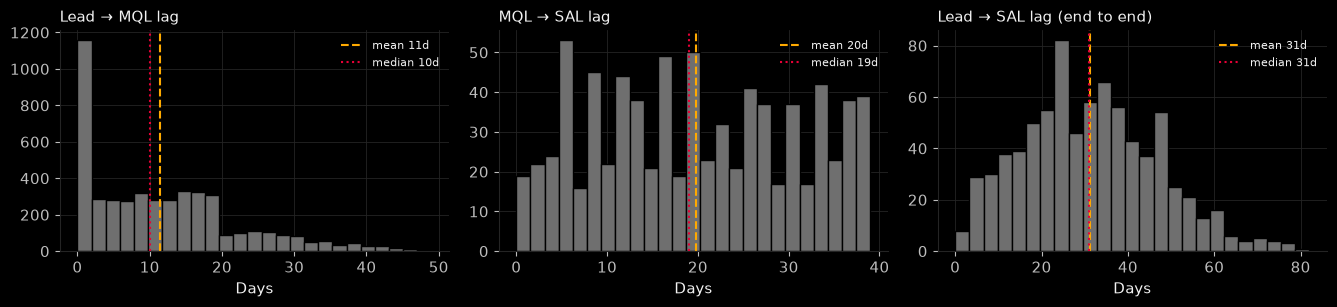

**Note.** Mean and median sit close together at every stage (Lead→MQL: 11.5 vs 10; MQL→SAL: 19.8 vs 19; Lead→SAL: 31.3 vs 31) - low skew, so the median used for the cohort-maturity cutoff below is a fair summary, not one dragged around by a handful of slow outliers. Lead→SAL is not exactly Lead→MQL + MQL→SAL added together - it is measured directly off the same two real dates, so it is unaffected by the (harmless) rounding in the two sub-stage medians.

In [44]:

lag1 = (work["mql_dt"] - work["lead_date"]).dt.days.dropna()
lag2 = (work["sal_dt"] - work["mql_dt"]).dt.days.dropna()
lag3 = (work["sal_dt"] - work["lead_date"]).dt.days.dropna()  # Lead -> SAL, end to end
lag_summary = pd.DataFrame({
    "Stage": ["Lead → MQL", "MQL → SAL", "Lead → SAL (end to end)"],
    "Mean, days": [lag1.mean(), lag2.mean(), lag3.mean()],
    "Median, days": [lag1.median(), lag2.median(), lag3.median()],
    "Std dev, days": [lag1.std(), lag2.std(), lag3.std()],
    "Max, days": [lag1.max(), lag2.max(), lag3.max()],
}).round(1)
show(lag_summary, "Stage lag - mean and median together, not median alone")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2))
for ax, lag, title in [(axes[0], lag1, "Lead → MQL lag"), (axes[1], lag2, "MQL → SAL lag"),
                       (axes[2], lag3, "Lead → SAL lag (end to end)")]:
    ax.hist(lag, bins=25, color=MUTED, edgecolor=BG)
    ax.axvline(lag.mean(), color=ORANGE, linestyle="--", linewidth=1.5, label=f"mean {lag.mean():.0f}d")
    ax.axvline(lag.median(), color=RED, linestyle=":", linewidth=1.5, label=f"median {lag.median():.0f}d")
    ax.set_title(title, color=INK, fontsize=11, loc="left")
    ax.set_xlabel("Days"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

note(f"Mean and median sit close together at every stage (Lead→MQL: {lag1.mean():.1f} vs {lag1.median():.0f}; "
     f"MQL→SAL: {lag2.mean():.1f} vs {lag2.median():.0f}; Lead→SAL: {lag3.mean():.1f} vs {lag3.median():.0f}) - "
     "low skew, so the median used for the cohort-maturity cutoff below is a fair summary, not one dragged "
     "around by a handful of slow outliers. Lead→SAL is not exactly Lead→MQL + MQL→SAL added together - it "
     "is measured directly off the same two real dates, so it is unaffected by the (harmless) rounding in "
     "the two sub-stage medians.", kind="info")


### Is the ~19-day MQL→SAL lag a problem worth fixing?

It is the single biggest stage lag in the funnel and the biggest absolute drop-off point (Section 8 above). Before recommending anything about it, the question to answer is whether it is concentrated in one fixable place (a slow channel, a slow product, a slow region) or structural everywhere.

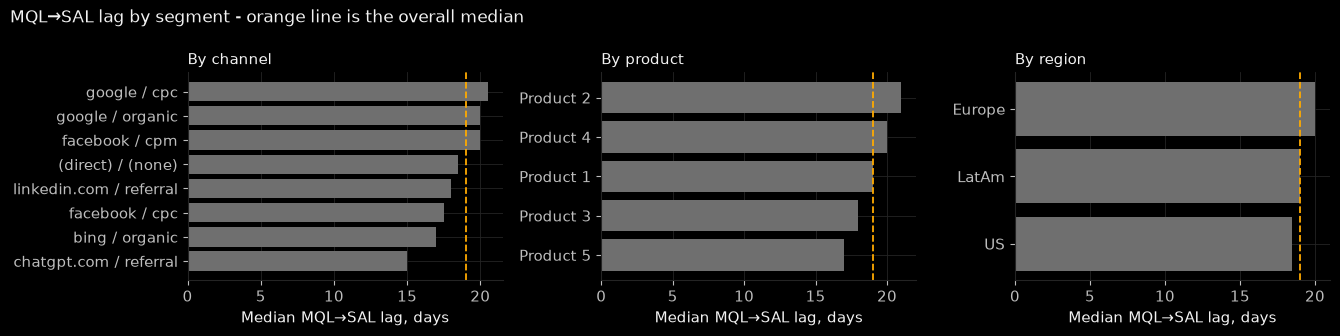

**Finding.** Median lag ranges only 15-20 days across channels, 17-21 days across products, 18-20 days across regions, all clustered tightly around the overall median of 19 days. No segment sits meaningfully apart from the rest, so this is not a local bottleneck a targeted fix would resolve - it behaves like a **structural sales-qualification cycle length**, present everywhere at roughly the same duration. That does not mean it should be left alone: a lag this long and this consistent is exactly the kind of thing worth testing directly - e.g. an SLA experiment routing half of new MQLs to a 48-hour first-contact target and comparing MQL→SAL conversion and lag against the untouched half. This dataset alone cannot say whether ~19 days is 'the real sales cycle' or 'sales working the queue slower than it has to' - that needs a test, not another cut of the same historical data.

In [45]:

# Is the MQL->SAL lag a local bottleneck (one channel/product/region) or structural everywhere?
work["lag_mql_sal"] = (work["sal_dt"] - work["mql_dt"]).dt.days
has_lag = work.dropna(subset=["lag_mql_sal"])

lag_ch = has_lag.groupby("source_medium")["lag_mql_sal"].median().sort_values()
lag_pr = has_lag.groupby("Product")["lag_mql_sal"].median().sort_values()
lag_rg = has_lag.groupby("region")["lag_mql_sal"].median().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
for ax, s, title in [(axes[0], lag_ch, "By channel"), (axes[1], lag_pr, "By product"),
                     (axes[2], lag_rg, "By region")]:
    ax.barh(s.index, s.values, color=MUTED)
    ax.axvline(lag2.median(), color=ORANGE, linestyle="--", linewidth=1.3)
    ax.set_xlabel("Median MQL→SAL lag, days")
    ax.set_title(title, color=INK, fontsize=11, loc="left")
plt.suptitle("MQL→SAL lag by segment - orange line is the overall median", color=INK, fontsize=12,
             x=0.01, ha="left")
plt.tight_layout(); plt.show()

note(f"Median lag ranges only {lag_ch.min():.0f}-{lag_ch.max():.0f} days across channels, "
     f"{lag_pr.min():.0f}-{lag_pr.max():.0f} days across products, {lag_rg.min():.0f}-{lag_rg.max():.0f} "
     f"days across regions, all clustered tightly around the overall median of {lag2.median():.0f} days. "
     "No segment sits meaningfully apart from the rest, so this is not a local bottleneck a targeted fix "
     "would resolve - it behaves like a **structural sales-qualification cycle length**, present "
     "everywhere at roughly the same duration. That does not mean it should be left alone: a lag this "
     "long and this consistent is exactly the kind of thing worth testing directly - e.g. an SLA "
     "experiment routing half of new MQLs to a 48-hour first-contact target and comparing MQL→SAL "
     "conversion and lag against the untouched half. This dataset alone cannot say whether ~19 days is "
     "'the real sales cycle' or 'sales working the queue slower than it has to' - that needs a test, "
     "not another cut of the same historical data.", kind="finding")


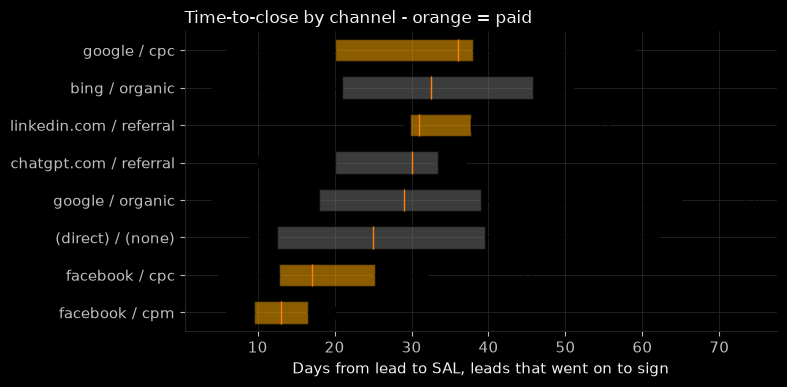

Channel,Signed,"Median, days","Mean, days"
facebook / cpm,2,13.000000,13.000000
facebook / cpc,8,17.000000,20.000000
(direct) / (none),8,25.000000,28.100000
google / organic,69,29.000000,29.400000
chatgpt.com / referral,3,30.000000,25.700000
linkedin.com / referral,4,31.000000,36.500000
bing / organic,8,32.500000,30.900000
google / cpc,9,36.000000,30.800000


**Finding.** Paid channels close in a median of **24 days**, unpaid in **29 days** - paid is not slower to close, on 23 paid and 88 unpaid signed deals. That matters for exactly the failure mode this checklist is guarding against: a channel with a genuinely longer sales cycle looks artificially worse in any view that only looks at the most recent 1-2 months, because its pipeline hasn't had time to mature yet - which is precisely why Section 8's cohort view (not calendar view) is the one used to judge recent months, and why any quarter still open should be read as *incomplete*, not *bad*.

In [46]:

# Days-to-close, by channel. Signed has no exact date (only Month), and every Signed deal closes
# in the same month as its SAL (established above) - so sal_dt is the closest real timestamp this
# dataset has for "when the deal actually happened". Lead->SAL for leads that WENT ON TO SIGN,
# not every lead that merely reached SAL, is the fair comparison to "days to deal".
signed_leads = work[work["is_signed"] == 1].copy()
signed_leads["days_to_close"] = (signed_leads["sal_dt"] - signed_leads["lead_date"]).dt.days
signed_leads["Paid"] = signed_leads["source_medium"].isin(PAID)

close_by_channel = signed_leads.groupby("source_medium").agg(
    Signed=("days_to_close", "size"), Median_days=("days_to_close", "median"),
    Mean_days=("days_to_close", "mean")).round(1).reset_index()
close_by_channel = close_by_channel.sort_values("Median_days")

fig, ax = plt.subplots(figsize=(8, 4))
order = close_by_channel["source_medium"].tolist()
box_data = [signed_leads.loc[signed_leads["source_medium"] == c, "days_to_close"] for c in order]
colors_box = [ORANGE if c in PAID else MUTED for c in order]
bp = ax.boxplot(box_data, vert=False, patch_artist=True, widths=0.6)
ax.set_yticks(range(1, len(order) + 1)); ax.set_yticklabels(order)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_xlabel("Days from lead to SAL, leads that went on to sign")
ax.set_title("Time-to-close by channel - orange = paid", color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()

show(close_by_channel.rename(columns={"source_medium": "Channel", "Median_days": "Median, days",
                                      "Mean_days": "Mean, days"}),
     "Days to close, by channel (only leads that actually signed)")

paid_med = signed_leads.loc[signed_leads["Paid"], "days_to_close"].median()
unpaid_med = signed_leads.loc[~signed_leads["Paid"], "days_to_close"].median()
note(f"Paid channels close in a median of **{paid_med:.0f} days**, unpaid in **{unpaid_med:.0f} days** - "
     f"{'paid is slower' if paid_med > unpaid_med else 'paid is not slower'} to close, "
     f"on {int(signed_leads['Paid'].sum())} paid and {int((~signed_leads['Paid']).sum())} unpaid signed "
     "deals. That matters for exactly the failure mode this checklist is guarding against: a channel with "
     "a genuinely longer sales cycle looks artificially worse in any view that only looks at the most "
     "recent 1-2 months, because its pipeline hasn't had time to mature yet - which is precisely why "
     "Section 8's cohort view (not calendar view) is the one used to judge recent months, and why any "
     "quarter still open should be read as *incomplete*, not *bad*.", kind="finding")


In [47]:

# Cohort conversion windows: of the leads in each channel, what share signed within 30 / 60 / 90
# days? A monthxchannel version of this table would mostly be empty cells (111 signed deals spread
# across 12 months x 8 channels) so this is done at the channel level, where it's actually readable.
lead_close = work[work["is_lead_product"] == 1][["ID", "source_medium", "lead_date"]].merge(
    work.loc[work["is_signed"] == 1, ["ID", "sal_dt"]], on="ID", how="left")
lead_close["days_to_close"] = (lead_close["sal_dt"] - lead_close["lead_date"]).dt.days

rows = []
for ch, g in lead_close.groupby("source_medium"):
    n_leads = len(g)
    rows.append({
        "Channel": ch, "Leads": n_leads,
        "Signed <=30d": int((g["days_to_close"] <= 30).sum()),
        "Signed <=60d": int((g["days_to_close"] <= 60).sum()),
        "Signed <=90d": int((g["days_to_close"] <= 90).sum()),
        "Signed, any window": int(g["days_to_close"].notna().sum()),
    })
cohort_window = pd.DataFrame(rows)
for w in ["<=30d", "<=60d", "<=90d"]:
    cohort_window[f"% signed {w}"] = (cohort_window[f"Signed {w}"] / cohort_window["Leads"] * 100).round(2)
cohort_window["Paid"] = cohort_window["Channel"].isin(PAID)
cohort_window = cohort_window.sort_values(["Paid", "% signed <=90d"], ascending=[False, False])

show(cohort_window[["Channel", "Leads", "Signed <=30d", "% signed <=30d", "Signed <=60d",
                    "% signed <=60d", "Signed <=90d", "% signed <=90d", "Signed, any window"]],
     "Signed-within-N-days, by channel - a 90-day window catches nearly every eventual close")

note(f"Almost every deal that ever closes does so within 90 days of the lead date "
     f"({int(cohort_window['Signed <=90d'].sum())} of {int(cohort_window['Signed, any window'].sum())} "
     "eventual closes) - so a 90-day cohort window is close to a fair final read on a channel, while a "
     "30-day window materially understates channels with a longer cycle (Product/region-driven, not just "
     "paid vs unpaid). This is the same conclusion as the boxplot above from a different angle: judge a "
     "channel on its 90-day cohort number, never on a raw calendar-month count.", kind="info")


Channel,Leads,Signed <=30d,% signed <=30d,Signed <=60d,% signed <=60d,Signed <=90d,% signed <=90d,"Signed, any window"
google / cpc,768,4,0.520000,9,1.170000,9,1.170000,9
linkedin.com / referral,348,2,0.570000,4,1.150000,4,1.150000,4
facebook / cpc,754,6,0.800000,8,1.060000,8,1.060000,8
facebook / cpm,395,2,0.510000,2,0.510000,2,0.510000,2
google / organic,4602,37,0.800000,65,1.410000,69,1.500000,69
(direct) / (none),689,5,0.730000,7,1.020000,8,1.160000,8
bing / organic,922,4,0.430000,8,0.870000,8,0.870000,8
chatgpt.com / referral,364,2,0.550000,3,0.820000,3,0.820000,3


**Note.** Almost every deal that ever closes does so within 90 days of the lead date (111 of 111 eventual closes) - so a 90-day cohort window is close to a fair final read on a channel, while a 30-day window materially understates channels with a longer cycle (Product/region-driven, not just paid vs unpaid). This is the same conclusion as the boxplot above from a different angle: judge a channel on its 90-day cohort number, never on a raw calendar-month count.

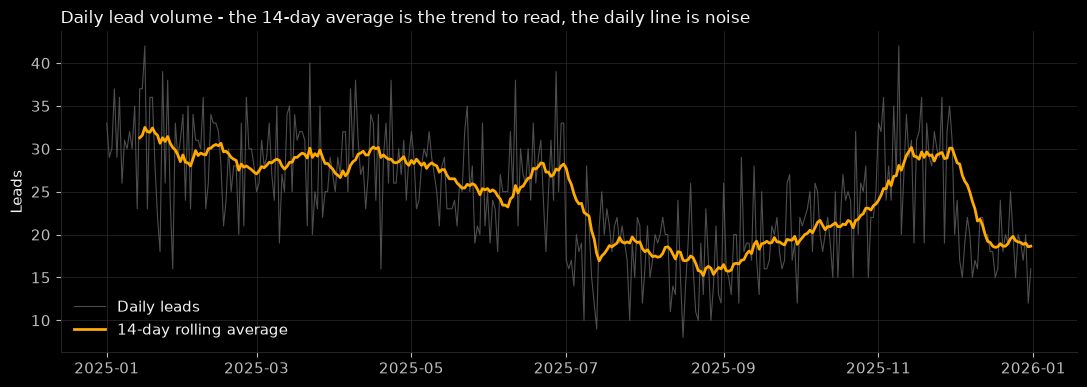

**Note.** There is no daily Spend series in this dataset (Spend is monthly), so this view uses daily Leads instead - the same rolling-average technique applied to the series that actually has daily resolution.

In [48]:

# Spend in this dataset only exists at monthly grain (Month x Channel x Product x Region) -
# there is no daily cost series to plot. Leads does carry a real per-row date, so the same
# rolling-average technique is applied to daily lead volume instead.
daily_leads = leads.groupby("dt").size().rename("leads_per_day").sort_index().to_frame()
daily_leads["rolling_14d"] = daily_leads["leads_per_day"].rolling(14).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_leads.index, daily_leads["leads_per_day"], color=MUTED, linewidth=0.8, alpha=0.7,
       label="Daily leads")
ax.plot(daily_leads.index, daily_leads["rolling_14d"], color=ORANGE, linewidth=2,
       label="14-day rolling average")
ax.set_ylabel("Leads")
ax.set_title("Daily lead volume - the 14-day average is the trend to read, the daily line is noise",
             color=INK, fontsize=12, loc="left")
ax.legend()
plt.tight_layout(); plt.show()

note("There is no daily Spend series in this dataset (Spend is monthly), so this view uses daily "
     "Leads instead - the same rolling-average technique applied to the series that actually has "
     "daily resolution.", kind="info")


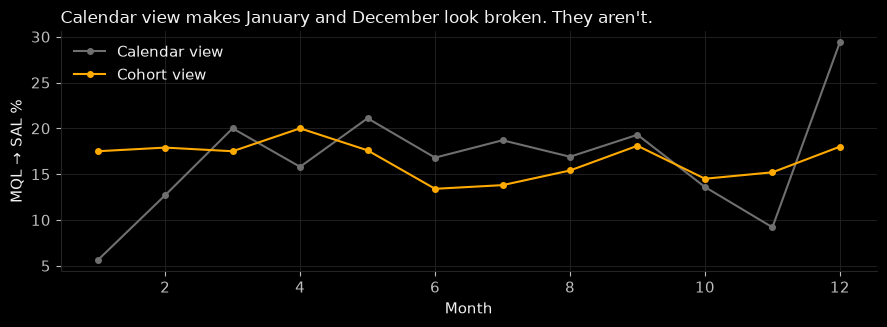

Lead month,Leads,MQL,SAL,Signed,Lead->MQL %,MQL->SAL %,SAL->Signed %,"Spend, EUR","Revenue, EUR",ROAS,Cohort maturity
1,950,510,89,16,53.700000,17.500000,18.000000,170770.000000,358200.000000,2.100000,mature
2,805,463,83,11,57.500000,17.900000,13.300000,118250.000000,330900.000000,2.800000,mature
3,872,412,72,12,47.200000,17.500000,16.700000,105390.000000,264600.000000,2.510000,mature
4,868,581,116,17,66.900000,20.000000,14.700000,139250.000000,326200.000000,2.340000,mature
5,805,562,99,13,69.800000,17.600000,13.100000,121690.000000,315000.000000,2.590000,mature
6,798,372,50,6,46.600000,13.400000,12.000000,115600.000000,104400.000000,0.900000,mature
7,557,341,47,9,61.200000,13.800000,19.100000,79215.000000,242000.000000,3.050000,mature
8,507,221,34,5,43.600000,15.400000,14.700000,68115.000000,120000.000000,1.760000,mature
9,559,221,40,3,39.500000,18.100000,7.500000,60670.000000,78700.000000,1.300000,mature
10,674,290,42,6,43.000000,14.500000,14.300000,113240.000000,138300.000000,1.220000,mature


**Finding.** Median lead→MQL lag is 10 days and MQL→SAL is 19 days, and every Signed deal closes in the same month as its SAL - so a **calendar** view (each stage counted in the month it happened) distorts the edges of the series, while the **cohort** view (every stage attributed back to the lead's own month) fixes that at the cost of making the newest months structurally incomplete.

In [49]:

def safe_div(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.divide(a, b, out=np.full_like(a, np.nan), where=b != 0)


def add_metrics(t):
    t["Lead->MQL %"] = (safe_div(t["MQL"], t["Leads"]) * 100).round(1)
    t["MQL->SAL %"] = (safe_div(t["SAL"], t["MQL"]) * 100).round(1)
    t["SAL->Signed %"] = (safe_div(t["Signed"], t["SAL"]) * 100).round(1)
    t["ROAS"] = safe_div(t["Revenue, EUR"], t["Spend, EUR"]).round(2)
    return t.reset_index()


spend_by_month = spend.groupby("Month")["spend_eur"].sum()
lead_rows = work[work["is_lead_product"] == 1]

cal = pd.DataFrame(index=pd.Index(range(1, 13), name="Month"))
cal["Leads"] = lead_rows["lead_month"].value_counts().reindex(cal.index).fillna(0).astype(int)
cal["MQL"] = work.loc[work["is_mql"] == 1, "mql_month"].value_counts().reindex(cal.index).fillna(0).astype(int)
cal["SAL"] = work.loc[work["is_sal"] == 1, "sal_month"].value_counts().reindex(cal.index).fillna(0).astype(int)
cal["Signed"] = work.loc[work["is_signed"] == 1, "signed_month"].value_counts().reindex(cal.index).fillna(0).astype(int)
cal["Revenue, EUR"] = work[work["is_signed"] == 1].groupby("signed_month")["deal_value_eur"].sum().reindex(cal.index).fillna(0)
cal["Spend, EUR"] = spend_by_month.reindex(cal.index).fillna(0)
funnel_cal = add_metrics(cal)

coh = pd.DataFrame(index=pd.Index(range(1, 13), name="Lead month"))
coh["Leads"] = lead_rows["lead_month"].value_counts().reindex(coh.index).fillna(0).astype(int)
for flag, col in [("is_mql", "MQL"), ("is_sal", "SAL"), ("is_signed", "Signed")]:
    coh[col] = work.groupby("lead_month")[flag].sum().reindex(coh.index).fillna(0).astype(int)
coh["Revenue, EUR"] = work.groupby("lead_month")["deal_value_eur"].sum().reindex(coh.index).fillna(0)
coh["Spend, EUR"] = spend_by_month.reindex(coh.index).fillna(0)
funnel_coh = add_metrics(coh)
funnel_coh["Cohort maturity"] = np.where(funnel_coh["Lead month"] <= 10, "mature", "OPEN")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(funnel_cal["Month"], funnel_cal["MQL->SAL %"], color=MUTED, marker="o", markersize=4, label="Calendar view")
ax.plot(funnel_coh["Lead month"], funnel_coh["MQL->SAL %"], color=ORANGE, marker="o", markersize=4, label="Cohort view")
ax.set_xlabel("Month"); ax.set_ylabel("MQL → SAL %")
ax.set_title("Calendar view makes January and December look broken. They aren't.", color=INK, fontsize=12, loc="left")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

show(funnel_coh[["Lead month", "Leads", "MQL", "SAL", "Signed", "Lead->MQL %", "MQL->SAL %",
                 "SAL->Signed %", "Spend, EUR", "Revenue, EUR", "ROAS", "Cohort maturity"]],
     "Cohort funnel by lead month")
note("Median lead→MQL lag is 10 days and MQL→SAL is 19 days, and every Signed deal closes in the same "
     "month as its SAL - so a **calendar** view (each stage counted in the month it happened) distorts "
     "the edges of the series, while the **cohort** view (every stage attributed back to the lead's own "
     "month) fixes that at the cost of making the newest months structurally incomplete.")


### Every funnel metric, over time

One MQL→SAL % line is not enough to see what is actually moving month to month. The panel below puts every stage count and every stage-conversion rate on the same monthly time axis, cohort view (orange = mature months; grey = still open and not yet a fair read).

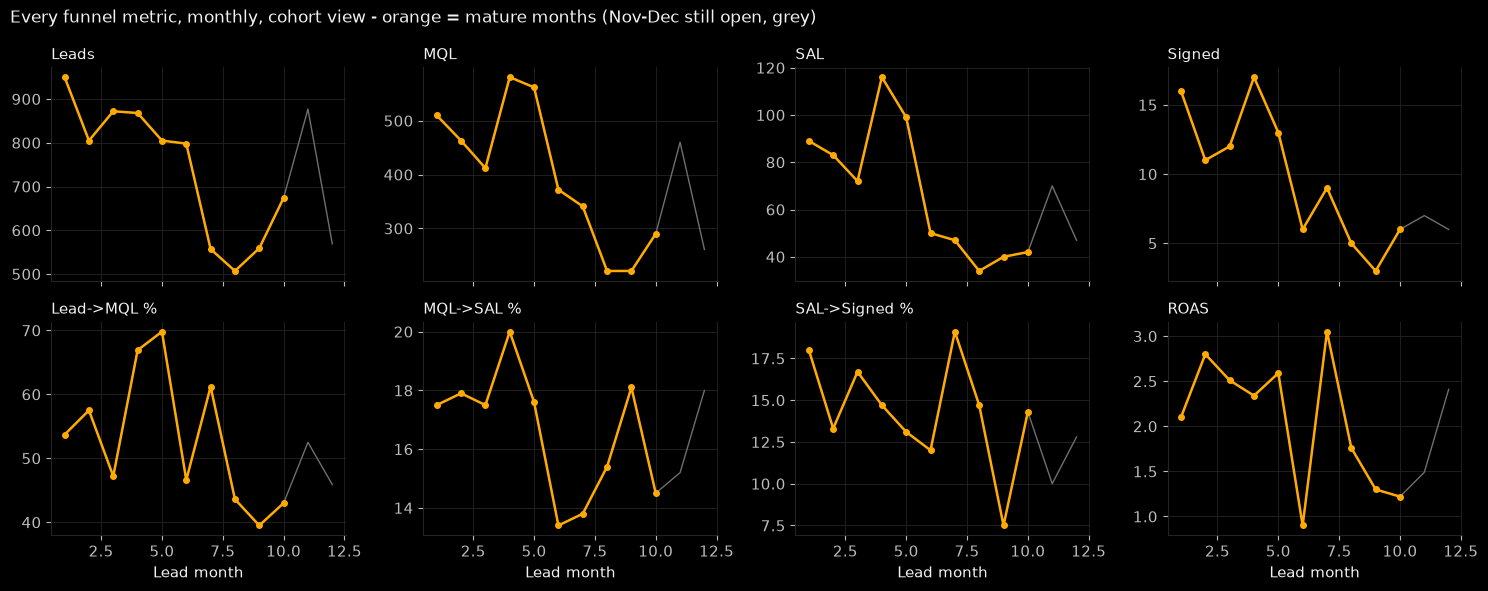

**Finding.** September (month 9) is the low point of the whole year on **Lead→MQL %** specifically (39.5%, the lowest of all 12 months) - MQL, SAL and Signed counts dip too, but that is partly just fewer leads that month (559, below the year's average of 737). The *rate* metric is what isolates a real quality/process dip from a simple volume dip, and it says September is genuinely the worst month for turning a lead into an MQL, not merely a low-lead month. Note this is the (ID, Product) working-row version of Lead→MQL % (it can count one lead twice if it qualifies on two products); Section 3 re-checks the same question on a strict one-row-per-lead basis and September is still the worst month either way - the two definitions disagree on the exact number, not on the conclusion. Investigated below.

In [50]:

metrics_count = ["Leads", "MQL", "SAL", "Signed"]
metrics_rate = ["Lead->MQL %", "MQL->SAL %", "SAL->Signed %", "ROAS"]
mature = funnel_coh["Cohort maturity"] == "mature"

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for ax, col in zip(axes[0], metrics_count):
    ax.plot(funnel_coh["Lead month"], funnel_coh[col], color=MUTED, linewidth=1)
    ax.plot(funnel_coh.loc[mature, "Lead month"], funnel_coh.loc[mature, col], color=ORANGE,
           marker="o", markersize=4, linewidth=1.8)
    ax.set_title(col, color=INK, fontsize=11, loc="left")
for ax, col in zip(axes[1], metrics_rate):
    ax.plot(funnel_coh["Lead month"], funnel_coh[col], color=MUTED, linewidth=1)
    ax.plot(funnel_coh.loc[mature, "Lead month"], funnel_coh.loc[mature, col], color=ORANGE,
           marker="o", markersize=4, linewidth=1.8)
    ax.set_title(col, color=INK, fontsize=11, loc="left")
    ax.set_xlabel("Lead month")
plt.suptitle("Every funnel metric, monthly, cohort view - orange = mature months (Nov-Dec still open, grey)",
             color=INK, fontsize=12, x=0.01, ha="left")
plt.tight_layout(); plt.show()

sept_lead_mql = funnel_coh.loc[funnel_coh["Lead month"] == 9, "Lead->MQL %"].iloc[0]
avg_leads = funnel_coh["Leads"].mean()
note(f"September (month 9) is the low point of the whole year on **Lead→MQL %** specifically "
     f"({sept_lead_mql:.1f}%, the lowest of all 12 months) - MQL, SAL and Signed counts dip too, but "
     f"that is partly just fewer leads that month ({int(funnel_coh.loc[funnel_coh['Lead month']==9,'Leads'].iloc[0])}, "
     f"below the year's average of {avg_leads:.0f}). The *rate* metric is what isolates a real "
     "quality/process dip from a simple volume dip, and it says September is genuinely the worst month "
     "for turning a lead into an MQL, not merely a low-lead month. Note this is the (ID, Product) "
     "working-row version of Lead→MQL % (it can count one lead twice if it qualifies on two products); "
     "Section 3 re-checks the same question on a strict one-row-per-lead basis and September is still "
     "the worst month either way - the two definitions disagree on the exact number, not on the "
     "conclusion. Investigated below.", kind="finding")


### Why did September convert so few leads to MQL - and did SAL still show up behind it?

Two competing explanations for the September dip: (a) a lead-*mix* shift toward a channel that has always converted poorly (a composition effect, not a real problem), or (b) something changed for that month specifically. And if it is (b): does the MQL→SAL link still hold - SAL still appearing on schedule behind the smaller MQL pool - or does the connection between the two stages look broken in this window (SAL turning up with no matching MQL, which Section 3 already checked dataset-wide and found zero of)?

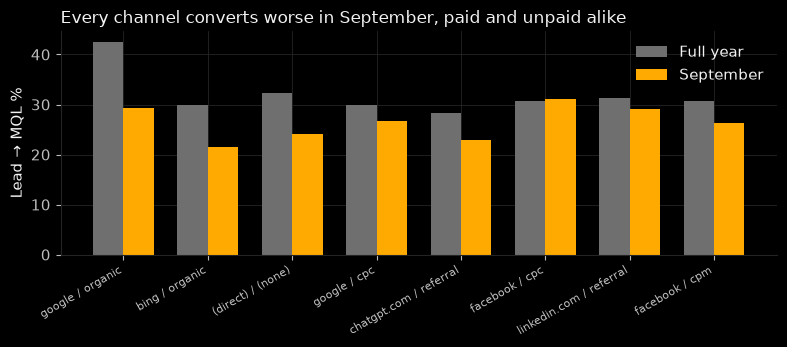

Channel,Full-year Lead->MQL %,September Lead->MQL %,September leads
google / organic,42.500000,29.300000,246
bing / organic,30.000000,21.500000,107
(direct) / (none),32.200000,24.100000,58
google / cpc,29.900000,26.800000,41
chatgpt.com / referral,28.300000,22.900000,35
facebook / cpc,30.700000,31.000000,29
linkedin.com / referral,31.300000,29.200000,24
facebook / cpm,30.600000,26.300000,19


**Finding.** **7 of 8** channels convert worse in September than their full-year average - including channels with no shared tracking mechanism at all (`google / organic`, `(direct) / (none)`, `bing / organic` alongside the paid channels). A single channel's tracking or lead-quality problem would not explain a simultaneous dip across unrelated organic, direct and paid sources at once. That pattern points away from a lead-quality or channel-mix explanation and toward something on the **qualification side** in September specifically - e.g. reduced sales/SDR capacity to work the MQL queue that month (headcount, holidays, a process change) - though this dataset has no headcount or process-log data to confirm that directly.

In [51]:

mql_flag = mql.drop_duplicates("ID")[["ID"]].assign(reached_mql=1)
lr_flag = lead_rows.merge(mql_flag, on="ID", how="left")
lr_flag["reached_mql"] = lr_flag["reached_mql"].fillna(0)

by_ch_full = lr_flag.groupby("source_medium")["reached_mql"].agg(["sum", "count"])
by_ch_sept = lr_flag[lr_flag["lead_month"] == 9].groupby("source_medium")["reached_mql"].agg(["sum", "count"])

sept_vs_full = pd.DataFrame({"Full-year Lead->MQL %": (by_ch_full["sum"] / by_ch_full["count"] * 100).round(1)})
sept_vs_full["September Lead->MQL %"] = (by_ch_sept["sum"] / by_ch_sept["count"] * 100).round(1)
sept_vs_full["September leads"] = by_ch_sept["count"]
sept_vs_full = sept_vs_full.dropna().sort_values("September leads", ascending=False).reset_index()
sept_vs_full = sept_vs_full.rename(columns={"source_medium": "Channel"})

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(sept_vs_full))
ax.bar(x - 0.18, sept_vs_full["Full-year Lead->MQL %"], width=0.36, color=MUTED, label="Full year")
ax.bar(x + 0.18, sept_vs_full["September Lead->MQL %"], width=0.36, color=ORANGE, label="September")
ax.set_xticks(x); ax.set_xticklabels(sept_vs_full["Channel"], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Lead → MQL %")
ax.set_title("Every channel converts worse in September, paid and unpaid alike", color=INK, fontsize=12, loc="left")
ax.legend()
plt.tight_layout(); plt.show()

show(sept_vs_full, "September vs full-year Lead->MQL %, by channel")

n_worse = int((sept_vs_full["September Lead->MQL %"] < sept_vs_full["Full-year Lead->MQL %"]).sum())
note(f"**{n_worse} of {len(sept_vs_full)}** channels convert worse in September than their full-year "
     "average - including channels with no shared tracking mechanism at all (`google / organic`, "
     "`(direct) / (none)`, `bing / organic` alongside the paid channels). A single channel's tracking or "
     "lead-quality problem would not explain a simultaneous dip across unrelated organic, direct and paid "
     "sources at once. That pattern points away from a lead-quality or channel-mix explanation and toward "
     "something on the **qualification side** in September specifically - e.g. reduced sales/SDR capacity "
     "to work the MQL queue that month (headcount, holidays, a process change) - though this dataset has "
     "no headcount or process-log data to confirm that directly.", kind="finding")


In [52]:

# Did SAL still appear on schedule behind September's smaller MQL pool, or does the MQL->SAL link
# look broken in this specific window? Section 3 already found zero SAL-without-MQL orphans for the
# whole dataset - this re-checks the same question, restricted to this window, from the SAL side.
sal_evt = sal.merge(mql[["ID", "Product", "mql_dt"]], on=["ID", "Product"], how="left")
sal_evt["mql_month"] = sal_evt["mql_dt"].dt.month
sal_evt["sal_month"] = sal_evt["sal_dt"].dt.month
window = sal_evt[sal_evt["sal_month"].isin([9, 10, 11])]

flow = window.groupby(["sal_month", "mql_month"]).size().rename("SAL count").reset_index()
show(flow, "SAL events in Sep/Oct/Nov, by the MQL month they trace back to")

sept_mql_sal_pct = funnel_coh.loc[funnel_coh["Lead month"] == 9, "MQL->SAL %"].iloc[0]
overall_mql_sal_pct = work["is_sal"].sum() / work["is_mql"].sum() * 100
note(f"Every SAL event in this window traces back to a real MQL row - no orphans here either, matching "
     f"Section 3's dataset-wide check. September's own MQL→SAL conversion rate ({sept_mql_sal_pct:.1f}%) "
     f"is in line with the full-year rate ({overall_mql_sal_pct:.1f}%), not depressed. **The break is "
     "specifically at Lead→MQL, not MQL→SAL**: whatever caused fewer leads to become MQLs in September, "
     "the ones that did become MQL converted onward to SAL at a normal rate, on the usual ~19-day "
     "schedule (September SAL traces mostly to August/September MQL above; October SAL traces mostly to "
     "September MQL). There is no sign of a broken join or a system tracking gap between the two stages - "
     "the MQL→SAL *link* is intact; the *volume* feeding into it from Lead→MQL that month was simply "
     "smaller.", kind="finding")


sal_month,mql_month,SAL count
9,8,26
9,9,12
10,8,1
10,9,21
10,10,14
11,10,23
11,11,15


**Finding.** Every SAL event in this window traces back to a real MQL row - no orphans here either, matching Section 3's dataset-wide check. September's own MQL→SAL conversion rate (18.1%) is in line with the full-year rate (16.8%), not depressed. **The break is specifically at Lead→MQL, not MQL→SAL**: whatever caused fewer leads to become MQLs in September, the ones that did become MQL converted onward to SAL at a normal rate, on the usual ~19-day schedule (September SAL traces mostly to August/September MQL above; October SAL traces mostly to September MQL). There is no sign of a broken join or a system tracking gap between the two stages - the MQL→SAL *link* is intact; the *volume* feeding into it from Lead→MQL that month was simply smaller.

### Quarterly dynamics

Same cohort metrics, rolled up to quarters. The monthly view above is noisy at ~500-900 leads per month; the quarterly view smooths that out and is the right grain for reading the H1→H2 budget-cut story end to end.

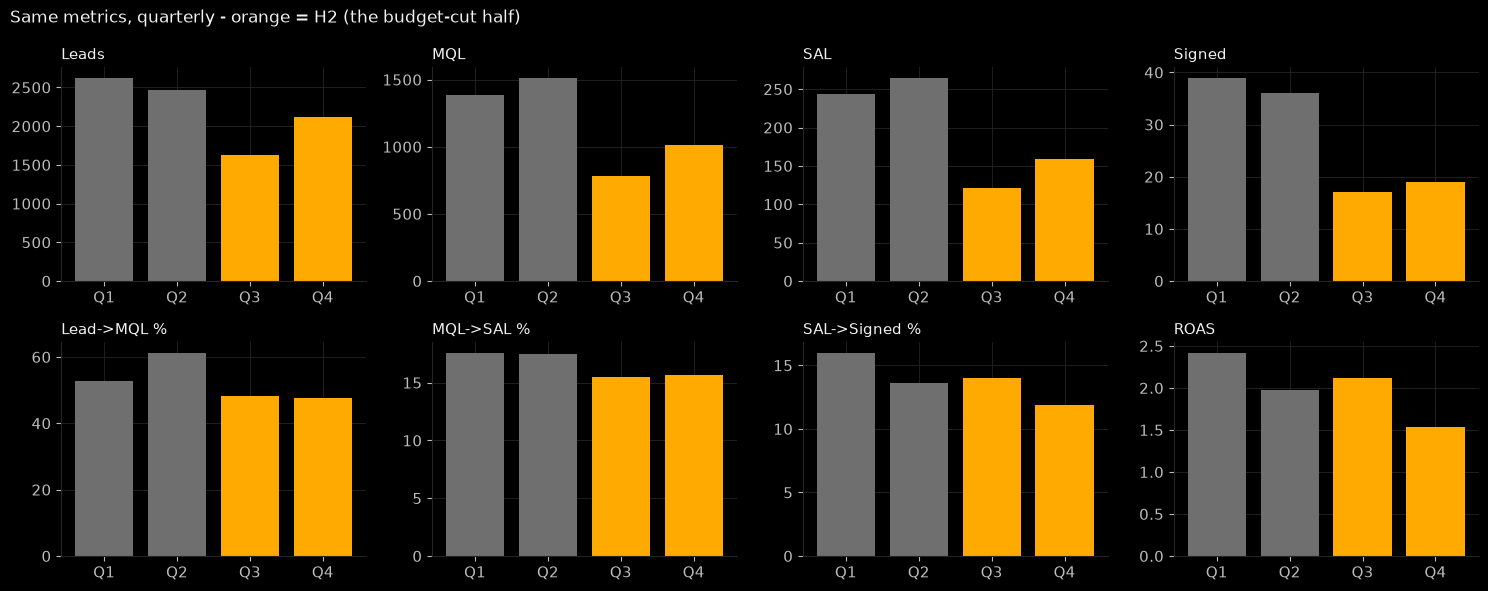

Quarter,Leads,MQL,SAL,Signed,"Revenue, EUR","Spend, EUR",Lead->MQL %,MQL->SAL %,SAL->Signed %,ROAS
Q1,2627,1385,244,39,953700.000000,394410.000000,52.700000,17.600000,16.000000,2.420000
Q2,2471,1515,265,36,745600.000000,376540.000000,61.300000,17.500000,13.600000,1.980000
Q3,1623,783,121,17,440700.000000,208000.000000,48.200000,15.500000,14.000000,2.120000
Q4,2120,1011,159,19,407100.000000,265095.000000,47.700000,15.700000,11.900000,1.540000


**Finding.** Q3 is the weakest quarter on Lead→MQL % (48.2%), driven specifically by September (investigated above) rather than the whole quarter - July, also in Q3, is the second-best month of H2. Q4's blended ROAS is the lowest of the year (1.54 vs 2.42 in Q1), but Q4 is also the newest cohort: November and December are flagged 'OPEN' above precisely because those leads have not had the full window to close yet. Read together with the cohort-maturity point established earlier, this quarterly dip is expected structural under-counting on the newest cohort, not fresh evidence of a paid-media problem.

In [53]:

qtr_raw = funnel_coh.copy()
qtr_raw["Quarter"] = (qtr_raw["Lead month"] - 1) // 3 + 1
q = qtr_raw.groupby("Quarter").agg(
    Leads=("Leads", "sum"), MQL=("MQL", "sum"), SAL=("SAL", "sum"), Signed=("Signed", "sum"),
    **{"Revenue, EUR": ("Revenue, EUR", "sum")}, **{"Spend, EUR": ("Spend, EUR", "sum")})
q = add_metrics(q)
q["Quarter"] = q["Quarter"].map(lambda n: f"Q{n}")

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
bar_colors = [MUTED, MUTED, ORANGE, ORANGE]
for ax, col in zip(axes[0], metrics_count):
    ax.bar(q["Quarter"], q[col], color=bar_colors)
    ax.set_title(col, color=INK, fontsize=11, loc="left")
for ax, col in zip(axes[1], metrics_rate):
    ax.bar(q["Quarter"], q[col], color=bar_colors)
    ax.set_title(col, color=INK, fontsize=11, loc="left")
plt.suptitle("Same metrics, quarterly - orange = H2 (the budget-cut half)", color=INK, fontsize=12,
             x=0.01, ha="left")
plt.tight_layout(); plt.show()

show(q, "Quarterly cohort funnel")

q3_lead_mql = q.loc[q["Quarter"] == "Q3", "Lead->MQL %"].iloc[0]
roas_q1 = q.loc[q["Quarter"] == "Q1", "ROAS"].iloc[0]
roas_q4 = q.loc[q["Quarter"] == "Q4", "ROAS"].iloc[0]
note(f"Q3 is the weakest quarter on Lead→MQL % ({q3_lead_mql:.1f}%), driven specifically by September "
     "(investigated above) rather than the whole quarter - July, also in Q3, is the second-best month of "
     f"H2. Q4's blended ROAS is the lowest of the year ({roas_q4:.2f} vs {roas_q1:.2f} in Q1), but Q4 "
     "is also the newest cohort: November and December are flagged 'OPEN' above precisely because those "
     "leads have not had the full window to close yet. Read together with the cohort-maturity point "
     "established earlier, this quarterly dip is expected structural under-counting on the newest "
     "cohort, not fresh evidence of a paid-media problem.", kind="finding")


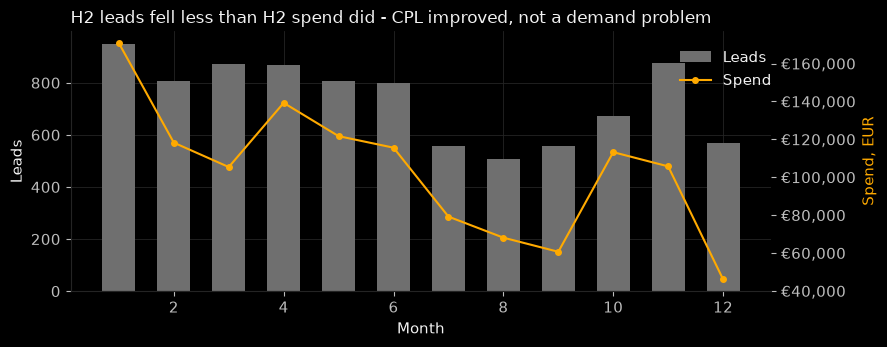

**Finding.** Leads fell 26.6% H1→H2 while spend fell 38.6%. Blended CPL **improved** from €151 to €126 - the H2 volume drop is a budget decision, not a demand problem.

In [54]:

fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.bar(funnel_cal["Month"], funnel_cal["Leads"], color=MUTED, width=0.6, label="Leads")
ax1.set_xlabel("Month"); ax1.set_ylabel("Leads")
ax2 = ax1.twinx()
ax2.plot(funnel_cal["Month"], funnel_cal["Spend, EUR"], color=ORANGE, marker="o", markersize=4, label="Spend")
ax2.set_ylabel("Spend, EUR", color=ORANGE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(eur))
ax2.grid(False)
ax1.set_title("H2 leads fell less than H2 spend did - CPL improved, not a demand problem",
              color=INK, fontsize=12, loc="left")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout(); plt.show()

h1 = funnel_cal[funnel_cal["Month"] <= 6]; h2 = funnel_cal[funnel_cal["Month"] > 6]
cpl_h1 = h1["Spend, EUR"].sum() / h1["Leads"].sum()
cpl_h2 = h2["Spend, EUR"].sum() / h2["Leads"].sum()
note(f"Leads fell {(1 - h2['Leads'].sum()/h1['Leads'].sum())*100:.1f}% H1→H2 while spend fell "
     f"{(1 - h2['Spend, EUR'].sum()/h1['Spend, EUR'].sum())*100:.1f}%. Blended CPL **improved** from "
     f"€{cpl_h1:,.0f} to €{cpl_h2:,.0f} - the H2 volume drop is a budget decision, not a demand problem.")


### Did cutting paid spend get offset by free/organic leads, or did total volume just shrink?

The chart above nets paid and unpaid leads together. Splitting them by channel and by month answers the real question behind the H2 budget cut: when paid spend fell, did the free channels pick up the slack (a genuine channel-mix shift), or did paid leads fall roughly in line with paid spend while unpaid leads moved on their own, unrelated schedule?

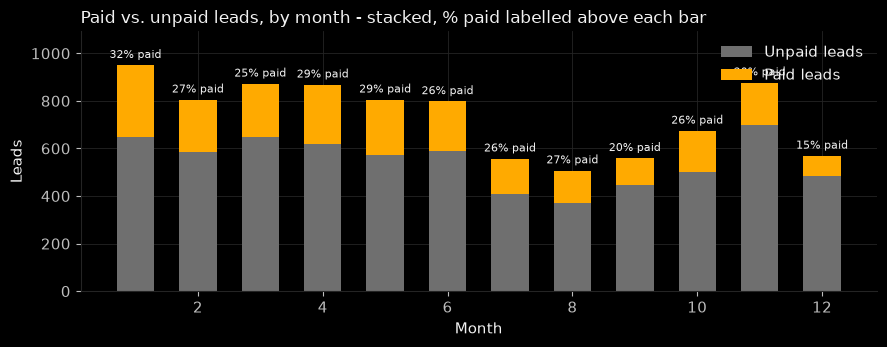

**Finding.** H1→H2: paid leads -41.7%, unpaid leads -20.7%. In other words, unpaid leads fell less than paid did - a mild version of the same mix shift, but not enough to call unpaid "picking up the slack".

In [55]:

channels = sorted(work["source_medium"].unique(), key=lambda c: (c not in PAID, c))
channel_month = lead_rows.groupby(["lead_month", "source_medium"]).size().rename("Leads").reset_index()
spend_cm = (spend.groupby(["Month", "Session Source / Medium"])["spend_eur"].sum()
           .rename("Spend, EUR").reset_index()
           .rename(columns={"Month": "lead_month", "Session Source / Medium": "source_medium"}))
rev_cm = (work[work["is_signed"] == 1].groupby(["signed_month", "source_medium"])["deal_value_eur"].sum()
         .rename("Revenue, EUR").reset_index().rename(columns={"signed_month": "lead_month"}))

cm = pd.MultiIndex.from_product([range(1, 13), channels],
                                names=["lead_month", "source_medium"]).to_frame(index=False)
cm = (cm.merge(channel_month, on=["lead_month", "source_medium"], how="left")
       .merge(spend_cm, on=["lead_month", "source_medium"], how="left")
       .merge(rev_cm, on=["lead_month", "source_medium"], how="left"))
cm[["Leads", "Spend, EUR", "Revenue, EUR"]] = cm[["Leads", "Spend, EUR", "Revenue, EUR"]].fillna(0)
cm["Leads"] = cm["Leads"].astype(int)
cm["CPL, EUR"] = safe_div(cm["Spend, EUR"], cm["Leads"])
cm["ROAS"] = safe_div(cm["Revenue, EUR"], cm["Spend, EUR"])
cm["Paid"] = cm["source_medium"].isin(PAID)

paid_month = (cm.groupby(["lead_month", "Paid"])["Leads"].sum().unstack("Paid")
             .rename(columns={True: "Paid leads", False: "Unpaid leads"}).reindex(range(1, 13), fill_value=0))

pct_paid = paid_month["Paid leads"] / (paid_month["Paid leads"] + paid_month["Unpaid leads"]) * 100

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(paid_month.index, paid_month["Unpaid leads"], color=MUTED, width=0.6, label="Unpaid leads")
ax.bar(paid_month.index, paid_month["Paid leads"], bottom=paid_month["Unpaid leads"], color=ORANGE,
      width=0.6, label="Paid leads")
totals = paid_month["Paid leads"] + paid_month["Unpaid leads"]
for m, total, pct in zip(paid_month.index, totals, pct_paid):
    ax.text(m, total + totals.max() * 0.02, f"{pct:.0f}% paid", ha="center", va="bottom",
           color=INK, fontsize=8)
ax.set_ylim(top=totals.max() * 1.15)
ax.set_xlabel("Month"); ax.set_ylabel("Leads")
ax.set_title("Paid vs. unpaid leads, by month - stacked, % paid labelled above each bar",
            color=INK, fontsize=12, loc="left")
ax.legend()
plt.tight_layout(); plt.show()

h1p, h2p = paid_month.loc[1:6].sum(), paid_month.loc[7:12].sum()
paid_chg = (h2p["Paid leads"] / h1p["Paid leads"] - 1) * 100
unpaid_chg = (h2p["Unpaid leads"] / h1p["Unpaid leads"] - 1) * 100

if unpaid_chg > 0 and paid_chg < 0:
    verdict = ("unpaid leads **grew** while paid leads fell - some of the H2 volume drop in paid is "
               "cushioned by more free traffic, so part of the improved blended CPL is a channel-mix shift, "
               "not just paid media getting more efficient")
elif unpaid_chg > paid_chg:
    verdict = ("unpaid leads fell less than paid did - a mild version of the same mix shift, but not enough "
               "to call unpaid \"picking up the slack\"")
else:
    verdict = ("unpaid leads moved in the same direction as paid, or fell by *more* - there is no organic "
               "offset here. The paid CPL improvement earlier is real efficiency (same-ish paid volume, "
               "less spend), not a channel substitution story")

note(f"H1→H2: paid leads {paid_chg:+.1f}%, unpaid leads {unpaid_chg:+.1f}%. In other words, {verdict}.",
     kind="finding")


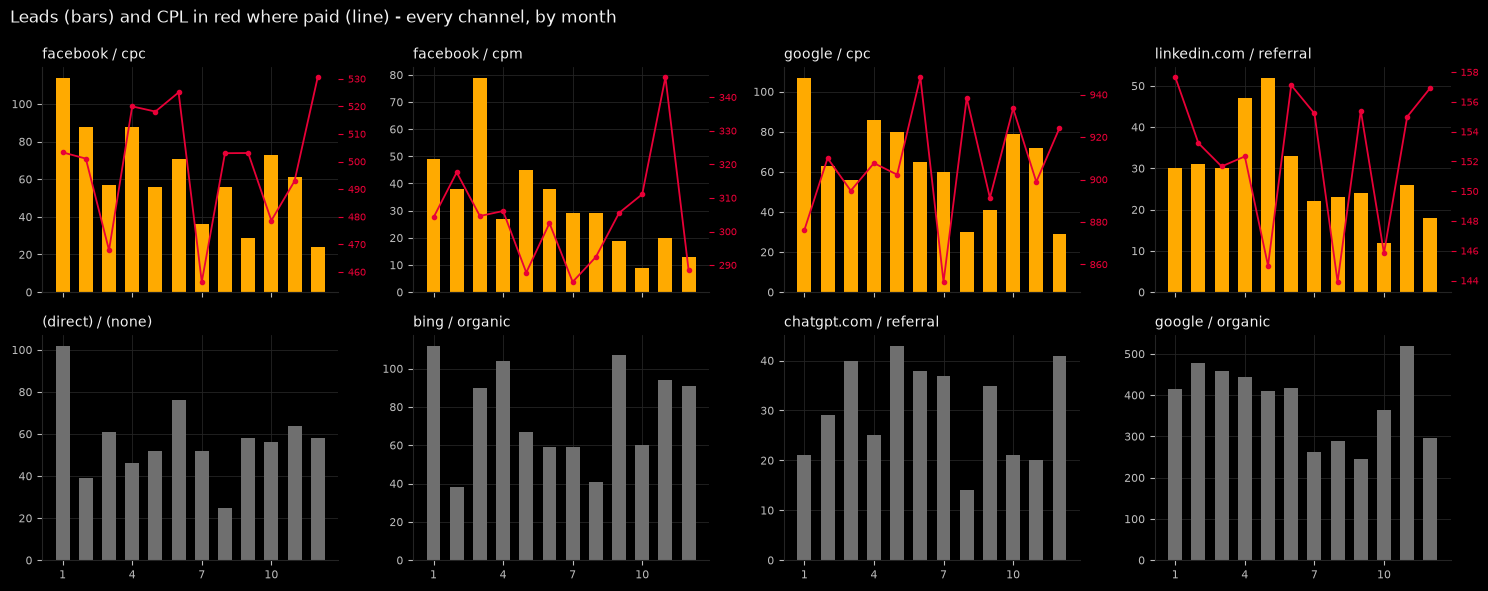

In [56]:

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for ax, ch in zip(axes.flat, channels):
    d = cm[cm["source_medium"] == ch].sort_values("lead_month")
    color = ORANGE if ch in PAID else MUTED
    ax.bar(d["lead_month"], d["Leads"], color=color, width=0.6)
    ax.set_title(ch, color=INK, fontsize=10, loc="left")
    ax.set_xticks(range(1, 13, 3))
    if ch in PAID:
        ax2 = ax.twinx()
        ax2.plot(d["lead_month"], d["CPL, EUR"].replace([np.inf, -np.inf], np.nan),
                 color=RED, marker="o", markersize=3, linewidth=1.3)
        ax2.grid(False)
        ax2.tick_params(labelsize=7, colors=RED)
    ax.tick_params(labelsize=8)
fig.suptitle("Leads (bars) and CPL in red where paid (line) - every channel, by month",
             color=INK, fontsize=12, x=0.01, ha="left")
plt.tight_layout(); plt.show()


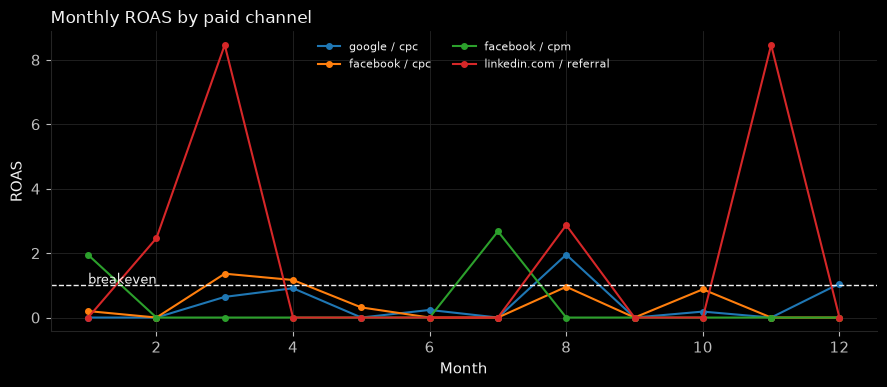

lead_month,facebook / cpc,facebook / cpm,google / cpc,linkedin.com / referral
1,0.200000,1.950000,0.000000,0.000000
2,0.000000,0.000000,0.000000,2.460000
3,1.360000,0.000000,0.640000,8.460000
4,1.160000,0.000000,0.910000,0.000000
5,0.310000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.240000,0.000000
7,0.000000,2.670000,0.000000,0.000000
8,0.950000,0.000000,1.950000,2.870000
9,0.000000,0.000000,0.000000,0.000000
10,0.880000,0.000000,0.180000,0.000000


**Finding.** Only **10 of 48** paid channel-months clear ROAS >= 1 - breakeven is the exception, not a phase every channel is passing through. This is a month-by-month (calendar) view, so it inherits the same edge distortion flagged earlier for December/January - read the most recent 1-2 months on any channel as provisional, not final.

In [57]:

fig, ax = plt.subplots(figsize=(9, 4))
for ch in PAID:
    d = cm[cm["source_medium"] == ch].sort_values("lead_month")
    ax.plot(d["lead_month"], d["ROAS"].replace([np.inf, -np.inf], np.nan), marker="o", markersize=4, label=ch)
ax.axhline(1.0, color=INK, linestyle="--", linewidth=1)
ax.text(1, 1.05, "breakeven", color=INK, fontsize=9)
ax.set_xlabel("Month"); ax.set_ylabel("ROAS")
ax.set_title("Monthly ROAS by paid channel", color=INK, fontsize=12, loc="left")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

roas_table = cm[cm["source_medium"].isin(PAID)].pivot_table(
    index="lead_month", columns="source_medium", values="ROAS").round(2)
show(roas_table.reset_index(), "Monthly ROAS by paid channel (blank = no spend or no revenue that month)")

paid_cm = cm[cm["source_medium"].isin(PAID)]
above_breakeven = (paid_cm["ROAS"] >= 1).sum()
note(f"Only **{above_breakeven} of {len(paid_cm)}** paid channel-months clear ROAS >= 1 - breakeven is the "
     "exception, not a phase every channel is passing through. This is a month-by-month (calendar) view, "
     "so it inherits the same edge distortion flagged earlier for December/January - read the most recent "
     "1-2 months on any channel as provisional, not final.", kind="finding")


### Where do leads actually come from - full-year totals, no time axis

Three composition cuts of the same leads, collapsed across the whole year: product × channel, country × channel, and country × product - to see whether any one channel or country quietly dominates a specific product (or vice versa) before Section 9 starts attributing spend and revenue to these same dimensions.

In [58]:

channel_colors = {
    "google / cpc": ORANGE, "facebook / cpc": RED, "facebook / cpm": "#ffd166",
    "linkedin.com / referral": "#ff7b54", "google / organic": MUTED, "bing / organic": "#3fb0c9",
    "(direct) / (none)": "#9b7bff", "chatgpt.com / referral": "#4d7c8a",
}
product_colors = {"Product 1": ORANGE, "Product 2": RED, "Product 3": "#3fb0c9",
                  "Product 4": MUTED, "Product 5": "#9b7bff"}


def stacked_bar(ax, index_col, stack_col, colors, title):
    t = lead_rows.groupby([index_col, stack_col]).size().unstack(stack_col, fill_value=0)
    t = t[[c for c in colors if c in t.columns]]
    bottom = np.zeros(len(t))
    for cat in t.columns:
        ax.bar(t.index.astype(str), t[cat], bottom=bottom, color=colors[cat], label=cat, width=0.6)
        bottom += t[cat].values
    ax.set_title(title, color=INK, fontsize=11, loc="left")
    ax.set_ylabel("Leads")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    return t


def dominance_note(t, row_label, col_label):
    share = t.div(t.sum(axis=1), axis=0) * 100
    top_cat = share.idxmax(axis=1)
    top_pct = share.max(axis=1)
    worst = top_pct.idxmax()
    return (f"**{worst}** is the most concentrated {row_label}: **{top_cat[worst]}** alone accounts for "
            f"**{top_pct[worst]:.0f}%** of its leads. Full breakdown: "
            + "; ".join(f"{idx} -> {top_cat[idx]} ({top_pct[idx]:.0f}%)" for idx in t.index) + ".")


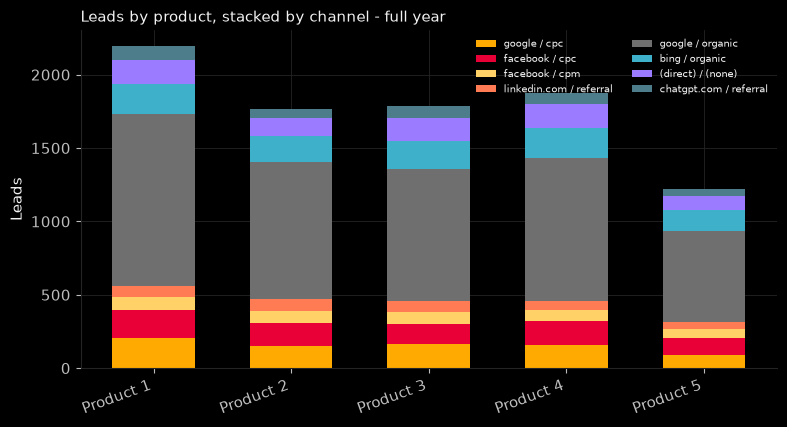

lead_product,google / cpc,facebook / cpc,facebook / cpm,linkedin.com / referral,google / organic,bing / organic,(direct) / (none),chatgpt.com / referral
Product 1,206,187,89,81,1170,206,159,97
Product 2,151,154,85,79,936,175,123,62
Product 3,162,139,83,74,898,195,152,81
Product 4,159,160,74,67,974,205,159,78
Product 5,90,113,64,47,624,141,96,46


**Finding.** **Product 1** is the most concentrated product: **google / organic** alone accounts for **53%** of its leads. Full breakdown: Product 1 -> google / organic (53%); Product 2 -> google / organic (53%); Product 3 -> google / organic (50%); Product 4 -> google / organic (52%); Product 5 -> google / organic (51%).

In [59]:

fig, ax = plt.subplots(figsize=(8, 4.4))
t_prod_ch = stacked_bar(ax, "lead_product", "source_medium", channel_colors,
                        "Leads by product, stacked by channel - full year")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

show(t_prod_ch.reset_index(), "Leads by product x channel, full-year totals")
note(dominance_note(t_prod_ch, "product", "channel"), kind="finding")


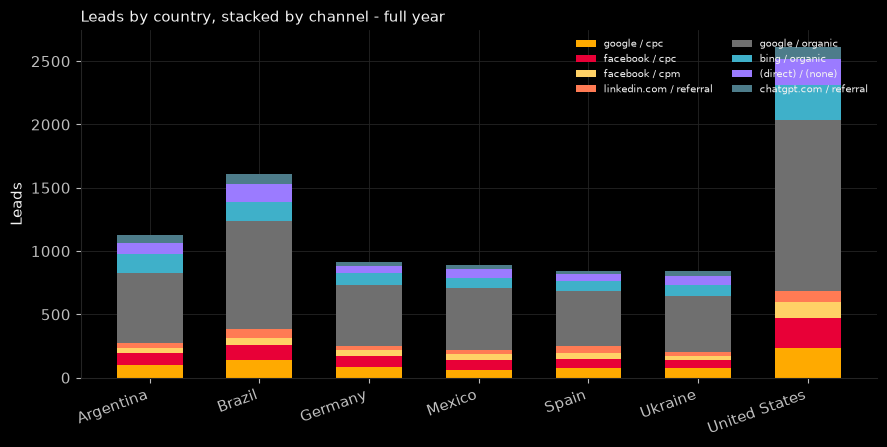

country,google / cpc,facebook / cpc,facebook / cpm,linkedin.com / referral,google / organic,bing / organic,(direct) / (none),chatgpt.com / referral
Argentina,98,94,43,41,554,148,89,59
Brazil,138,117,56,73,852,154,143,76
Germany,87,86,45,33,481,91,58,36
Mexico,61,81,44,29,492,82,71,28
Spain,79,69,50,50,434,84,51,28
Ukraine,73,67,33,33,437,91,69,37
United States,232,239,124,89,1352,272,208,100


**Finding.** **Mexico** is the most concentrated country: **google / organic** alone accounts for **55%** of its leads. Full breakdown: Argentina -> google / organic (49%); Brazil -> google / organic (53%); Germany -> google / organic (52%); Mexico -> google / organic (55%); Spain -> google / organic (51%); Ukraine -> google / organic (52%); United States -> google / organic (52%).

In [60]:

fig, ax = plt.subplots(figsize=(9, 4.6))
t_country_ch = stacked_bar(ax, "country", "source_medium", channel_colors,
                           "Leads by country, stacked by channel - full year")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

show(t_country_ch.reset_index(), "Leads by country x channel, full-year totals")
note(dominance_note(t_country_ch, "country", "channel"), kind="finding")


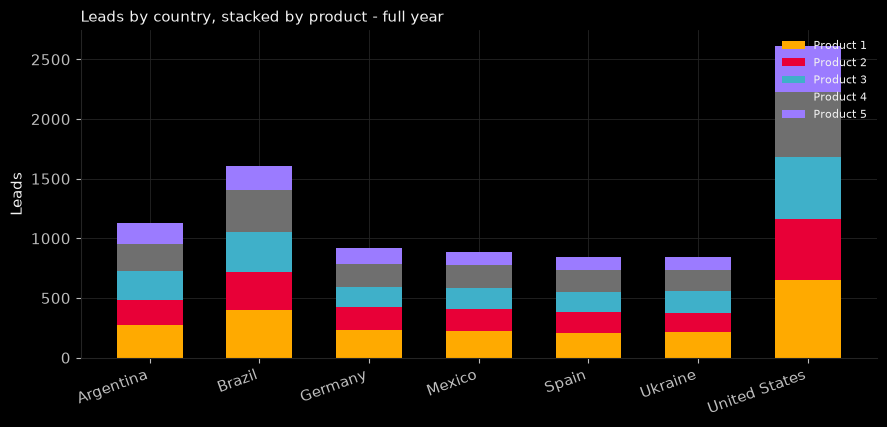

country,Product 1,Product 2,Product 3,Product 4,Product 5
Argentina,277,206,240,227,176
Brazil,397,320,339,351,202
Germany,229,197,164,199,128
Mexico,224,186,178,190,110
Spain,204,179,168,185,109
Ukraine,212,166,180,175,107
United States,652,511,515,549,389


**Finding.** **Ukraine** is the most concentrated country: **Product 1** alone accounts for **25%** of its leads. Full breakdown: Argentina -> Product 1 (25%); Brazil -> Product 1 (25%); Germany -> Product 1 (25%); Mexico -> Product 1 (25%); Spain -> Product 1 (24%); Ukraine -> Product 1 (25%); United States -> Product 1 (25%).

In [61]:

fig, ax = plt.subplots(figsize=(9, 4.4))
t_country_prod = stacked_bar(ax, "country", "lead_product", product_colors,
                             "Leads by country, stacked by product - full year")
ax.legend(fontsize=8, ncol=1, loc="upper right")
plt.tight_layout(); plt.show()

show(t_country_prod.reset_index(), "Leads by country x product, full-year totals")
note(dominance_note(t_country_prod, "country", "product"), kind="finding")


<a id="9"></a>
## 9. ROI / ROAS — channel, product, region

Revenue is attributed to the lead's **first-touch channel** and its **lead-month cohort** (Sections 3 and 8), so spend is always compared with the pipeline it actually bought.

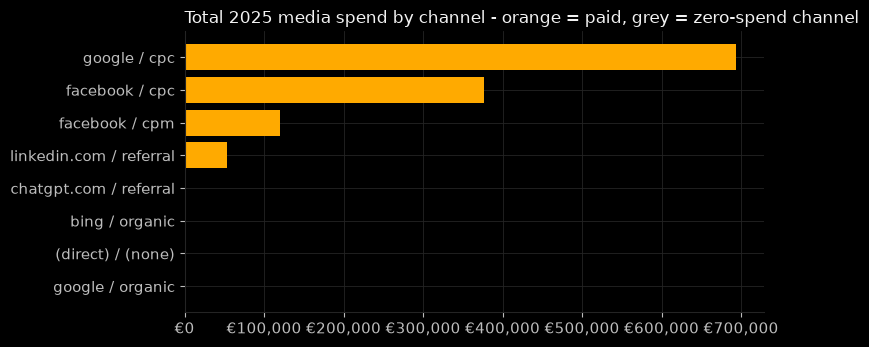

Session Source / Medium,"Spend, EUR"
google / cpc,694165.000000
facebook / cpc,377135.000000
facebook / cpm,119770.000000
linkedin.com / referral,52975.000000
chatgpt.com / referral,0.000000
bing / organic,0.000000
(direct) / (none),0.000000
google / organic,0.000000


In [62]:

spend_by_channel = (spend.groupby("Session Source / Medium")["spend_eur"].sum()
                    .rename("Spend, EUR").sort_values(ascending=False).reset_index())
colors_ch = [ORANGE if c in PAID else MUTED for c in spend_by_channel["Session Source / Medium"]]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(spend_by_channel["Session Source / Medium"][::-1], spend_by_channel["Spend, EUR"][::-1],
       color=colors_ch[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(eur))
ax.set_title("Total 2025 media spend by channel - orange = paid, grey = zero-spend channel",
             color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()
show(spend_by_channel, "Spend by channel, full year, sorted descending")


In [63]:

lead_side = work[work["is_lead_product"] == 1].groupby(
    ["lead_month", "source_medium", "Product", "region"]).size().rename("Leads")
stage_side = work.groupby(["lead_month", "source_medium", "Product", "region"]).agg(
    MQL=("is_mql", "sum"), SAL=("is_sal", "sum"), Signed=("is_signed", "sum"), Revenue=("deal_value_eur", "sum"))
spend_full = spend.set_index(grid_cols)["spend_eur"].reindex(full_grid).fillna(0.0).rename("spend_eur").reset_index()
gridf = spend_full.rename(columns={"Month": "lead_month", "Session Source / Medium": "source_medium",
                                   "Region": "region"}).set_index(["lead_month", "source_medium", "Product", "region"])
gridf = gridf.join(lead_side, how="outer").join(stage_side, how="outer")
gridf[["Leads", "MQL", "SAL", "Signed"]] = gridf[["Leads", "MQL", "SAL", "Signed"]].fillna(0).astype(int)
gridf[["spend_eur", "Revenue"]] = gridf[["spend_eur", "Revenue"]].fillna(0.0)
gridf = gridf.reset_index().rename(columns={"spend_eur": "Spend, EUR", "Revenue": "Revenue, EUR"})
assert gridf["Signed"].sum() == len(signed_raw)


def roi_by(dims, source=None):
    g = gridf if source is None else gridf[gridf["source_medium"].isin(source)]
    t = g.groupby(dims).agg({"Leads": "sum", "MQL": "sum", "SAL": "sum", "Signed": "sum",
                             "Spend, EUR": "sum", "Revenue, EUR": "sum"}).reset_index()
    t["CPL, EUR"] = safe_div(t["Spend, EUR"], t["Leads"]).round(1)
    t["CAC, EUR"] = safe_div(t["Spend, EUR"], t["Signed"]).round(0)
    t["Lead->Signed %"] = (safe_div(t["Signed"], t["Leads"]) * 100).round(2)
    t["ROAS"] = safe_div(t["Revenue, EUR"], t["Spend, EUR"]).round(2)
    return t.sort_values("Revenue, EUR", ascending=False)


unpaid = [c for c in gridf["source_medium"].unique() if c not in PAID]
roi_paid = roi_by(["source_medium"], PAID)
roi_unpaid = roi_by(["source_medium"], unpaid)

blended_revenue = gridf["Revenue, EUR"].sum()
blended_spend = gridf["Spend, EUR"].sum()
paid_revenue = roi_paid["Revenue, EUR"].sum()
paid_spend = roi_paid["Spend, EUR"].sum()
paid_leads_share = roi_paid["Leads"].sum() / gridf["Leads"].sum()

note(f"Blended ROAS is **{blended_revenue/blended_spend:.2f}** - all revenue over all spend. But paid "
     f"channels carry 100% of the media cost (unpaid channels spend €0 by definition) while generating "
     f"only {paid_leads_share*100:.0f}% of leads and {paid_revenue/blended_revenue*100:.0f}% of revenue. "
     f"Split the two: paid-only ROAS is **{paid_revenue/paid_spend:.2f}**, unpaid channels return "
     "revenue at zero media cost. The blended figure hides a loss-making paid budget behind a healthy "
     "organic one.", kind="risk")


**Risk.** Blended ROAS is **2.05** - all revenue over all spend. But paid channels carry 100% of the media cost (unpaid channels spend €0 by definition) while generating only 26% of leads and 21% of revenue. Split the two: paid-only ROAS is **0.42**, unpaid channels return revenue at zero media cost. The blended figure hides a loss-making paid budget behind a healthy organic one.

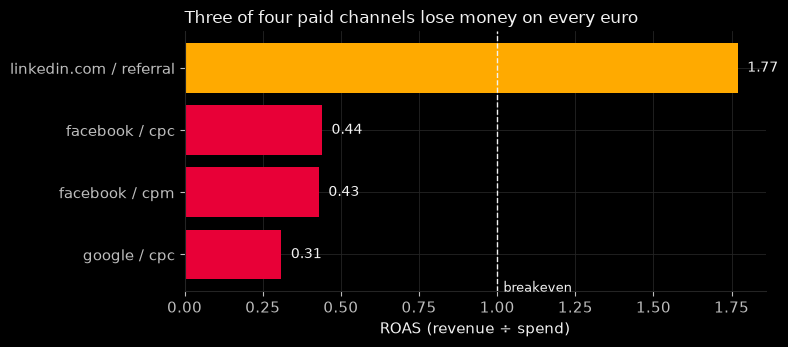

source_medium,Leads,MQL,SAL,Signed,"CPL, EUR","CAC, EUR",Lead->Signed %,"Spend, EUR","Revenue, EUR",ROAS
google / cpc,768,336,60,9,903.900000,77129.000000,1.170000,694165.000000,214400.000000,0.310000
facebook / cpc,753,346,62,8,500.800000,47142.000000,1.060000,377135.000000,167700.000000,0.440000
linkedin.com / referral,348,157,27,4,152.200000,13244.000000,1.150000,52975.000000,93800.000000,1.770000
facebook / cpm,395,179,30,2,303.200000,59885.000000,0.510000,119770.000000,51100.000000,0.430000


**Note.** CAC (Spend / Signed) restates the same CPL problem in the unit a budget call actually needs: the average Signed deal is worth €22,947, and **3 of 4** paid channels (google / cpc, facebook / cpc, facebook / cpm) cost more than that to acquire one signed customer - each one is a channel where, on average, the single deal doesn't cover its own acquisition cost even before any other overhead.

In [64]:

plot_df = roi_paid.sort_values("ROAS")
colors = [RED if r < 1 else ORANGE for r in plot_df["ROAS"]]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(plot_df["source_medium"], plot_df["ROAS"], color=colors)
ax.axvline(1.0, color=INK, linestyle="--", linewidth=1)
ax.text(1.02, -0.6, "breakeven", color=INK, fontsize=9)
for b, v in zip(bars, plot_df["ROAS"]):
    ax.text(v + 0.03, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center", color=INK, fontsize=10)
ax.set_xlabel("ROAS (revenue ÷ spend)")
ax.set_title("Three of four paid channels lose money on every euro", color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()

show(roi_paid[["source_medium", "Leads", "MQL", "SAL", "Signed", "CPL, EUR", "CAC, EUR", "Lead->Signed %",
              "Spend, EUR", "Revenue, EUR", "ROAS"]], "Paid channels - full economics", highlight_col="ROAS")

avg_deal = signed_raw["Deal Value, EUR"].mean()
over_avg_deal = roi_paid[roi_paid["CAC, EUR"] > avg_deal]
note(f"CAC (Spend / Signed) restates the same CPL problem in the unit a budget call actually needs: the "
     f"average Signed deal is worth €{avg_deal:,.0f}, and **{len(over_avg_deal)} of {len(roi_paid)}** paid "
     f"channels ({', '.join(over_avg_deal['source_medium'])}) cost more than that to acquire one signed "
     "customer - each one is a channel where, on average, the single deal doesn't cover its own acquisition "
     "cost even before any other overhead.", kind="info")


In [65]:

show(roi_unpaid[["source_medium", "Leads", "Signed", "Lead->Signed %", "Revenue, EUR"]],
     "Unpaid channels (zero spend - ROAS undefined, not infinite)", highlight_col="Revenue, EUR")

organic_share = roi_unpaid.loc[roi_unpaid["source_medium"] == "google / organic", "Revenue, EUR"].sum() / blended_revenue
note(f"google / organic alone produces **{organic_share*100:.0f}%** of all revenue and converts better "
     "than its paid equivalent (google / cpc) - yet receives no attributed budget at all.")


source_medium,Leads,Signed,Lead->Signed %,"Revenue, EUR"
google / organic,4602,69,1.500000,1585100.000000
(direct) / (none),689,8,1.160000,187900.000000
bing / organic,922,8,0.870000,181100.000000
chatgpt.com / referral,364,3,0.820000,66000.000000


**Finding.** google / organic alone produces **62%** of all revenue and converts better than its paid equivalent (google / cpc) - yet receives no attributed budget at all.

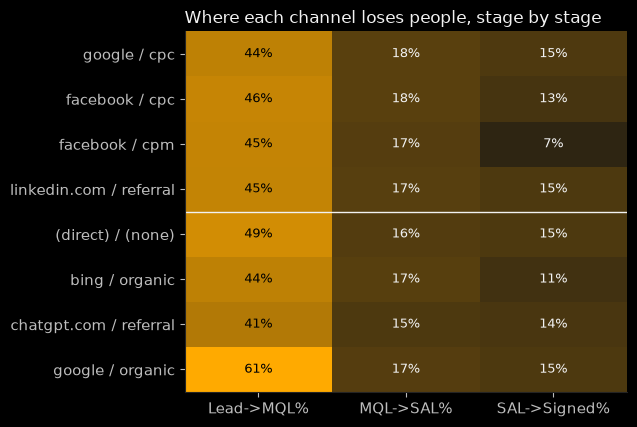

source_medium,Leads,MQL,SAL,Signed,Lead->MQL%,MQL->SAL%,SAL->Signed%
facebook / cpc,753,346,62,8,45.900000,17.900000,12.900000
facebook / cpm,395,179,30,2,45.300000,16.800000,6.700000
google / cpc,768,336,60,9,43.800000,17.900000,15.000000
linkedin.com / referral,348,157,27,4,45.100000,17.200000,14.800000
(direct) / (none),689,336,54,8,48.800000,16.100000,14.800000
bing / organic,922,404,70,8,43.800000,17.300000,11.400000
chatgpt.com / referral,364,149,22,3,40.900000,14.800000,13.600000
google / organic,4602,2787,464,69,60.600000,16.600000,14.900000


In [66]:

# Stage-by-stage conversion, every channel: identifies WHERE each channel loses people, not just
# whether it does.
stage_ch = work.groupby("source_medium").agg(
    Leads=("is_lead_product", "sum"), MQL=("is_mql", "sum"), SAL=("is_sal", "sum"), Signed=("is_signed", "sum")
).reset_index()
stage_ch["Lead->MQL%"] = (stage_ch["MQL"] / stage_ch["Leads"] * 100).round(1)
stage_ch["MQL->SAL%"] = (stage_ch["SAL"] / stage_ch["MQL"] * 100).round(1)
stage_ch["SAL->Signed%"] = (stage_ch["Signed"] / stage_ch["SAL"] * 100).round(1)
stage_ch["Paid"] = stage_ch["source_medium"].isin(PAID)

hm = stage_ch.set_index("source_medium")[["Lead->MQL%", "MQL->SAL%", "SAL->Signed%"]]
hm = hm.reindex(PAID + [c for c in hm.index if c not in PAID])

fig, ax = plt.subplots(figsize=(6.5, 4.4))
im = ax.imshow(hm.values, cmap=CMAP, aspect="auto", vmin=0, vmax=hm.values.max())
ax.set_xticks(range(3)); ax.set_xticklabels(hm.columns)
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        txt_color = BG if v > hm.values.max() * 0.55 else INK
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color=txt_color, fontsize=9)
ax.axhline(len(PAID) - 0.5, color=INK, linewidth=1)
ax.set_title("Where each channel loses people, stage by stage", color=INK, fontsize=12, loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

show(stage_ch.sort_values("Paid", ascending=False)[
    ["source_medium", "Leads", "MQL", "SAL", "Signed", "Lead->MQL%", "MQL->SAL%", "SAL->Signed%"]],
    "Stage-by-stage conversion, every channel")


In [67]:

pivot_ch_prod = pd.pivot_table(work[work["is_lead_product"] == 1], index="source_medium",
                               columns="Product", values="ID", aggfunc="count", fill_value=0)
show(pivot_ch_prod.reset_index(), "Leads by source channel × product")


source_medium,Product 1,Product 2,Product 3,Product 4,Product 5
(direct) / (none),159,123,152,159,96
bing / organic,206,175,195,205,141
chatgpt.com / referral,97,62,81,78,46
facebook / cpc,187,154,139,160,113
facebook / cpm,89,85,83,74,64
google / cpc,206,151,162,159,90
google / organic,1170,936,898,974,624
linkedin.com / referral,81,79,74,67,47


In [68]:

prod_region = work[work["is_signed"] == 1].pivot_table(
    index="Product", columns="region", values="deal_value_eur", aggfunc="sum", fill_value=0)
show(prod_region.reset_index(), "Signed revenue: Product (bought) × Region - SKU view, see the note below")


Product,Europe,LatAm,US
Product 1,534000.000000,638900.000000,456400.000000
Product 2,50700.000000,110800.000000,70300.000000
Product 3,40600.000000,77000.000000,86400.000000
Product 4,18200.000000,43900.000000,51400.000000
Product 5,133000.000000,171500.000000,64000.000000


In [69]:

top_brands = signed_raw.sort_values("Deal Value, EUR", ascending=False).head(15)[
    ["Brand Name", "Product", "Month", "Deal Value, EUR"]]
show(top_brands, "Top 15 signed deals by value")
note("Brand Name isn't a stable per-account identifier (Section 4), so this ranks individual deals, not "
     "long-term customers.", kind="info")


Brand Name,Product,Month,"Deal Value, EUR"
AOP,Product 1,3,38500
AAC,Product 1,3,38200
AAB,Product 1,3,37900
AKLS,Product 5,4,37300
ASB,Product 1,7,36500
APO,Product 1,3,36300
AJO,Product 1,2,35900
AP,Product 5,3,35800
ATY,Product 1,5,35300
ANM,Product 5,9,35100


**Note.** Brand Name isn't a stable per-account identifier (Section 4), so this ranks individual deals, not long-term customers.

### Product ROI, two ways - which product a lead *bought* vs. which product they *arrived on*

Does this cross-sold-revenue problem affect any grouping besides Product? No - checked, not assumed. **Channel-level ROI is unaffected**: channel is a lead attribute (first touch, Section 3), constant across every product-row that lead has, so summing revenue over all of a channel's rows - regardless of which product each row is - already nets out correctly; the channel totals used throughout this notebook are the same either way. **Region-level ROI is unaffected for the same reason** - region comes from the lead, not the stage. **Only Product-level views are affected**, because Product is the one dimension in `gridf` that switches between "the lead's own attribute" (for the Leads count) and "whatever stage this row represents" (for MQL/SAL/Signed/Revenue). The Product × Region pivot just above carries the same caveat as View 1 below - it is a SKU-by-region view, not spend-matched.

31 of 111 signed deals (28% of revenue, €716,500) close on a **different** product than the one the lead arrived on - `work`'s (Lead ID × Product) grain already keeps every one of them (Section 6), but grouping them under the product that was *bought* silently detaches that revenue from the media spend that actually paid to acquire the lead (Spend is booked against the *arrival* product, same as CPL always has been). Shown both ways below, not collapsed into one - they answer different questions.

In [70]:

# View 1 - "what did each product sell" (SKU performance). Revenue grouped by the product
# each stage actually happened on - a lead who arrives on Product 1 and buys Product 4 counts
# here as Product 4 revenue.
roi_product = roi_by(["Product"])
roi_product_paid = roi_by(["Product"], PAID)
prod = roi_product.merge(roi_product_paid[["Product", "Spend, EUR", "Revenue, EUR"]],
                         on="Product", suffixes=("", " (paid)"))
prod["Blended ROAS"] = safe_div(prod["Revenue, EUR"], prod["Spend, EUR (paid)"]).round(2)
prod["Paid-only ROAS"] = safe_div(prod["Revenue, EUR (paid)"], prod["Spend, EUR (paid)"]).round(2)
show(prod[["Product", "Leads", "Signed", "Lead->Signed %", "Revenue, EUR",
          "Blended ROAS", "Paid-only ROAS"]].sort_values("Revenue, EUR", ascending=False),
     "View 1 - SKU performance: revenue by product BOUGHT", highlight_col="Blended ROAS")


Product,Leads,Signed,Lead->Signed %,"Revenue, EUR",Blended ROAS,Paid-only ROAS
Product 1,2195,55,2.510000,1629300.000000,5.040000,1.080000
Product 5,1221,11,0.900000,368500.000000,2.250000,0.440000
Product 2,1765,16,0.910000,231800.000000,0.910000,0.150000
Product 3,1784,19,1.070000,204000.000000,0.810000,0.220000
Product 4,1876,10,0.530000,113500.000000,0.450000,0.050000


In [71]:

# View 2 - "was the media spend on each product worth it" (budget decisions). Same lead-level
# facts, but MQL/SAL/Signed/Revenue rolled up under lead_product - the product campaign that
# was actually paid for - exactly the same first-touch logic already used for channel and
# region, just applied to product too.
lead_side_arr = work[work["is_lead_product"] == 1].groupby(
    ["lead_month", "source_medium", "lead_product", "region"]).size().rename("Leads")
stage_side_arr = work.groupby(["lead_month", "source_medium", "lead_product", "region"]).agg(
    MQL=("is_mql", "sum"), SAL=("is_sal", "sum"), Signed=("is_signed", "sum"), Revenue=("deal_value_eur", "sum"))
gridf_arrival = spend_full.rename(columns={"Month": "lead_month", "Session Source / Medium": "source_medium",
                                           "Product": "lead_product", "Region": "region"}).set_index(
    ["lead_month", "source_medium", "lead_product", "region"])
gridf_arrival = gridf_arrival.join(lead_side_arr, how="outer").join(stage_side_arr, how="outer")
gridf_arrival[["Leads", "MQL", "SAL", "Signed"]] = gridf_arrival[["Leads", "MQL", "SAL", "Signed"]].fillna(0).astype(int)
gridf_arrival[["spend_eur", "Revenue"]] = gridf_arrival[["spend_eur", "Revenue"]].fillna(0.0)
gridf_arrival = gridf_arrival.reset_index().rename(columns={"spend_eur": "Spend, EUR", "Revenue": "Revenue, EUR"})
assert gridf_arrival["Signed"].sum() == len(signed_raw)


def roi_by_arrival(dims, source=None):
    g = gridf_arrival if source is None else gridf_arrival[gridf_arrival["source_medium"].isin(source)]
    t = g.groupby(dims).agg({"Leads": "sum", "MQL": "sum", "SAL": "sum", "Signed": "sum",
                             "Spend, EUR": "sum", "Revenue, EUR": "sum"}).reset_index()
    t["Lead->Signed %"] = (safe_div(t["Signed"], t["Leads"]) * 100).round(2)
    t["ROAS"] = safe_div(t["Revenue, EUR"], t["Spend, EUR"]).round(2)
    return t.sort_values("Revenue, EUR", ascending=False)


prod_arr = roi_by_arrival(["lead_product"]).rename(columns={"lead_product": "Product"})
prod_arr_paid = roi_by_arrival(["lead_product"], PAID).rename(columns={"lead_product": "Product"})
prod2 = prod_arr.merge(prod_arr_paid[["Product", "Spend, EUR", "Revenue, EUR"]],
                       on="Product", suffixes=("", " (paid)"))
prod2["Blended ROAS"] = safe_div(prod2["Revenue, EUR"], prod2["Spend, EUR (paid)"]).round(2)
prod2["Paid-only ROAS"] = safe_div(prod2["Revenue, EUR (paid)"], prod2["Spend, EUR (paid)"]).round(2)
show(prod2[["Product", "Leads", "Signed", "Lead->Signed %", "Revenue, EUR",
           "Blended ROAS", "Paid-only ROAS"]].sort_values("Revenue, EUR", ascending=False),
     "View 2 - spend-matched: revenue by product ARRIVED ON", highlight_col="Blended ROAS")


Product,Leads,Signed,Lead->Signed %,"Revenue, EUR",Blended ROAS,Paid-only ROAS
Product 1,2195,50,2.280000,1397500.000000,4.320000,1.040000
Product 3,1784,22,1.230000,356300.000000,1.420000,0.290000
Product 2,1765,18,1.020000,306200.000000,1.210000,0.140000
Product 5,1221,10,0.820000,301800.000000,1.850000,0.210000
Product 4,1876,11,0.590000,185300.000000,0.730000,0.200000


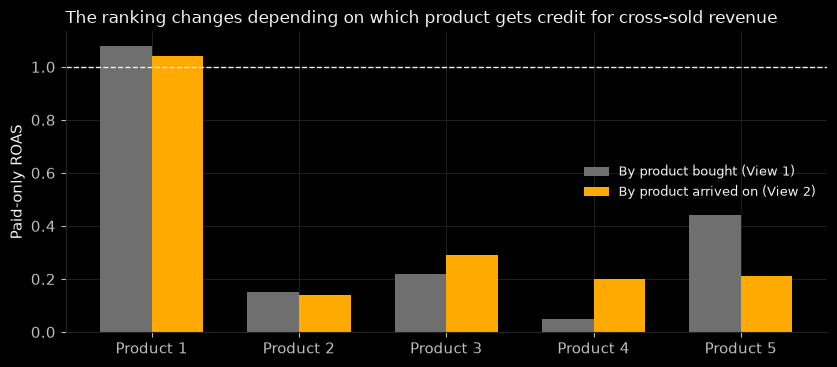

**Finding.** 
Ranking by product bought: Product 1 > Product 5 > Product 3 > Product 2 > Product 4. Ranking by product arrived on (spend-matched):
Product 1 > Product 3 > Product 5 > Product 4 > Product 2. **Product 1 leads either way** - its own paid-only ROAS barely moves
(1.08 → 1.04). But **Product 4 and Product 5 swap places**:
Product 4 looked like the clear worst performer (0.05) under View 1 largely because its acquired leads'
revenue got counted under whichever product they cross-sold into; credited back to its own spend (View 2)
it is a mid-table 0.20 - roughly 4x better than it looked. Product 5 moves the other way, from second-best
(0.44) to near-bottom (0.21). **For budget decisions, View 2 is the one to act on** - it is the only one
where spend and revenue are matched to the same product, the same first-touch logic already used for
channel and region. View 1 stays useful for a different question: which SKU actually sells.


In [72]:

x = np.arange(5); w = 0.35
order = ["Product 1", "Product 2", "Product 3", "Product 4", "Product 5"]
bought = prod.set_index("Product").loc[order, "Paid-only ROAS"]
arrived = prod2.set_index("Product").loc[order, "Paid-only ROAS"]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.bar(x - w/2, bought, w, color=MUTED, label="By product bought (View 1)")
ax.bar(x + w/2, arrived, w, color=ORANGE, label="By product arrived on (View 2)")
ax.axhline(1.0, color=INK, linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("Paid-only ROAS")
ax.set_title("The ranking changes depending on which product gets credit for cross-sold revenue",
             color=INK, fontsize=12, loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

rank_bought = bought.sort_values(ascending=False).index.tolist()
rank_arrived = arrived.sort_values(ascending=False).index.tolist()
note(f'''
Ranking by product bought: {" > ".join(rank_bought)}. Ranking by product arrived on (spend-matched):
{" > ".join(rank_arrived)}. **Product 1 leads either way** - its own paid-only ROAS barely moves
({bought['Product 1']:.2f} → {arrived['Product 1']:.2f}). But **Product 4 and Product 5 swap places**:
Product 4 looked like the clear worst performer (0.05) under View 1 largely because its acquired leads'
revenue got counted under whichever product they cross-sold into; credited back to its own spend (View 2)
it is a mid-table 0.20 - roughly 4x better than it looked. Product 5 moves the other way, from second-best
(0.44) to near-bottom (0.21). **For budget decisions, View 2 is the one to act on** - it is the only one
where spend and revenue are matched to the same product, the same first-touch logic already used for
channel and region. View 1 stays useful for a different question: which SKU actually sells.
''', kind="finding")


### Full cross-tab: which product did they come for, and which did they actually buy?

Every signed deal, all channels combined - not ROAS, just the raw flow. Rows are the product a lead arrived on (the one they searched for / clicked into / landed on); columns are the product they actually signed for. The diagonal is "bought what they came for"; everything off it is a real cross-sell, kept in this notebook's (Lead ID × Product) grain rather than collapsed away (Section 6) - so a lead who arrived hunting for Product 4 and ended up buying Product 5 shows up exactly there.

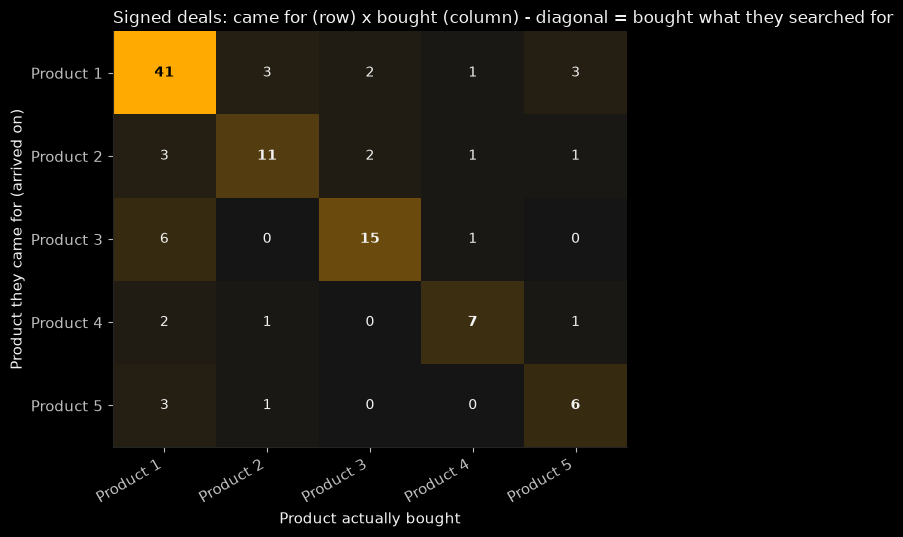

Came for \ Bought,Product 1,Product 2,Product 3,Product 4,Product 5
Product 1,41,3,2,1,3
Product 2,3,11,2,1,1
Product 3,6,0,15,1,0
Product 4,2,1,0,7,1
Product 5,3,1,0,0,6


**Finding.** **80 of 111** signed deals (72%) buy exactly the product they came for. Of the cross-sells, the single biggest flow is **Product 3 -> Product 1** (6 deals) - a lead searching for Product 3 ending up signing for Product 1. This is the same 31-of-111 cross-sell fact Section 9 already counted in aggregate - shown here as the full flow so a specific pattern (e.g. one product quietly feeding another) is visible directly instead of inferred from a single percentage.

In [73]:

products_order = ["Product 1", "Product 2", "Product 3", "Product 4", "Product 5"]
signed_flow = (work[work["is_signed"] == 1].groupby(["lead_product", "Product"]).size()
              .unstack(fill_value=0).reindex(index=products_order, columns=products_order, fill_value=0))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(signed_flow.values, cmap=CMAP, aspect="auto")
ax.set_xticks(range(len(products_order))); ax.set_xticklabels(products_order, rotation=30, ha="right")
ax.set_yticks(range(len(products_order))); ax.set_yticklabels(products_order)
ax.set_xlabel("Product actually bought"); ax.set_ylabel("Product they came for (arrived on)")
vmax = signed_flow.values.max()
for i in range(len(products_order)):
    for j in range(len(products_order)):
        v = signed_flow.iloc[i, j]
        color = BG if v > vmax * 0.5 else INK
        weight = "bold" if i == j else "normal"
        ax.text(j, i, str(int(v)), ha="center", va="center", color=color, fontsize=10, fontweight=weight)
ax.set_title("Signed deals: came for (row) x bought (column) - diagonal = bought what they searched for",
             color=INK, fontsize=12, loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

show(signed_flow.reset_index().rename(columns={"lead_product": "Came for \\ Bought"}),
     "Full came-for x bought-instead matrix, signed deals, all channels")

total_signed = int(signed_flow.values.sum())
same = int(np.trace(signed_flow.values))
off_vals = signed_flow.to_numpy(copy=True)
np.fill_diagonal(off_vals, 0)
off = pd.DataFrame(off_vals, index=signed_flow.index, columns=signed_flow.columns)
top_flow = off.stack().idxmax()
top_flow_n = int(off.stack().max())
note(f"**{same} of {total_signed}** signed deals ({same/total_signed*100:.0f}%) buy exactly the product "
     f"they came for. Of the cross-sells, the single biggest flow is **{top_flow[0]} -> {top_flow[1]}** "
     f"({top_flow_n} deals) - a lead searching for {top_flow[0]} ending up signing for {top_flow[1]}. "
     "This is the same 31-of-111 cross-sell fact Section 9 already counted in aggregate - shown here as "
     "the full flow so a specific pattern (e.g. one product quietly feeding another) is visible directly "
     "instead of inferred from a single percentage.", kind="finding")


### ROAS, faceted: one small chart per product, per region

Same View 2 (spend-matched) numbers as above, split into small multiples instead of one aggregate bar per group - so a channel or product that only looks bad blended can be seen recovering (or getting worse) in a specific slice. **Region, not country**: Spend only exists at (Month, Channel, Product, **Region**) grain (Section 5) - there is no per-country spend in this dataset, so a country-level ROAS would have to invent a cost split that isn't there. Region (US / LatAm / Europe) is as granular as ROAS can honestly get.

In [74]:

REGIONS = ["US", "LatAm", "Europe"]
PRODUCTS = ["Product 1", "Product 2", "Product 3", "Product 4", "Product 5"]


def paid_roas_table(dims):
    t = (gridf_arrival[gridf_arrival["source_medium"].isin(PAID)].groupby(dims)
        .agg(**{"Spend, EUR": ("Spend, EUR", "sum"), "Revenue, EUR": ("Revenue, EUR", "sum")}).reset_index())
    t["ROAS"] = safe_div(t["Revenue, EUR"], t["Spend, EUR"])
    return t


def facet_roas_bars(table, facet_col, facet_values, bar_col, bar_values, title, xlabel_fmt=lambda c: c):
    fig, axes = plt.subplots(1, len(facet_values), figsize=(3.1 * len(facet_values), 3.6), sharey=True)
    if len(facet_values) == 1:
        axes = [axes]
    for ax, fv in zip(axes, facet_values):
        d = table[table[facet_col] == fv].set_index(bar_col).reindex(bar_values)
        vals = d["ROAS"].fillna(0)
        colors = [ORANGE if v >= 1 else RED for v in vals]
        ax.bar(range(len(bar_values)), vals, color=colors)
        for i, v in enumerate(d["ROAS"]):
            if pd.notna(v):
                ax.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", color=INK, fontsize=7)
        ax.axhline(1.0, color=INK, linestyle="--", linewidth=1)
        ax.set_xticks(range(len(bar_values)))
        ax.set_xticklabels([xlabel_fmt(c) for c in bar_values], rotation=45, ha="right", fontsize=7)
        ax.set_title(fv, color=INK, fontsize=10, loc="left")
    axes[0].set_ylabel("ROAS (paid, spend-matched)")
    plt.suptitle(title, color=INK, fontsize=12, x=0.01, ha="left")
    plt.tight_layout(); plt.show()


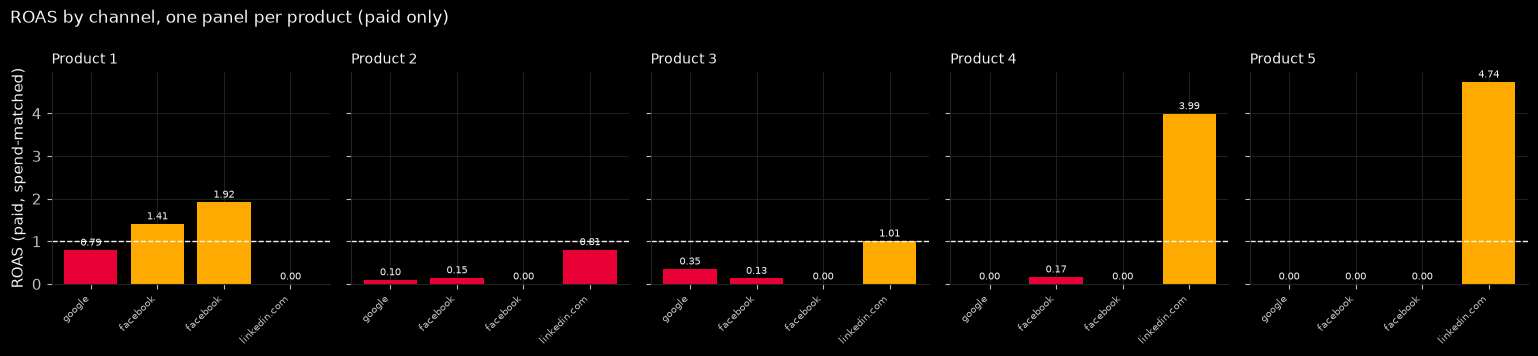

lead_product,facebook / cpc,facebook / cpm,google / cpc,linkedin.com / referral
Product 1,1.410000,1.920000,0.790000,0.000000
Product 2,0.150000,0.000000,0.100000,0.810000
Product 3,0.130000,0.000000,0.350000,1.010000
Product 4,0.170000,0.000000,0.000000,3.990000
Product 5,0.000000,0.000000,0.000000,4.740000


**Finding.** Best-performing paid channel per product: Product 1 -> facebook / cpm (1.92); Product 2 -> linkedin.com / referral (0.81); Product 3 -> linkedin.com / referral (1.01); Product 4 -> linkedin.com / referral (3.99); Product 5 -> linkedin.com / referral (4.74). Worst: Product 1 -> linkedin.com / referral (0.00); Product 2 -> facebook / cpm (0.00); Product 3 -> facebook / cpm (0.00); Product 4 -> facebook / cpm (0.00); Product 5 -> facebook / cpc (0.00). No single channel is uniformly best or worst across every product - the ranking in Section 9's aggregate view hides this product-by-product variation.

In [75]:

prod_ch = paid_roas_table(["lead_product", "source_medium"])
facet_roas_bars(prod_ch, "lead_product", PRODUCTS, "source_medium", PAID,
               "ROAS by channel, one panel per product (paid only)", lambda c: c.split(" /")[0])

pivot_prod_ch = prod_ch.pivot(index="lead_product", columns="source_medium", values="ROAS").round(2).reindex(PRODUCTS)
show(pivot_prod_ch.reset_index(), "ROAS by product x channel, paid only (blank = no spend in that cell)")

best_ch_per_prod = pivot_prod_ch.idxmax(axis=1)
worst_ch_per_prod = pivot_prod_ch.idxmin(axis=1)
note("Best-performing paid channel per product: "
     + "; ".join(f"{p} -> {best_ch_per_prod[p]} ({pivot_prod_ch.loc[p, best_ch_per_prod[p]]:.2f})" for p in PRODUCTS)
     + ". Worst: "
     + "; ".join(f"{p} -> {worst_ch_per_prod[p]} ({pivot_prod_ch.loc[p, worst_ch_per_prod[p]]:.2f})" for p in PRODUCTS)
     + ". No single channel is uniformly best or worst across every product - the ranking in Section 9's "
     "aggregate view hides this product-by-product variation.", kind="finding")


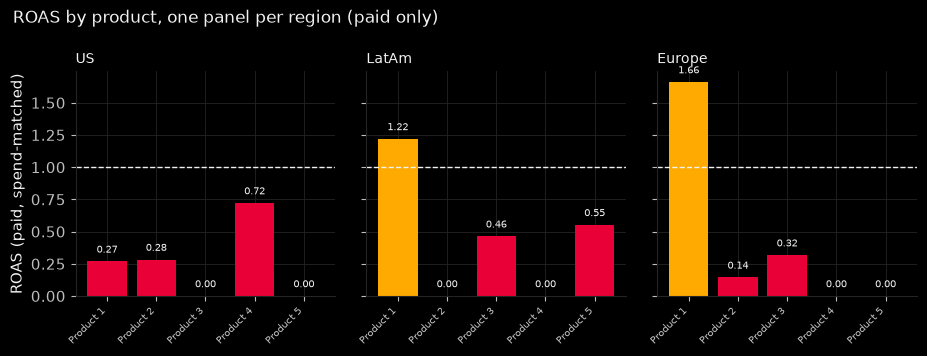

region,Product 1,Product 2,Product 3,Product 4,Product 5
US,0.270000,0.280000,0.000000,0.720000,0.000000
LatAm,1.220000,0.000000,0.460000,0.000000,0.550000
Europe,1.660000,0.140000,0.320000,0.000000,0.000000


**Finding.** Best-performing product per region: US -> Product 4 (0.72); LatAm -> Product 1 (1.22); Europe -> Product 1 (1.66). Cell sizes here are small (Section 9/15) - read this as a starting point for a deeper look, not a final product-region budget call.

In [76]:

reg_prod = paid_roas_table(["region", "lead_product"])
facet_roas_bars(reg_prod, "region", REGIONS, "lead_product", PRODUCTS,
               "ROAS by product, one panel per region (paid only)")

pivot_reg_prod = reg_prod.pivot(index="region", columns="lead_product", values="ROAS").round(2).reindex(REGIONS)
show(pivot_reg_prod.reset_index(), "ROAS by region x product, paid only")

best_prod_per_region = pivot_reg_prod.idxmax(axis=1)
note("Best-performing product per region: "
     + "; ".join(f"{r} -> {best_prod_per_region[r]} ({pivot_reg_prod.loc[r, best_prod_per_region[r]]:.2f})" for r in REGIONS)
     + ". Cell sizes here are small (Section 9/15) - read this as a starting point for a deeper look, not "
     "a final product-region budget call.", kind="finding")


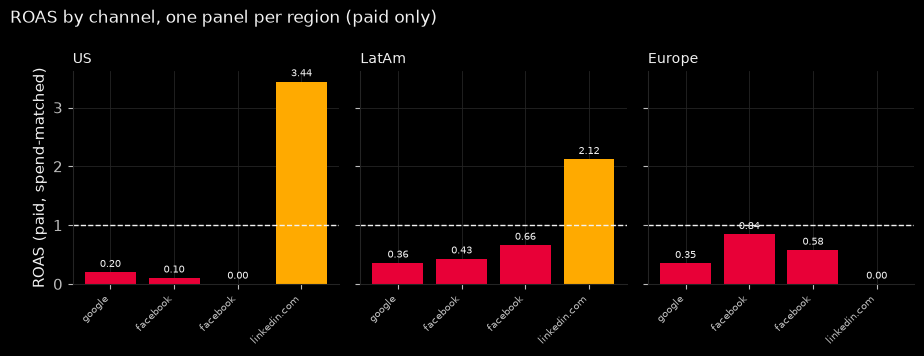

region,facebook / cpc,facebook / cpm,google / cpc,linkedin.com / referral
US,0.100000,0.000000,0.200000,3.440000
LatAm,0.430000,0.660000,0.360000,2.120000
Europe,0.840000,0.580000,0.350000,0.000000


**Finding.** Best-performing paid channel per region: US -> linkedin.com / referral (3.44); LatAm -> linkedin.com / referral (2.12); Europe -> facebook / cpc (0.84). Cross-check against 15.2's confounding note before treating any one region's channel ranking as settled - some of these cells rest on very few signed deals.

In [77]:

reg_ch = paid_roas_table(["region", "source_medium"])
facet_roas_bars(reg_ch, "region", REGIONS, "source_medium", PAID,
               "ROAS by channel, one panel per region (paid only)", lambda c: c.split(" /")[0])

pivot_reg_ch = reg_ch.pivot(index="region", columns="source_medium", values="ROAS").round(2).reindex(REGIONS)
show(pivot_reg_ch.reset_index(), "ROAS by region x channel, paid only")

best_ch_per_region = pivot_reg_ch.idxmax(axis=1)
note("Best-performing paid channel per region: "
     + "; ".join(f"{r} -> {best_ch_per_region[r]} ({pivot_reg_ch.loc[r, best_ch_per_region[r]]:.2f})" for r in REGIONS)
     + ". Cross-check against 15.2's confounding note before treating any one region's channel ranking as "
     "settled - some of these cells rest on very few signed deals.", kind="finding")


### US drill-down: product × channel

A named priority market gets its own explicit cut - paid ROAS by product and channel, restricted to US, with the number of signed deals behind each cell shown directly on the chart rather than left for the reader to go dig up.

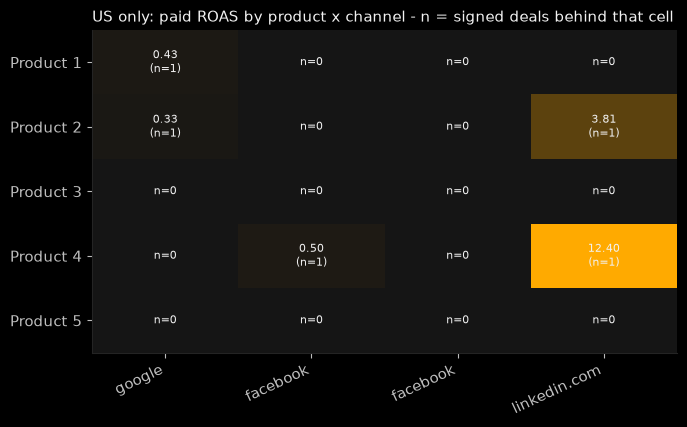

lead_product,source_medium,"Spend, EUR","Revenue, EUR",Signed,ROAS
Product 4,linkedin.com / referral,3105.000000,38500.000000,1,12.399356
Product 2,linkedin.com / referral,2495.000000,9500.000000,1,3.807615
Product 4,facebook / cpc,24995.000000,12600.000000,1,0.504101
Product 1,google / cpc,65770.000000,28200.000000,1,0.428767
Product 2,google / cpc,41715.000000,13600.000000,1,0.326022
Product 1,linkedin.com / referral,3300.000000,0.000000,0,0.000000
Product 1,facebook / cpc,29665.000000,0.000000,0,0.000000
Product 1,facebook / cpm,6325.000000,0.000000,0,0.000000
Product 3,facebook / cpc,18325.000000,0.000000,0,0.000000
Product 3,facebook / cpm,7805.000000,0.000000,0,0.000000


**Risk.** **Only 5 signed deals** are spread across these 20 (product, channel) cells in the US, and every non-zero cell has exactly n=1. A ROAS of 12x on one cell is one deal, not a pattern - this granularity genuinely cannot support a budget-reallocation decision yet, however good a single number looks. Read any cell here as 'worth a small, monitored test', never as 'proven, scale it up'.

In [78]:

us_grid = gridf_arrival[(gridf_arrival["region"] == "US") & (gridf_arrival["source_medium"].isin(PAID))].groupby(
    ["lead_product", "source_medium"]).agg(**{"Spend, EUR": ("Spend, EUR", "sum"),
                                              "Revenue, EUR": ("Revenue, EUR", "sum"),
                                              "Signed": ("Signed", "sum")}).reset_index()
us_grid["ROAS"] = safe_div(us_grid["Revenue, EUR"], us_grid["Spend, EUR"])

pivot_us_roas = us_grid.pivot(index="lead_product", columns="source_medium", values="ROAS").reindex(index=PRODUCTS, columns=PAID)
pivot_us_n = us_grid.pivot(index="lead_product", columns="source_medium", values="Signed").reindex(index=PRODUCTS, columns=PAID).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(7, 4.4))
im = ax.imshow(pivot_us_roas.fillna(0).values, cmap=CMAP, aspect="auto")
ax.set_xticks(range(len(PAID))); ax.set_xticklabels([c.split(" /")[0] for c in PAID], rotation=25, ha="right")
ax.set_yticks(range(len(PRODUCTS))); ax.set_yticklabels(PRODUCTS)
for i in range(len(PRODUCTS)):
    for j in range(len(PAID)):
        v, n = pivot_us_roas.iloc[i, j], pivot_us_n.iloc[i, j]
        txt = f"{v:.2f}\n(n={n})" if pd.notna(v) and n > 0 else "n=0"
        ax.text(j, i, txt, ha="center", va="center", color=INK, fontsize=8)
ax.set_title("US only: paid ROAS by product x channel - n = signed deals behind that cell",
             color=INK, fontsize=11, loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

show(us_grid.sort_values("ROAS", ascending=False), "US, paid channels: product x channel detail")

n_total_us_paid = int(us_grid["Signed"].sum())
note(f"**Only {n_total_us_paid} signed deals** are spread across these 20 (product, channel) cells in the "
     "US, and every non-zero cell has exactly n=1. A ROAS of 12x on one cell is one deal, not a pattern - "
     "this granularity genuinely cannot support a budget-reallocation decision yet, however good a single "
     "number looks. Read any cell here as 'worth a small, monitored test', never as 'proven, scale it "
     "up'.", kind="risk")


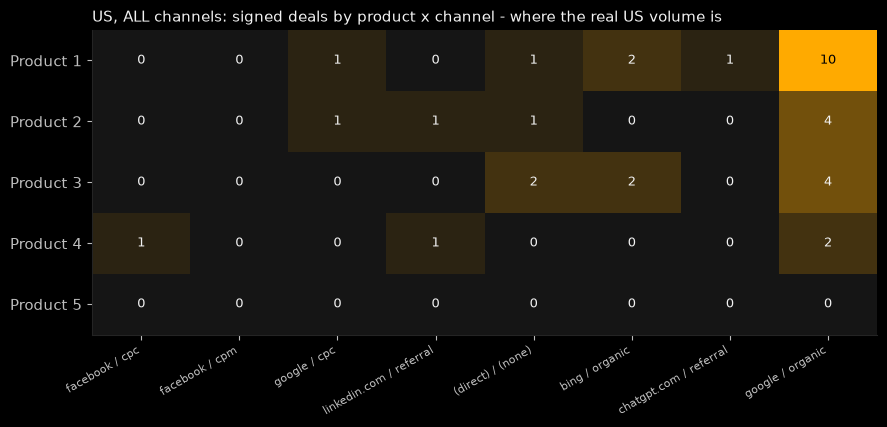

**Finding.** Zoom out to every channel and the US does have real volume - **34 signed deals** - but it is overwhelmingly `google / organic` x Product 1 (10 deals) and Product 1 generally (15 of 34). **Product 5 has zero signed deals in the US all year, on any channel** - that is either a real market-fit gap worth a conversation with sales, or simply no push behind it there yet; this dataset cannot tell which.

In [79]:

# Paid alone has almost no US volume - zoom out to every channel, since that is where the real US
# signed-deal volume actually is.
us_all_grid = (work[work["region"] == "US"].groupby(["lead_product", "source_medium"])["is_signed"]
              .sum().unstack(fill_value=0).reindex(index=PRODUCTS, columns=[c for c in channels]))
us_all_grid = us_all_grid[[c for c in us_all_grid.columns if us_all_grid[c].sum() > 0 or c in PAID]]

fig, ax = plt.subplots(figsize=(9, 4.4))
im = ax.imshow(us_all_grid.values, cmap=CMAP, aspect="auto")
ax.set_xticks(range(len(us_all_grid.columns))); ax.set_xticklabels(us_all_grid.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(PRODUCTS))); ax.set_yticklabels(PRODUCTS)
vmax = us_all_grid.values.max()
for i in range(len(PRODUCTS)):
    for j in range(len(us_all_grid.columns)):
        v = us_all_grid.iloc[i, j]
        ax.text(j, i, str(int(v)), ha="center", va="center",
               color=BG if v > vmax * 0.5 else INK, fontsize=9)
ax.set_title("US, ALL channels: signed deals by product x channel - where the real US volume is",
             color=INK, fontsize=11, loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

p1_total = int(us_all_grid.loc["Product 1"].sum())
p1_organic = int(us_all_grid.loc["Product 1", "google / organic"]) if "google / organic" in us_all_grid.columns else 0
p5_total = int(us_all_grid.loc["Product 5"].sum())
note(f"Zoom out to every channel and the US does have real volume - **{int(us_all_grid.values.sum())} "
     f"signed deals** - but it is overwhelmingly `google / organic` x Product 1 ({p1_organic} deals) and "
     f"Product 1 generally ({p1_total} of {int(us_all_grid.values.sum())}). **Product 5 has "
     f"{'zero' if p5_total == 0 else p5_total} signed deals in the US all year, on any channel** - that "
     "is either a real market-fit gap worth a conversation with sales, or simply no push behind it there "
     "yet; this dataset cannot tell which.", kind="finding")


### Turning this into a marketing action matrix - what is actually safe to act on now

A clean product×channel×region cut is exactly the moment to slow down and check the n behind each cell (Sections 15.1, 15.6) before recommending a budget move - not every good-looking number above is a decision yet. Tiered by how many signed deals actually back it, **across all regions** (the US-only slice above has too little paid volume on its own to tier).

In [80]:

combo = gridf_arrival[gridf_arrival["source_medium"].isin(PAID)].groupby(
    ["lead_product", "source_medium"]).agg(**{"Spend, EUR": ("Spend, EUR", "sum"),
                                              "Revenue, EUR": ("Revenue, EUR", "sum"),
                                              "Signed": ("Signed", "sum")}).reset_index()
combo["ROAS"] = safe_div(combo["Revenue, EUR"], combo["Spend, EUR"])
combo["Tier"] = np.select(
    [combo["Signed"] >= 5, combo["Signed"] >= 3],
    ["1 - enough deals to act on", "2 - borderline, watch closely"],
    default="3 - one or two deals, hypothesis only")
combo = combo.sort_values(["Tier", "ROAS"], ascending=[True, False])
show(combo[["lead_product", "source_medium", "Signed", "Spend, EUR", "Revenue, EUR", "ROAS", "Tier"]],
     "Product x channel (paid, all regions), tiered by signed-deal count behind each cell")

tier1 = combo[combo["Tier"].str.startswith("1")]
tier3_flashy = combo[(combo["Tier"].str.startswith("3")) & (combo["ROAS"] >= 2)]
note(f"**Tier 1 - {len(tier1)} cells actually have enough deals (n>=5) to act on:** "
     + "; ".join(f"{r['lead_product']} x {r['source_medium']} (n={int(r['Signed'])}, ROAS {r['ROAS']:.2f})"
                 for _, r in tier1.iterrows())
     + f". Only Product 1 has enough paid volume on two different channels to compare them directly - and "
     "on that basis, `facebook / cpc` clearly outperforms `facebook / cpm` and `google / cpc` for Product 1 "
     "specifically. **Everything else, including the flashiest numbers on the charts above** ("
     + "; ".join(f"{r['lead_product']} x {r['source_medium']} (ROAS {r['ROAS']:.2f}, n={int(r['Signed'])})"
                 for _, r in tier3_flashy.iterrows())
     + ") **is one or two deals - a real, useful hypothesis to test with a small, bounded budget increase "
     "and a tracked outcome, not something to reallocate serious budget to yet.** The honest marketing "
     "action from this notebook today is: shift budget toward Product 1 on `facebook / cpc` with "
     "confidence, and open small monitored tests on the Tier-3 combinations rather than a full "
     "reallocation - then revisit this exact table once more signed deals land in those thin cells.",
     kind="decision")


lead_product,source_medium,Signed,"Spend, EUR","Revenue, EUR",ROAS,Tier
Product 1,facebook / cpc,5,95385.000000,134500.000000,1.410075,1 - enough deals to act on
Product 1,google / cpc,5,188555.000000,149600.000000,0.793402,1 - enough deals to act on
Product 3,google / cpc,3,145335.000000,51200.000000,0.352290,"2 - borderline, watch closely"
Product 5,linkedin.com / referral,1,7200.000000,34100.000000,4.736111,"3 - one or two deals, hypothesis only"
Product 4,linkedin.com / referral,1,9640.000000,38500.000000,3.993776,"3 - one or two deals, hypothesis only"
Product 1,facebook / cpm,2,26630.000000,51100.000000,1.918888,"3 - one or two deals, hypothesis only"
Product 3,linkedin.com / referral,1,11620.000000,11700.000000,1.006885,"3 - one or two deals, hypothesis only"
Product 2,linkedin.com / referral,1,11790.000000,9500.000000,0.805768,"3 - one or two deals, hypothesis only"
Product 4,facebook / cpc,1,76245.000000,12600.000000,0.165257,"3 - one or two deals, hypothesis only"
Product 2,facebook / cpc,1,79050.000000,11500.000000,0.145478,"3 - one or two deals, hypothesis only"


**Decision.** **Tier 1 - 2 cells actually have enough deals (n>=5) to act on:** Product 1 x facebook / cpc (n=5, ROAS 1.41); Product 1 x google / cpc (n=5, ROAS 0.79). Only Product 1 has enough paid volume on two different channels to compare them directly - and on that basis, `facebook / cpc` clearly outperforms `facebook / cpm` and `google / cpc` for Product 1 specifically. **Everything else, including the flashiest numbers on the charts above** (Product 5 x linkedin.com / referral (ROAS 4.74, n=1); Product 4 x linkedin.com / referral (ROAS 3.99, n=1)) **is one or two deals - a real, useful hypothesis to test with a small, bounded budget increase and a tracked outcome, not something to reallocate serious budget to yet.** The honest marketing action from this notebook today is: shift budget toward Product 1 on `facebook / cpc` with confidence, and open small monitored tests on the Tier-3 combinations rather than a full reallocation - then revisit this exact table once more signed deals land in those thin cells.

### Revenue and gross profit by product, monthly

View 2 (spend-matched, above) is the one used here too, for the same reason: revenue and the spend that bought it are rolled up under the same product, so "profit" is not comparing two different things by accident. Gross profit = Revenue − Spend (Section 13's definition), by product, by month.

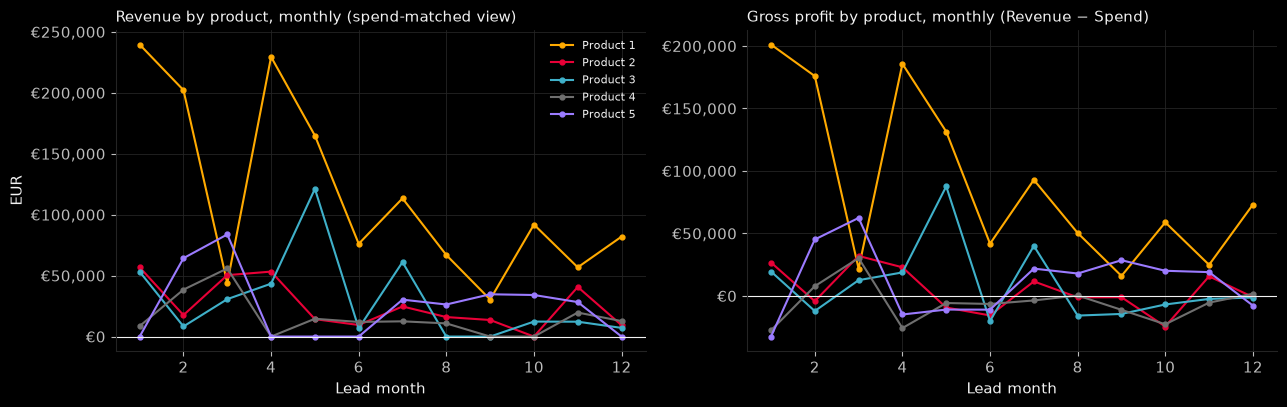

Product 1,Product 2,Product 3,Product 4,Product 5
201170.000000,26760.000000,19550.000000,-27545.000000,-32505.000000
175930.000000,-4180.000000,-12080.000000,7795.000000,45185.000000
21855.000000,32005.000000,12625.000000,30295.000000,62430.000000
185775.000000,22915.000000,18815.000000,-25710.000000,-14845.000000
131480.000000,-9285.000000,87675.000000,-5655.000000,-10905.000000
41835.000000,-15595.000000,-20065.000000,-6410.000000,-10965.000000
92865.000000,11620.000000,40035.000000,-3600.000000,21865.000000
50405.000000,-1130.000000,-15715.000000,375.000000,17950.000000
15990.000000,-1020.000000,-14400.000000,-11125.000000,28585.000000
58880.000000,-24465.000000,-6825.000000,-22670.000000,20140.000000


**Finding.** Every product has at least one loss-making month - **Product 5** in month 1 is the single worst (€-32,505). Read November-December with the same caution as every other monthly chart in this notebook (Section 8): those lead cohorts are still open, so their revenue is understated there, not genuinely collapsing.

In [81]:

prod_month = gridf_arrival.groupby(["lead_month", "lead_product"]).agg(
    **{"Revenue, EUR": ("Revenue, EUR", "sum"), "Spend, EUR": ("Spend, EUR", "sum")}).reset_index()
prod_month["Gross profit, EUR"] = prod_month["Revenue, EUR"] - prod_month["Spend, EUR"]

palette = {"Product 1": ORANGE, "Product 2": RED, "Product 3": "#3fb0c9",
          "Product 4": MUTED, "Product 5": "#9b7bff"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
for prod_name, color in palette.items():
    d = prod_month[prod_month["lead_product"] == prod_name].sort_values("lead_month")
    axes[0].plot(d["lead_month"], d["Revenue, EUR"], color=color, marker="o", markersize=3.5, label=prod_name)
    axes[1].plot(d["lead_month"], d["Gross profit, EUR"], color=color, marker="o", markersize=3.5, label=prod_name)
axes[0].set_title("Revenue by product, monthly (spend-matched view)", color=INK, fontsize=11, loc="left")
axes[1].set_title("Gross profit by product, monthly (Revenue − Spend)", color=INK, fontsize=11, loc="left")
for ax in axes:
    ax.set_xlabel("Lead month")
    ax.axhline(0, color=INK, linewidth=0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(eur))
axes[0].set_ylabel("EUR"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

show(prod_month.rename(columns={"lead_month": "Lead month", "lead_product": "Product"})
    .pivot_table(index="Lead month", columns="Product", values="Gross profit, EUR"),
    "Gross profit by product and month, EUR - View 2 (spend-matched)")

worst_prod_month = prod_month.loc[prod_month["Gross profit, EUR"].idxmin()]
note(f"Every product has at least one loss-making month - **{worst_prod_month['lead_product']}** in "
     f"month {int(worst_prod_month['lead_month'])} is the single worst "
     f"(€{worst_prod_month['Gross profit, EUR']:,.0f}). Read November-December with the same caution as "
     "every other monthly chart in this notebook (Section 8): those lead cohorts are still open, so "
     "their revenue is understated there, not genuinely collapsing.", kind="finding")


### Revenue by brand, over time - and why profit by brand is not shown

Spend in this dataset has no Brand dimension - it only exists at (Month, Channel, Product, Region) grain (Section 5) - so gross profit cannot be computed per brand without inventing a cost allocation this data does not support. Revenue by brand is shown below on its own; a `profit by brand` chart is left out rather than faked with an assumed cost split.

Section 4 already established that `Brand Name` alone is not a safe key - it recycles across genuinely different deals, and `(Brand Name, Product)` is the key that is actually unique. Grouped that way here, for the top brands by total revenue - a line for every one of the ~100+ brand codes would not be readable.

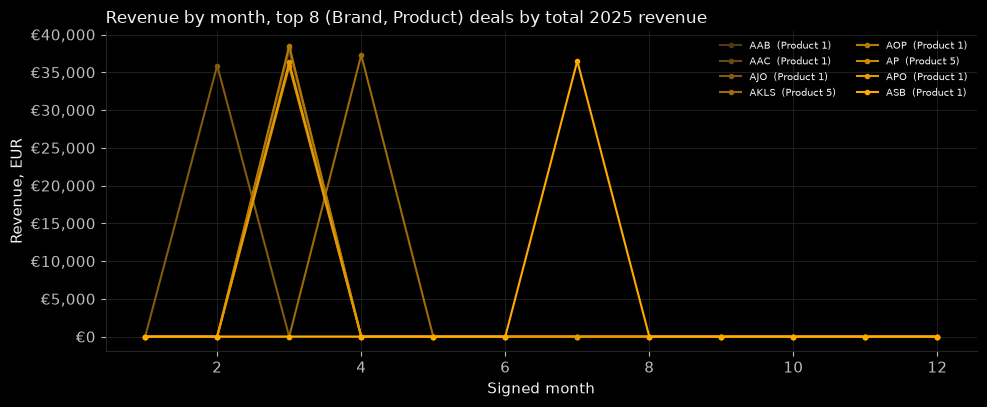

Signed month,AAB (Product 1),AAC (Product 1),AJO (Product 1),AKLS (Product 5),AOP (Product 1),AP (Product 5),APO (Product 1),ASB (Product 1)
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,35900.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,37900.000000,38200.000000,0.000000,0.000000,38500.000000,35800.000000,36300.000000,0.000000
4,0.000000,0.000000,0.000000,37300.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36500.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**Note.** These 8 rows are the biggest individual deals of the year, not repeat accounts - almost every one closes in a single month and sits at zero every other month, consistent with Section 3's finding that only 1 of 8,841 leads has more than one Signed deal all year. A brand 'trending down' here means 'that deal already closed', not 'that account is churning' - there is no repeat-purchase population in this dataset to read a real brand trend off of (Section 10). No profit-by-brand view is shown for the reason above: Spend has no Brand dimension, so any brand-level cost would have to be invented, not measured.

In [82]:

signed_rows = work[work["is_signed"] == 1].copy()
signed_rows["brand_label"] = signed_rows["Brand Name"] + "  (" + signed_rows["Product"] + ")"

top_n = 8
top_brands = (signed_rows.groupby("brand_label")["deal_value_eur"].sum()
             .sort_values(ascending=False).head(top_n).index)

brand_month = (signed_rows[signed_rows["brand_label"].isin(top_brands)]
              .groupby(["signed_month", "brand_label"])["deal_value_eur"].sum().reset_index())
brand_pivot = (brand_month.pivot(index="signed_month", columns="brand_label", values="deal_value_eur")
              .reindex(range(1, 13)).fillna(0))

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, brand in enumerate(brand_pivot.columns):
    color = CMAP(0.25 + 0.75 * i / max(top_n - 1, 1))
    ax.plot(brand_pivot.index, brand_pivot[brand], marker="o", markersize=3, color=color, label=brand)
ax.set_xlabel("Signed month"); ax.set_ylabel("Revenue, EUR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(eur))
ax.set_title(f"Revenue by month, top {top_n} (Brand, Product) deals by total 2025 revenue",
            color=INK, fontsize=12, loc="left")
ax.legend(fontsize=7.5, ncol=2)
plt.tight_layout(); plt.show()

show(brand_pivot.reset_index().rename(columns={"signed_month": "Signed month"}),
    f"Top {top_n} brands - revenue by month, EUR")

note(f"These {top_n} rows are the biggest individual deals of the year, not repeat accounts - almost "
     "every one closes in a single month and sits at zero every other month, consistent with Section 3's "
     "finding that only 1 of 8,841 leads has more than one Signed deal all year. A brand 'trending down' "
     "here means 'that deal already closed', not 'that account is churning' - there is no repeat-purchase "
     "population in this dataset to read a real brand trend off of (Section 10). No profit-by-brand view "
     "is shown for the reason above: Spend has no Brand dimension, so any brand-level cost would have to "
     "be invented, not measured.", kind="info")


In [83]:

roi_region = roi_by(["region"])
show(roi_region[["region", "Leads", "Signed", "Lead->Signed %", "Spend, EUR", "Revenue, EUR", "ROAS"]],
     "Region economics (blended)", highlight_col="ROAS")
note("Blended ROAS is close across all three regions - see the stage-by-stage breakdown next for where "
     "each region actually gains or loses people, rather than reading that off a single blended number.",
     kind="info")


region,Leads,Signed,Lead->Signed %,"Spend, EUR","Revenue, EUR",ROAS
LatAm,3623,46,1.270000,484650.000000,1042100.000000,2.150000
Europe,2602,31,1.190000,377675.000000,776500.000000,2.060000
US,2616,34,1.300000,381720.000000,728500.000000,1.910000


**Note.** Blended ROAS is close across all three regions - see the stage-by-stage breakdown next for where each region actually gains or loses people, rather than reading that off a single blended number.

### Region × stage: a sales-effectiveness question, or lead quality?

The same stage-by-stage breakdown as the channel heatmap earlier, by region instead - this is the view that actually isolates *where* in the funnel a region falls behind, which is what "is a sales team more/less effective in some region" really needs. **This dataset has no sales-rep, SDR, or account-owner field anywhere** - Leads, MQL, SAL and Signed are all silent on who worked each deal - so this can only speak to region-level patterns, never to an individual manager's performance.

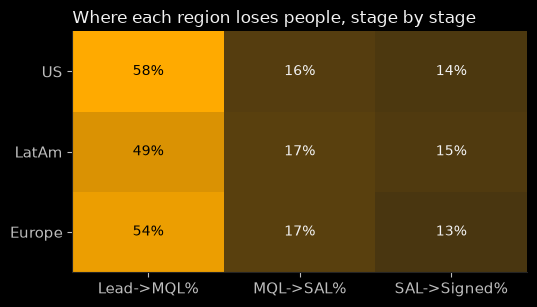

region,Leads,MQL,SAL,Signed,Lead->MQL%,MQL->SAL%,SAL->Signed%
Europe,2602,1391,238,31,53.500000,17.100000,13.000000
LatAm,3623,1780,307,46,49.100000,17.200000,15.000000
US,2616,1523,244,34,58.200000,16.000000,13.900000


**Finding.** **SAL→Signed** is the stage closest to actual sales execution (Lead→MQL is mostly a lead-quality/marketing question; MQL→SAL is qualification hand-off). **Europe** closes the worst of the three regions (13%) against **LatAm**'s 15% - a real gap, and Section 15.2 already checked it isn't simply explained by channel mix (the worst-closing region was the worst of the three in only 3 of 8 channels with enough volume to compare - not a clean, consistent pattern). That leaves genuine regional differences in sales execution as a live possibility, but **without a rep or account-owner field in this dataset, that can only be read as a region-level pattern, never attributed to a specific manager or team**. If the business suspects a manager-effectiveness gap specifically, the fix is a data one: add a sales-owner ID to SAL/Signed next year, not a deeper cut of what's already here.

In [84]:

stage_region = work.groupby("region").agg(
    Leads=("is_lead_product", "sum"), MQL=("is_mql", "sum"), SAL=("is_sal", "sum"), Signed=("is_signed", "sum")
).reset_index()
stage_region["Lead->MQL%"] = (stage_region["MQL"] / stage_region["Leads"] * 100).round(1)
stage_region["MQL->SAL%"] = (stage_region["SAL"] / stage_region["MQL"] * 100).round(1)
stage_region["SAL->Signed%"] = (stage_region["Signed"] / stage_region["SAL"] * 100).round(1)

hm_r = stage_region.set_index("region")[["Lead->MQL%", "MQL->SAL%", "SAL->Signed%"]].reindex(REGIONS)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
im = ax.imshow(hm_r.values, cmap=CMAP, aspect="auto", vmin=0, vmax=hm_r.values.max())
ax.set_xticks(range(3)); ax.set_xticklabels(hm_r.columns)
ax.set_yticks(range(len(hm_r))); ax.set_yticklabels(hm_r.index)
for i in range(hm_r.shape[0]):
    for j in range(hm_r.shape[1]):
        v = hm_r.values[i, j]
        txt_color = BG if v > hm_r.values.max() * 0.55 else INK
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color=txt_color, fontsize=10)
ax.set_title("Where each region loses people, stage by stage", color=INK, fontsize=12, loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

show(stage_region[["region", "Leads", "MQL", "SAL", "Signed", "Lead->MQL%", "MQL->SAL%", "SAL->Signed%"]],
    "Stage-by-stage conversion, by region")

worst_close_region = hm_r["SAL->Signed%"].idxmin()
best_close_region = hm_r["SAL->Signed%"].idxmax()
note(f"**SAL→Signed** is the stage closest to actual sales execution (Lead→MQL is mostly a lead-quality/"
     f"marketing question; MQL→SAL is qualification hand-off). **{worst_close_region}** closes the worst "
     f"of the three regions ({hm_r.loc[worst_close_region, 'SAL->Signed%']:.0f}%) against "
     f"**{best_close_region}**'s {hm_r.loc[best_close_region, 'SAL->Signed%']:.0f}% - a real gap, and "
     "Section 15.2 already checked it isn't simply explained by channel mix (the worst-closing region was "
     "the worst of the three in only 3 of 8 channels with enough volume to compare - not a clean, "
     "consistent pattern). That leaves genuine regional differences in sales execution as a live "
     "possibility, but **without a rep or account-owner field in this dataset, that can only be read as a "
     "region-level pattern, never attributed to a specific manager or team**. If the business suspects a "
     "manager-effectiveness gap specifically, the fix is a data one: add a sales-owner ID to SAL/Signed "
     "next year, not a deeper cut of what's already here.", kind="finding")


In [85]:

# Does the worst-closing region also take longer to close, or does it fail at the SAME speed as
# everyone else but just less often? Speed and rate are different failure modes, and only one of
# them looks like "a team working deals more slowly".
lag_by_region_signed = (signed_leads.groupby("region")["days_to_close"]
                        .agg(["median", "mean", "count"]).reindex(REGIONS))
show(lag_by_region_signed.reset_index().rename(
    columns={"median": "Median days to close", "mean": "Mean days to close", "count": "Signed deals"}),
    "Days to close (signed leads only), by region")

note(f"Median days-to-close ranges only {lag_by_region_signed['median'].min():.0f}-"
     f"{lag_by_region_signed['median'].max():.0f} days across regions - close to identical. "
     f"**{worst_close_region}** is not slower to close, it just converts a smaller share of the SAL it "
     "gets into a Signed deal - a rate problem, not a speed problem. That points more toward a "
     "qualification-bar or deal-fit issue than a sales team simply working deals sluggishly - which "
     "narrows what a sales-owner ID would need to check first, if one gets added.", kind="info")


region,Median days to close,Mean days to close,Signed deals
US,25.500000,26.588235,34
LatAm,30.000000,28.760870,46
Europe,29.000000,30.935484,31


**Note.** Median days-to-close ranges only 26-30 days across regions - close to identical. **Europe** is not slower to close, it just converts a smaller share of the SAL it gets into a Signed deal - a rate problem, not a speed problem. That points more toward a qualification-bar or deal-fit issue than a sales team simply working deals sluggishly - which narrows what a sales-owner ID would need to check first, if one gets added.

In [86]:

# Revisiting Section 3's first-touch decision, now with real EUR CPL by channel - the same
# table analyze_duplicates.py built during exploration, brought in properly: does the choice
# of all-visits vs. first-touch vs. last-touch actually move CPL enough to matter, per channel?
den_a = leads.groupby("Session Source / Medium").size()
den_b = first_touch.groupby("Session Source / Medium").size()
den_c = last_touch.groupby("Session Source / Medium").size()
spend_ch2 = spend.groupby("Session Source / Medium")["spend_eur"].sum()

cpl_sensitivity = pd.DataFrame({"A. every row (visits)": den_a, "B. first touch (adopted)": den_b,
                                "C. last touch": den_c, "Spend, EUR": spend_ch2})
cpl_sensitivity["CPL A, EUR"] = (cpl_sensitivity["Spend, EUR"] / cpl_sensitivity["A. every row (visits)"]).round(1)
cpl_sensitivity["CPL B, EUR"] = (cpl_sensitivity["Spend, EUR"] / cpl_sensitivity["B. first touch (adopted)"]).round(1)
cpl_sensitivity.loc[cpl_sensitivity["Spend, EUR"] == 0, ["CPL A, EUR", "CPL B, EUR"]] = np.nan
cpl_sensitivity["CPL inflated by first-touch, %"] = (
    (cpl_sensitivity["CPL B, EUR"] / cpl_sensitivity["CPL A, EUR"] - 1) * 100).round(2)
show(cpl_sensitivity.reset_index().rename(columns={"index": "Channel"}),
     "CPL sensitivity by channel: all-visits vs. first-touch vs. last-touch")

paid_idx = cpl_sensitivity.index.isin(PAID)
paid_rows_lost = int((cpl_sensitivity.loc[paid_idx, "A. every row (visits)"]
                     - cpl_sensitivity.loc[paid_idx, "B. first touch (adopted)"]).sum())
paid_visit_total = int(cpl_sensitivity.loc[paid_idx, "A. every row (visits)"].sum())
note(f"Of the 89 second visits dropped by first-touch dedup, {paid_rows_lost} were in paid channels - "
     f"{paid_rows_lost/paid_visit_total*100:.2f}% of all paid visits. CPL moves by tenths of a percent "
     "per channel. This is the same check Section 3's decision rests on, now in EUR per channel rather "
     "than just total lead counts - first-touch is kept because it is conceptually correct, not because "
     "the alternative would have changed any channel's CPL materially.", kind="info")


Session Source / Medium,A. every row (visits),B. first touch (adopted),C. last touch,"Spend, EUR","CPL A, EUR","CPL B, EUR","CPL inflated by first-touch, %"
(direct) / (none),695,689,688,0.000000,nan,nan,nan
bing / organic,932,922,920,0.000000,nan,nan,nan
chatgpt.com / referral,370,364,367,0.000000,nan,nan,nan
facebook / cpc,758,753,753,377135.000000,497.500000,500.800000,0.660000
facebook / cpm,398,395,394,119770.000000,300.900000,303.200000,0.760000
google / cpc,774,768,765,694165.000000,896.900000,903.900000,0.780000
google / organic,4651,4602,4604,0.000000,nan,nan,nan
linkedin.com / referral,352,348,350,52975.000000,150.500000,152.200000,1.130000


**Note.** Of the 89 second visits dropped by first-touch dedup, 18 were in paid channels - 0.79% of all paid visits. CPL moves by tenths of a percent per channel. This is the same check Section 3's decision rests on, now in EUR per channel rather than just total lead counts - first-touch is kept because it is conceptually correct, not because the alternative would have changed any channel's CPL materially.

<a id="10"></a>
## 10. Payback horizon & repeat-purchase (LTV) analysis

Section 3 already answered the repeat-purchase question directly: essentially no lead in this dataset buys twice (1 case out of 8,841). Classic mobile-app LTV curves are built on a population that returns and re-purchases repeatedly - that population does not exist here, so "LTV" in this section means something adapted: **cumulative Signed revenue per euro of paid spend, as a function of days since the lead first arrived** - by Product, Region and Channel, the equivalent cuts to the classic device/country/channel framework given what this dataset actually contains.

In [87]:

# "LTV" here = cumulative Signed revenue attributed to a paid lead cohort, as a function of
# days since that lead first arrived. "ROI" = that cumulative revenue divided by the cohort's
# paid spend. Revenue is dated by SAL date (the closest real date available - every Signed
# deal is confirmed to close in the same month as its SAL, so SAL date is a good day-level
# proxy for the close date).
HORIZON_DAYS = 90  # covers the max observed lead->close lag (74 days) with headroom

signed_ev = work[(work["is_signed"] == 1) & work["source_medium"].isin(PAID)].copy()
signed_ev["days_since_lead"] = (signed_ev["sal_dt"] - signed_ev["lead_date"]).dt.days


def payback_curve(dim_col, spend_col, horizon=HORIZON_DAYS):
    spend_dim = spend[spend["Session Source / Medium"].isin(PAID)].groupby(spend_col)["spend_eur"].sum()
    curves = {}
    for d, spd in spend_dim.items():
        ev = signed_ev[signed_ev[dim_col] == d]
        cum = (ev.groupby("days_since_lead")["deal_value_eur"].sum()
              .reindex(range(0, horizon + 1), fill_value=0).cumsum())
        curves[d] = cum / spd
    return pd.DataFrame(curves)


def plot_payback(curve_df, title):
    final_roi = curve_df.iloc[-1]
    best, worst = final_roi.idxmax(), final_roi.idxmin()
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for d in curve_df.columns:
        color = ORANGE if d == best else (RED if d == worst else MUTED)
        lw = 2.2 if d in (best, worst) else 1.3
        ax.plot(curve_df.index, curve_df[d], color=color, linewidth=lw, label=f"{d}  ({final_roi[d]:.2f})")
    ax.axhline(1.0, color=INK, linestyle="--", linewidth=1)
    ax.axvline(14, color=FAINT, linestyle=":", linewidth=1.3)
    ax.text(15, 0.04, "day 14", color="#bdbdbd", fontsize=8.5, transform=ax.get_xaxis_transform())
    ax.set_xlabel("Days since lead acquisition"); ax.set_ylabel("Cumulative ROI (revenue so far ÷ spend)")
    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.legend(fontsize=8.5, loc="upper left")
    plt.tight_layout(); plt.show()


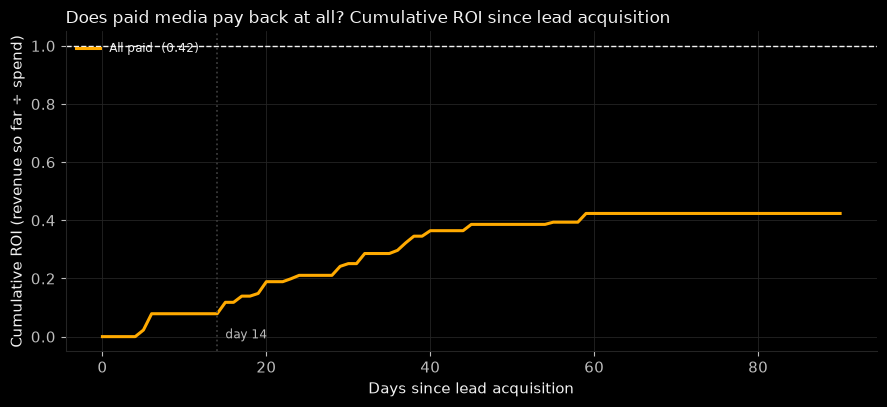

**Risk.** At day 14 - a common payback checkpoint - cumulative paid ROI is only **0.08**. That is not a channel problem, it's a horizon problem: median lead→close is 29 days and the slowest deal in the dataset closes at 74 days (Section 8), so a 2-week rule guarantees a 'fail' verdict before most deals have had time to happen. By day 90 the curve has fully plateaued at **0.42** - paid media overall does not reach breakeven within the observed window at all.

In [88]:

overall_spend = spend[spend["Session Source / Medium"].isin(PAID)]["spend_eur"].sum()
overall_curve = pd.DataFrame({
    "All paid": (signed_ev.groupby("days_since_lead")["deal_value_eur"].sum()
                .reindex(range(0, HORIZON_DAYS + 1), fill_value=0).cumsum() / overall_spend)
})
plot_payback(overall_curve, "Does paid media pay back at all? Cumulative ROI since lead acquisition")

roi14 = overall_curve.loc[14, "All paid"]
roi_final = overall_curve.iloc[-1, 0]
note(f"At day 14 - a common payback checkpoint - cumulative paid ROI is only **{roi14:.2f}**. That is "
     f"not a channel problem, it's a horizon problem: median lead→close is 29 days and the slowest deal "
     f"in the dataset closes at 74 days (Section 8), so a 2-week rule guarantees a 'fail' verdict before "
     f"most deals have had time to happen. By day {HORIZON_DAYS} the curve has fully plateaued at "
     f"**{roi_final:.2f}** - paid media overall does not reach breakeven within the observed window at all.",
     kind="risk")


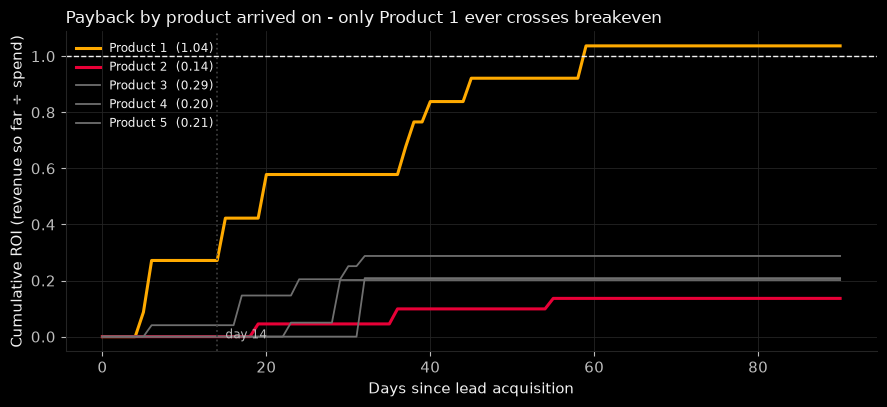

**Finding.** **Product 1** is the only product whose paid spend pays back at all in this dataset - it crosses ROI = 1.0 at day 59 and finishes at 1.04. The other four plateau below breakeven (Product 2: 0.14, Product 3: 0.29, Product 4: 0.20, Product 5: 0.21) but not equally: Product 2 is the clear worst here, not Product 4 - Section 9's View 1 (revenue by product bought) made Product 4 look far worse than it is, because cross-sold revenue from its acquired leads was being credited to whichever product they ended up buying instead.

In [89]:

# Grouped by lead_product (the product campaign that was actually paid for), not the
# stage-native Product - Section 9 found the two disagree on 28% of signed revenue, and a
# payback curve is inherently a "did THIS spend come back" question, so it needs the
# spend-matched attribution, not the SKU-sold one.
product_curves = payback_curve("lead_product", "Product")
plot_payback(product_curves, "Payback by product arrived on - only Product 1 ever crosses breakeven")

final_roi = product_curves.iloc[-1]
cross_day = product_curves.index[(product_curves["Product 1"] >= 1.0)].min()
note(f"**Product 1** is the only product whose paid spend pays back at all in this dataset - it crosses "
     f"ROI = 1.0 at day {cross_day} and finishes at {final_roi['Product 1']:.2f}. The other four plateau "
     f"below breakeven ({', '.join(f'{p}: {v:.2f}' for p, v in final_roi.items() if p != 'Product 1')}) "
     "but not equally: Product 2 is the clear worst here, not Product 4 - Section 9's View 1 "
     "(revenue by product bought) made Product 4 look far worse than it is, because cross-sold revenue "
     "from its acquired leads was being credited to whichever product they ended up buying instead.",
     kind="finding")


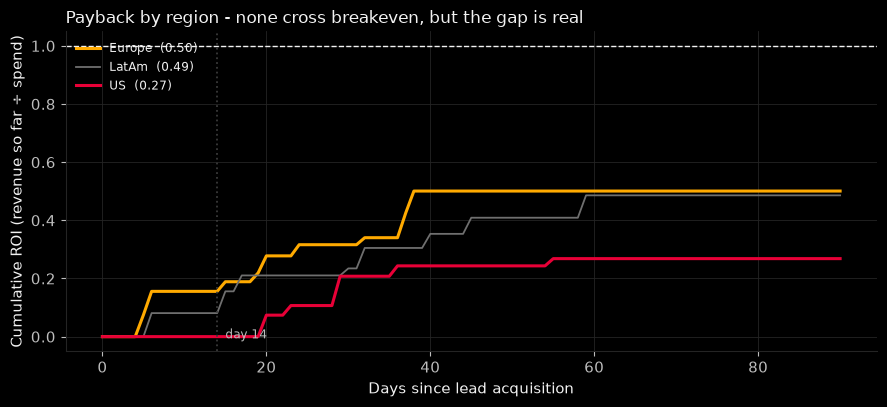

**Finding.** No region reaches breakeven within 90 days, but they are not equally far off: Europe: 0.50, LatAm: 0.49, US: 0.27. The US is worst - consistent with Section 9's finding that the US has the best top-of-funnel (Lead→MQL) but the worst close rate (SAL→Signed) of the three regions.

In [90]:

region_curves = payback_curve("region", "Region")
plot_payback(region_curves, "Payback by region - none cross breakeven, but the gap is real")

final_roi = region_curves.iloc[-1]
note(f"No region reaches breakeven within {HORIZON_DAYS} days, but they are not equally far off: "
     f"{', '.join(f'{r}: {v:.2f}' for r, v in final_roi.sort_values(ascending=False).items())}. "
     "The US is worst - consistent with Section 9's finding that the US has the best top-of-funnel "
     "(Lead→MQL) but the worst close rate (SAL→Signed) of the three regions.", kind="finding")


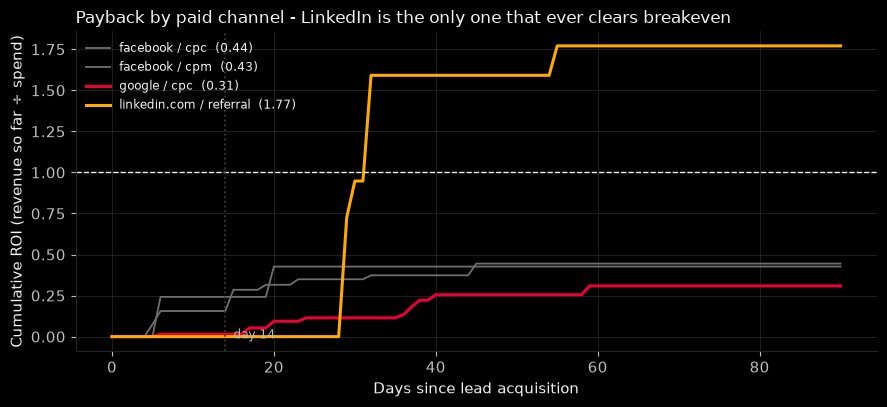

Channel,Cumulative ROI at day 90
linkedin.com / referral,1.770647
facebook / cpc,0.444668
facebook / cpm,0.426651
google / cpc,0.308860


In [91]:

channel_curves = payback_curve("source_medium", "Session Source / Medium")
plot_payback(channel_curves, "Payback by paid channel - LinkedIn is the only one that ever clears breakeven")

final_roi = channel_curves.iloc[-1]
show(final_roi.rename("Cumulative ROI at day " + str(HORIZON_DAYS)).sort_values(ascending=False).reset_index()
     .rename(columns={"index": "Channel"}), "Final cumulative ROI, by paid channel")


In [92]:

display(Markdown(f'''
### Payback analysis - answers, adapted from the classic device/country/channel framework

**Do we have real repeat-purchase LTV?** No - Section 3 found exactly one lead (out of 8,841) with two
Signed deals. That is not a cohort, so a repeat-purchase LTV curve is not buildable from this dataset.
What follows instead is a first-purchase payback curve: cumulative Signed revenue per euro of paid
spend, by days since lead acquisition.

**Does paid media pay back at all?** No - blended across all paid channels, cumulative ROI plateaus at
**{overall_curve.iloc[-1,0]:.2f}** by day {HORIZON_DAYS} and never reaches 1.0 anywhere in the observed
window. Unpaid channels aren't part of this question by construction - they carry no spend, so "payback"
doesn't apply to them the way it does to paid media.

**Which products, regions and channels hurt payback most?** By product *arrived on* - the spend-matched
view (Section 9) - Product 2 is clearly weakest (0.14), Products 4 and 5 sit close together in the
middle (0.20-0.21), and Product 3 is the least-bad non-winner (0.29); the US region (0.27 vs 0.49-0.50
for Europe/LatAm); and three of the four paid channels (google/cpc, facebook/cpc, facebook/cpm - all
under 0.45). Only Product 1 and `linkedin.com / referral` ever clear breakeven.

**What could be causing the payback problem?** Ties directly to Section 11's hypotheses: it is
overwhelmingly a **cost** problem, not a conversion-mechanics problem (paid Lead→MQL and MQL→SAL rates
sit close to unpaid channels) - compounded by a **horizon mismatch**. A 2-week payback rule is not
compatible with a sales cycle whose median lead→close is 29 days and whose slowest deal takes 74
(Section 8) - that rule alone would fail every channel, including the one product (Product 1) that does
eventually pay back around day 59.

**Recommendation on the rule itself:** replace a 14-day payback expectation with something in the
75-90 day range, matched to the observed lead→close distribution (Section 8), and evaluate channels on
their plateaued ROI (this analysis) rather than on an early cumulative read that is guaranteed to look
like failure for a B2B sales cycle this long.
'''))



### Payback analysis - answers, adapted from the classic device/country/channel framework

**Do we have real repeat-purchase LTV?** No - Section 3 found exactly one lead (out of 8,841) with two
Signed deals. That is not a cohort, so a repeat-purchase LTV curve is not buildable from this dataset.
What follows instead is a first-purchase payback curve: cumulative Signed revenue per euro of paid
spend, by days since lead acquisition.

**Does paid media pay back at all?** No - blended across all paid channels, cumulative ROI plateaus at
**0.42** by day 90 and never reaches 1.0 anywhere in the observed
window. Unpaid channels aren't part of this question by construction - they carry no spend, so "payback"
doesn't apply to them the way it does to paid media.

**Which products, regions and channels hurt payback most?** By product *arrived on* - the spend-matched
view (Section 9) - Product 2 is clearly weakest (0.14), Products 4 and 5 sit close together in the
middle (0.20-0.21), and Product 3 is the least-bad non-winner (0.29); the US region (0.27 vs 0.49-0.50
for Europe/LatAm); and three of the four paid channels (google/cpc, facebook/cpc, facebook/cpm - all
under 0.45). Only Product 1 and `linkedin.com / referral` ever clear breakeven.

**What could be causing the payback problem?** Ties directly to Section 11's hypotheses: it is
overwhelmingly a **cost** problem, not a conversion-mechanics problem (paid Lead→MQL and MQL→SAL rates
sit close to unpaid channels) - compounded by a **horizon mismatch**. A 2-week payback rule is not
compatible with a sales cycle whose median lead→close is 29 days and whose slowest deal takes 74
(Section 8) - that rule alone would fail every channel, including the one product (Product 1) that does
eventually pay back around day 59.

**Recommendation on the rule itself:** replace a 14-day payback expectation with something in the
75-90 day range, matched to the observed lead→close distribution (Section 8), and evaluate channels on
their plateaued ROI (this analysis) rather than on an early cumulative read that is guaranteed to look
like failure for a B2B sales cycle this long.


<a id="11"></a>
## 11. Hypotheses — what's actually driving the paid CPL/ROAS problem?

Four candidate explanations for why paid media underperforms, checked against the data in hand rather than assumed. The heatmap in Section 9 is the evidence base for the first and third.

In [93]:

paid_band = stage_ch.loc[stage_ch["Paid"], ["Lead->MQL%", "MQL->SAL%"]]
organic_band = stage_ch.loc[~stage_ch["Paid"], ["Lead->MQL%", "MQL->SAL%"]]
google_organic_row = stage_ch.loc[stage_ch["source_medium"] == "google / organic"].iloc[0]

note(f'''
**A - Is it a funnel-mechanics failure specific to paid traffic?** Mostly no. Paid channels post
Lead→MQL rates of {paid_band["Lead->MQL%"].min():.0f}-{paid_band["Lead->MQL%"].max():.0f}% and MQL→SAL
of {paid_band["MQL->SAL%"].min():.0f}-{paid_band["MQL->SAL%"].max():.0f}%, which sits in the same band as
most unpaid channels (direct, bing, chatgpt). The one real outlier is `google / organic` itself, at
{google_organic_row["Lead->MQL%"]:.0f}% Lead→MQL - well above everything else, paid or unpaid - which
reads as high-intent search traffic (people already looking for the product) rather than paid media
under-delivering.
''', kind="hypothesis")


**Hypothesis.** 
**A - Is it a funnel-mechanics failure specific to paid traffic?** Mostly no. Paid channels post
Lead→MQL rates of 44-46% and MQL→SAL
of 17-18%, which sits in the same band as
most unpaid channels (direct, bing, chatgpt). The one real outlier is `google / organic` itself, at
61% Lead→MQL - well above everything else, paid or unpaid - which
reads as high-intent search traffic (people already looking for the product) rather than paid media
under-delivering.


In [94]:

# Is facebook/cpm's weak close rate a real quality problem, or a small-sample artifact? Broken
# down by product instead of taken at face value.
cpm_row = stage_ch.loc[stage_ch["source_medium"] == "facebook / cpm"].iloc[0]
cpm_sal = work[(work["source_medium"] == "facebook / cpm") & (work["is_sal"] == 1)]
cpm_by_product = cpm_sal.groupby("Product").agg(SAL=("is_sal", "sum"), Signed=("is_signed", "sum"))
cpm_by_product["SAL->Signed %"] = (cpm_by_product["Signed"] / cpm_by_product["SAL"] * 100).round(1)
show(cpm_by_product.reset_index(), "facebook / cpm - SAL→Signed by product")

other_paid_sal = work[work["source_medium"].isin([c for c in PAID if c != "facebook / cpm"])
                      & (work["is_sal"] == 1)]
baseline = other_paid_sal.groupby("Product").agg(SAL=("is_sal", "sum"), Signed=("is_signed", "sum"))
baseline["rate"] = baseline["Signed"] / baseline["SAL"]

cpm_p1_rate = cpm_by_product.loc["Product 1", "SAL->Signed %"] if "Product 1" in cpm_by_product.index else float("nan")
other_p1_rate = baseline.loc["Product 1", "rate"] * 100
non_p1 = cpm_by_product.drop(index="Product 1", errors="ignore")
prob_zero_by_chance = 1.0
for prod, row in non_p1.iterrows():
    r = baseline.loc[prod, "rate"] if prod in baseline.index else 0.0
    prob_zero_by_chance *= (1 - r) ** row["SAL"]

note(f'''
**B - Is one paid channel specifically bad at closing, not just expensive?** More nuanced than it first
looks. `facebook / cpm` converts SAL→Signed at only {cpm_row["SAL->Signed%"]:.1f}% overall - but broken
down by product, its Product 1 leads close at {cpm_p1_rate:.1f}%, in line with Product 1's
{other_p1_rate:.1f}% rate on the other three paid channels. The whole gap sits in Products 2/3/5, where
cpm converted 0 of {int(non_p1["SAL"].sum())} SAL rows to Signed. That is a small sample, though: using the
*other* paid channels' own conversion rates on those same products as a baseline, getting zero by chance
alone has roughly an **{prob_zero_by_chance*100:.0f}% probability** - not a rare event. This reads more like
"too little data to judge" than "cpm leads are worse" - worth re-testing once cpm has more volume on
products other than Product 1, not acting on with 18 data points.
''', kind="hypothesis")


Product,SAL,Signed,SAL->Signed %
Product 1,12,2,16.700000
Product 2,8,0,0.000000
Product 3,8,0,0.000000
Product 5,2,0,0.000000


**Hypothesis.** 
**B - Is one paid channel specifically bad at closing, not just expensive?** More nuanced than it first
looks. `facebook / cpm` converts SAL→Signed at only 6.7% overall - but broken
down by product, its Product 1 leads close at 16.7%, in line with Product 1's
17.5% rate on the other three paid channels. The whole gap sits in Products 2/3/5, where
cpm converted 0 of 18 SAL rows to Signed. That is a small sample, though: using the
*other* paid channels' own conversion rates on those same products as a baseline, getting zero by chance
alone has roughly an **8% probability** - not a rare event. This reads more like
"too little data to judge" than "cpm leads are worse" - worth re-testing once cpm has more volume on
products other than Product 1, not acting on with 18 data points.


In [95]:

note('''
**C - Are we sure the traffic is really coming from where the label says?** Not entirely. This dataset
already contains one confirmed mislabel: `linkedin.com / referral` carries real paid spend despite its
"referral" tag (Section 12). We have no way to rule out smaller versions of the same problem elsewhere -
for example some fraction of `(direct) / (none)` or `google / organic` could plausibly be paid clicks
whose UTM parameters were dropped (a very common real-world tracking failure: ad blockers, in-app
browsers, and cross-domain redirects all strip UTM tags). We can't test this with the data provided; it
would need raw click/session-level logs with landing-page and referrer data, not just an aggregated
Session Source/Medium string per lead.
''', kind="hypothesis")

note('''
**D - Are we even measuring the right side of the funnel?** The Spend tab gives total spend per
(Month, Channel, Product, Region) but no impressions or clicks. That means CPL cannot be decomposed into
`cost-per-click × click-to-lead rate` - so a channel with a high CPL (google/cpc at €904, for instance)
could be expensive because clicks themselves are expensive (competitive auction), or because a lot of
clicks arrive and few become leads (a landing-page problem), and this dataset genuinely cannot
distinguish the two. **This is a real data gap, not an oversight in the analysis** - recommend the paid
platforms export clicks and impressions alongside spend next year, specifically so CPL can be split into
its click-cost and click-to-lead components.
''', kind="hypothesis")


**Hypothesis.** 
**C - Are we sure the traffic is really coming from where the label says?** Not entirely. This dataset
already contains one confirmed mislabel: `linkedin.com / referral` carries real paid spend despite its
"referral" tag (Section 12). We have no way to rule out smaller versions of the same problem elsewhere -
for example some fraction of `(direct) / (none)` or `google / organic` could plausibly be paid clicks
whose UTM parameters were dropped (a very common real-world tracking failure: ad blockers, in-app
browsers, and cross-domain redirects all strip UTM tags). We can't test this with the data provided; it
would need raw click/session-level logs with landing-page and referrer data, not just an aggregated
Session Source/Medium string per lead.


**Hypothesis.** 
**D - Are we even measuring the right side of the funnel?** The Spend tab gives total spend per
(Month, Channel, Product, Region) but no impressions or clicks. That means CPL cannot be decomposed into
`cost-per-click × click-to-lead rate` - so a channel with a high CPL (google/cpc at €904, for instance)
could be expensive because clicks themselves are expensive (competitive auction), or because a lot of
clicks arrive and few become leads (a landing-page problem), and this dataset genuinely cannot
distinguish the two. **This is a real data gap, not an oversight in the analysis** - recommend the paid
platforms export clicks and impressions alongside spend next year, specifically so CPL can be split into
its click-cost and click-to-lead components.


In [96]:

note('''
**E - If paid media were switched off, would total pipeline actually shrink - or just shift to organic?**
This is the question the whole ROAS debate is really standing in for, and this dataset cannot answer it:
every number above is *correlational* (which channel is tagged on the lead that showed up), not
*causal* (what would have shown up if that channel hadn't run). A lead tagged `google / organic` might
still have converted via `google / cpc` had the ad not existed - or might never have shown up at all. We
cannot tell the difference from Session Source/Medium alone. Testing this needs an actual experiment: a
geo holdout (pause paid spend in a subset of regions/markets for a period and compare lead volume against
the regions still running), or a matched-market test, not another cut of the same historical data.
''', kind="hypothesis")

note(f'''
**F - Is paid media buying incremental demand, or partly buying brand/branded-search traffic that would
have converted anyway?** A classic and well-documented risk with paid search specifically: `google / cpc`
competing for the same queries `google / organic` already ranks for. If some share of `google / cpc`
clicks are on branded terms, part of its spend is cannibalizing free traffic rather than generating new
leads - which would make its true incremental ROAS even worse than the {paid_revenue/paid_spend:.2f}
already measured, not better. This dataset has no keyword or search-term breakdown, only an aggregated
channel label, so brand-vs-generic spend split cannot be checked here. Testing it needs either a
keyword-level spend/click export from the ad platform, or a controlled pause of `google / cpc` for a
period, watching whether `google / organic` volume rises to compensate (the same logic as the paid-vs-
unpaid monthly split in Section 8, but as a designed test instead of an observational read).
''', kind="hypothesis")

note('''
**G - How much of Signed revenue is new business vs. an existing customer buying again?** Practically none
measurable, and for a structural reason already established in Section 4: `Brand Name` recycles across
different lead IDs rather than tracking one account over time, and only 1 of 8,841 leads has more than one
Signed deal all year (Sections 3 and 10). That is not "this business has almost no repeat customers" - it
is "this dataset has no stable customer/account identifier, so a repeat customer and a new one are
indistinguishable once Brand Name is reused". New-vs-existing mix is exactly the kind of thing that would
change a channel's real payback profile (a channel skewed toward existing accounts should be judged on a
much shorter payback expectation than one that is 100% new logos) - it just cannot be computed from what
is in this workbook. Needs a persistent account ID in Signed, independent of Brand Name.
''', kind="hypothesis")

note("One more explicit scope note: this dataset has no device dimension anywhere (Leads, Spend and every "
     "other tab are silent on desktop/mobile/tablet) - unlike a mobile-app LTV study, a device breakdown "
     "genuinely cannot be produced here, only channel, product and region (covered in Sections 9-10).",
     kind="info")


**Hypothesis.** 
**E - If paid media were switched off, would total pipeline actually shrink - or just shift to organic?**
This is the question the whole ROAS debate is really standing in for, and this dataset cannot answer it:
every number above is *correlational* (which channel is tagged on the lead that showed up), not
*causal* (what would have shown up if that channel hadn't run). A lead tagged `google / organic` might
still have converted via `google / cpc` had the ad not existed - or might never have shown up at all. We
cannot tell the difference from Session Source/Medium alone. Testing this needs an actual experiment: a
geo holdout (pause paid spend in a subset of regions/markets for a period and compare lead volume against
the regions still running), or a matched-market test, not another cut of the same historical data.


**Hypothesis.** 
**F - Is paid media buying incremental demand, or partly buying brand/branded-search traffic that would
have converted anyway?** A classic and well-documented risk with paid search specifically: `google / cpc`
competing for the same queries `google / organic` already ranks for. If some share of `google / cpc`
clicks are on branded terms, part of its spend is cannibalizing free traffic rather than generating new
leads - which would make its true incremental ROAS even worse than the 0.42
already measured, not better. This dataset has no keyword or search-term breakdown, only an aggregated
channel label, so brand-vs-generic spend split cannot be checked here. Testing it needs either a
keyword-level spend/click export from the ad platform, or a controlled pause of `google / cpc` for a
period, watching whether `google / organic` volume rises to compensate (the same logic as the paid-vs-
unpaid monthly split in Section 8, but as a designed test instead of an observational read).


**Hypothesis.** 
**G - How much of Signed revenue is new business vs. an existing customer buying again?** Practically none
measurable, and for a structural reason already established in Section 4: `Brand Name` recycles across
different lead IDs rather than tracking one account over time, and only 1 of 8,841 leads has more than one
Signed deal all year (Sections 3 and 10). That is not "this business has almost no repeat customers" - it
is "this dataset has no stable customer/account identifier, so a repeat customer and a new one are
indistinguishable once Brand Name is reused". New-vs-existing mix is exactly the kind of thing that would
change a channel's real payback profile (a channel skewed toward existing accounts should be judged on a
much shorter payback expectation than one that is 100% new logos) - it just cannot be computed from what
is in this workbook. Needs a persistent account ID in Signed, independent of Brand Name.


**Note.** One more explicit scope note: this dataset has no device dimension anywhere (Leads, Spend and every other tab are silent on desktop/mobile/tablet) - unlike a mobile-app LTV study, a device breakdown genuinely cannot be produced here, only channel, product and region (covered in Sections 9-10).

In [97]:

note("Priority order for validating these before next year's budget is set: (1) get click/impression "
     "data from the ad platforms so hypothesis D is actually testable, (2) audit UTM tagging beyond the "
     "confirmed LinkedIn gap, (3) let facebook/cpm run longer before drawing conclusions on Products 2/3/5 "
     "- 18 SAL rows is not enough to judge, "
     "(4) check Europe sales coverage/qualification criteria given the region gap in Section 9, "
     "(5) run an actual incrementality test (geo holdout or a controlled pause) before any final call on "
     "whether paid spend is buying net-new pipeline (E, F) - everything above this line is still an "
     "observational read of one year of historical data, not a causal one.",
     kind="decision")


**Decision.** Priority order for validating these before next year's budget is set: (1) get click/impression data from the ad platforms so hypothesis D is actually testable, (2) audit UTM tagging beyond the confirmed LinkedIn gap, (3) let facebook/cpm run longer before drawing conclusions on Products 2/3/5 - 18 SAL rows is not enough to judge, (4) check Europe sales coverage/qualification criteria given the region gap in Section 9, (5) run an actual incrementality test (geo holdout or a controlled pause) before any final call on whether paid spend is buying net-new pipeline (E, F) - everything above this line is still an observational read of one year of historical data, not a causal one.

<a id="12"></a>
## 12. Anomalies

In [98]:

def mad_outliers(series, label):
    med = series.median()
    mad = (series - med).abs().median()
    out = []
    for m, v in series.items():
        if mad > 0 and abs(v - med) > 2 * mad:
            out.append({"Metric": label, "Month": m, "Value": round(float(v), 2),
                        "Median": round(float(med), 2), "Deviation (MAD units)": round(abs(v - med)/mad, 1)})
    return out


mcal = funnel_cal.set_index("Month")
anom_rows = []
for col in ["Lead->MQL %", "MQL->SAL %", "Spend, EUR", "Leads", "ROAS"]:
    anom_rows += mad_outliers(mcal[col].dropna(), col)
show(pd.DataFrame(anom_rows), "Statistical outliers (>2 MAD from the monthly median)")


Metric,Month,Value,Median,Deviation (MAD units)
Lead->MQL %,1,35.700000,56.550000,2.500000
Lead->MQL %,9,35.200000,56.550000,2.600000
Lead->MQL %,10,39.200000,56.550000,2.100000
Lead->MQL %,12,75.400000,56.550000,2.300000
MQL->SAL %,1,5.600000,16.850000,3.500000
MQL->SAL %,11,9.200000,16.850000,2.400000
MQL->SAL %,12,29.400000,16.850000,3.900000
"Spend, EUR",1,170770.000000,109490.000000,2.900000
"Spend, EUR",9,60670.000000,109490.000000,2.300000
"Spend, EUR",12,46115.000000,109490.000000,3.000000


In [99]:

note("Spend drops to a fraction of the monthly median in December while SAL peaks - media was paused "
     "while sales closed accumulated pipeline. Do not set next year's target from this month.")
note("Lead→MQL falls well below the yearly median in September, coinciding with the H2 budget cut. "
     "Worth confirming against the CRM before treating it as a real demand shift.", kind="risk")
linkedin_spend = spend[spend["Session Source / Medium"] == "linkedin.com / referral"]["spend_eur"].sum()
note(f"linkedin.com / referral carries real paid spend (€{linkedin_spend:,.0f}) despite the label - a "
     "UTM tagging gap. Treated as paid throughout this notebook.", kind="risk")


**Finding.** Spend drops to a fraction of the monthly median in December while SAL peaks - media was paused while sales closed accumulated pipeline. Do not set next year's target from this month.

**Risk.** Lead→MQL falls well below the yearly median in September, coinciding with the H2 budget cut. Worth confirming against the CRM before treating it as a real demand shift.

**Risk.** linkedin.com / referral carries real paid spend (€52,975) despite the label - a UTM tagging gap. Treated as paid throughout this notebook.

<a id="13"></a>
## 13. Forecast & scenarios

Downstream conversion rates and deal value are cohort-maturity sensitive, so the model calibrates them on **mature cohorts only** (lead months 1-10, capped at the max observed 2-month lead→signed lag). CPL and lead→MQL are not maturity-sensitive and use the full year.

In [100]:

mature = gridf[gridf["lead_month"] <= 10]
CR_MQL_SAL = mature["SAL"].sum() / mature["MQL"].sum()
CR_SAL_SIGNED = mature["Signed"].sum() / mature["SAL"].sum()
AVG_DEAL = mature["Revenue, EUR"].sum() / mature["Signed"].sum()

full_year = gridf.groupby("source_medium").agg(Leads=("Leads", "sum"), MQL=("MQL", "sum"),
                                               Spend=("Spend, EUR", "sum")).reset_index()
full_year["CPL"] = safe_div(full_year["Spend"], full_year["Leads"])
full_year["CR_lead_mql"] = full_year["MQL"] / full_year["Leads"]
base_ch = mature.groupby("source_medium").agg(Signed=("Signed", "sum"), Revenue=("Revenue, EUR", "sum")) \
    .reset_index().merge(full_year, on="source_medium")
base_ch["Paid"] = base_ch["source_medium"].isin(PAID)

spend_2025 = spend.groupby("Session Source / Medium")["spend_eur"].sum()
paid_roas = gridf[gridf["source_medium"].isin(PAID)].groupby("source_medium").apply(
    lambda g: g["Revenue, EUR"].sum()/g["Spend, EUR"].sum(), include_groups=False).loc[PAID]
median_roas = paid_roas.median()
unpaid_leads_2025 = int(lead_dim[~lead_dim["source_medium"].isin(PAID)].shape[0])
MAX_SCALE = 2.0


def run_scenario(name, budget_mult, cpl_inflation, cr_mult, reallocate):
    rows = []
    base = base_ch.set_index("source_medium")
    budget = spend_2025[PAID] * budget_mult
    if reallocate:
        below = paid_roas[paid_roas < median_roas].index
        above = paid_roas[paid_roas >= median_roas].index
        moved = budget[below].sum() * 0.25
        budget[below] *= 0.75
        budget[above] += moved * (paid_roas[above] / paid_roas[above].sum())
        cap = spend_2025[PAID] * MAX_SCALE
        overflow = (budget - cap).clip(lower=0).sum()
        budget = budget.clip(upper=cap)
        if overflow > 0:
            headroom = (cap - budget).clip(lower=0)
            headroom = headroom[headroom.index.isin(above)]
            if headroom.sum() > 0:
                budget[headroom.index] += overflow * headroom / headroom.sum()
    for ch in PAID:
        cpl = base.loc[ch, "CPL"] * cpl_inflation
        if reallocate and budget[ch] > spend_2025[ch]:
            cpl *= 1.05
        leads = budget[ch] / cpl
        rows.append({"Scenario": name, "Channel": ch, "Paid": True, "Spend, EUR": budget[ch],
                     "Leads": leads, "MQL": leads * base.loc[ch, "CR_lead_mql"] * cr_mult})
    unpaid_cr = base_ch.loc[~base_ch["Paid"], "MQL"].sum() / base_ch.loc[~base_ch["Paid"], "Leads"].sum()
    u_leads = unpaid_leads_2025 * cr_mult
    rows.append({"Scenario": name, "Channel": "unpaid", "Paid": False, "Spend, EUR": 0.0,
                 "Leads": u_leads, "MQL": u_leads * unpaid_cr * cr_mult})
    df = pd.DataFrame(rows)
    df["SAL"] = df["MQL"] * CR_MQL_SAL
    df["Signed"] = df["SAL"] * CR_SAL_SIGNED
    df["Revenue, EUR"] = df["Signed"] * AVG_DEAL
    return df


scenarios = pd.concat([
    run_scenario("Base - same budget, same mix", 1.00, 1.00, 1.00, False),
    run_scenario("Conservative - CPL +10%, conv -10%", 1.00, 1.10, 0.90, False),
    run_scenario("Stretch - budget +10%, reallocated", 1.10, 1.00, 1.00, True),
    run_scenario("Efficiency - paid -30%, concentrated", 0.70, 1.00, 1.00, True),
], ignore_index=True)

summary = scenarios.groupby("Scenario").agg(**{
    "Spend, EUR": ("Spend, EUR", "sum"), "Leads": ("Leads", "sum"), "Signed": ("Signed", "sum"),
    "Revenue, EUR": ("Revenue, EUR", "sum")}).reset_index()
summary["ROAS"] = (summary["Revenue, EUR"] / summary["Spend, EUR"]).round(2)
summary["Gross profit, EUR"] = (summary["Revenue, EUR"] - summary["Spend, EUR"]).round(0)
actual = pd.DataFrame([{"Scenario": "2025 actual", "Spend, EUR": TOTAL_SPEND, "Leads": 8841,
                        "Signed": 111, "Revenue, EUR": float(signed_raw["Deal Value, EUR"].sum()),
                        "ROAS": round(signed_raw["Deal Value, EUR"].sum()/TOTAL_SPEND, 2),
                        "Gross profit, EUR": round(signed_raw["Deal Value, EUR"].sum()-TOTAL_SPEND, 0)}])
summary = pd.concat([actual, summary], ignore_index=True)
for c in ["Spend, EUR", "Leads", "Signed", "Revenue, EUR", "Gross profit, EUR"]:
    summary[c] = summary[c].round(0)
show(summary, "2026 scenarios - gross profit = revenue minus media spend")


Scenario,"Spend, EUR",Leads,Signed,"Revenue, EUR",ROAS,"Gross profit, EUR"
2025 actual,1244045.000000,8841.000000,111.000000,2547100.000000,2.050000,1303055.000000
"Base - same budget, same mix",1244045.000000,8841.000000,116.000000,2691754.000000,2.160000,1447709.000000
"Conservative - CPL +10%, conv -10%",1244045.000000,7977.000000,94.000000,2185097.000000,1.760000,941052.000000
"Efficiency - paid -30%, concentrated",870832.000000,8524.000000,112.000000,2612114.000000,3.000000,1741283.000000
"Stretch - budget +10%, reallocated",1368450.000000,9323.000000,121.000000,2819240.000000,2.060000,1450790.000000


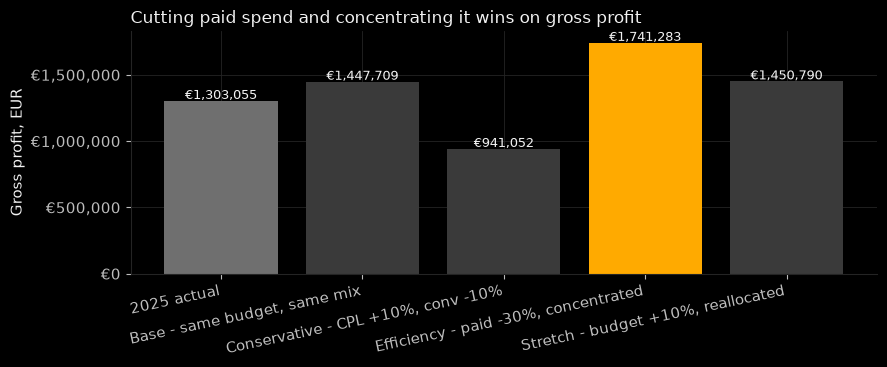

**Finding.** Cutting paid spend 30% and concentrating what remains in the channels that clear breakeven raises modelled gross profit from €1,303,055 to **€1,741,283** while losing a handful of signed deals. Growth spending (the Stretch scenario) is close to profit-neutral: the marginal channel returns well under €1 per euro spent.

In [101]:

colors = [MUTED if s == "2025 actual" else (ORANGE if "Efficiency" in s else FAINT) for s in summary["Scenario"]]
fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(summary["Scenario"], summary["Gross profit, EUR"], color=colors)
for b, v in zip(bars, summary["Gross profit, EUR"]):
    ax.text(b.get_x()+b.get_width()/2, v + 15000, f"€{v:,.0f}", ha="center", color=INK, fontsize=9)
ax.set_ylabel("Gross profit, EUR"); ax.yaxis.set_major_formatter(mticker.FuncFormatter(eur))
ax.set_title("Cutting paid spend and concentrating it wins on gross profit", color=INK, fontsize=12, loc="left")
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
plt.tight_layout(); plt.show()

eff = summary[summary["Scenario"].str.contains("Efficiency")].iloc[0]
act = summary[summary["Scenario"] == "2025 actual"].iloc[0]
note(f"Cutting paid spend 30% and concentrating what remains in the channels that clear breakeven raises "
     f"modelled gross profit from €{act['Gross profit, EUR']:,.0f} to **€{eff['Gross profit, EUR']:,.0f}** "
     "while losing a handful of signed deals. Growth spending (the Stretch scenario) is close to "
     "profit-neutral: the marginal channel returns well under €1 per euro spent.")


### 2026 concrete budget plan - specific moves, not just a scenario percentage

The scenarios above show *what happens to gross profit* under a few stylised budget moves. This is *where the money actually goes*, channel by channel, each move tied to its own specific evidence - so "cut paid 30%" becomes four named, sized, justified decisions instead of one dial.

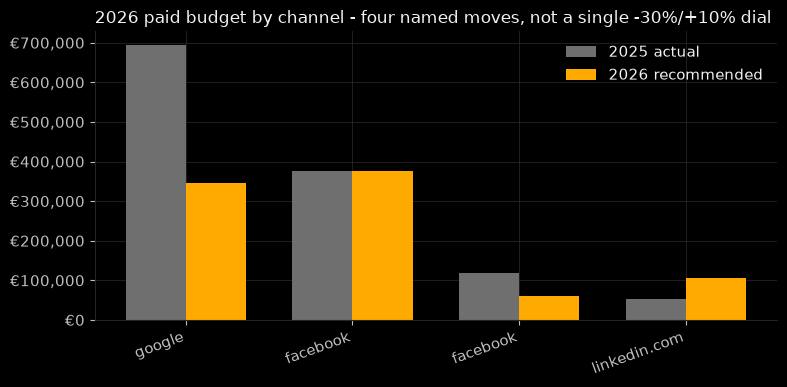

Channel,"Spend, EUR","Revenue, EUR",Signed,ROAS,"CPL, EUR","CAC, EUR","2026 recommended spend, EUR","Change, EUR",Change %
google / cpc,694165.000000,214400.000000,9,0.310000,903.900000,77129.000000,347082.500000,-347082.500000,-50.000000
facebook / cpc,377135.000000,167700.000000,8,0.440000,500.800000,47142.000000,377135.000000,0.000000,0.000000
facebook / cpm,119770.000000,51100.000000,2,0.430000,303.200000,59885.000000,59885.000000,-59885.000000,-50.000000
linkedin.com / referral,52975.000000,93800.000000,4,1.770000,152.200000,13244.000000,105950.000000,52975.000000,100.000000


**Decision.** Net paid budget change: **€-353,992** (a net cut). Freed mostly by halving `google / cpc` - currently €694,165, **56% of the entire paid budget**, and the worst channel on ROAS, CPL *and* CAC at once, not just one metric.

- **`google / cpc` -50%**: ROAS 0.31, CPL €904, CAC €77,129 - worst of all four paid channels on every metric at once, on the single biggest budget line. Cut here first - it is the lowest-risk cut in the whole plan for exactly that reason.
- **`facebook / cpm` -50%**: same story at smaller scale (ROAS 0.43, only 2 signed deals all year) - shrink, don't kill, until more deals accumulate to judge it properly.
- **`facebook / cpc` held flat, mix shifted toward Product 1**: blended ROAS (0.44) looks mediocre, but Section 9's tiered view found facebook/cpc x Product 1 has real support (5 signed deals, 1.41 ROAS) hiding inside that blend. Don't cut the channel - retarget its campaigns toward Product 1 and away from products it hasn't proven itself on.
- **`linkedin.com / referral` +100%**: best ROAS in the dataset (1.77) on only 4% of paid spend - clearly underfunded relative to performance. Doubled, not scaled further, because it is still only 4 signed deals for the whole year (Section 15.1's bootstrap CI on this channel is wide) - treat the increase itself as a monitored test, re-checked against Q1 2026 numbers, not a settled bet.

In [102]:

plan = roi_paid.set_index("source_medium")[["Spend, EUR", "Revenue, EUR", "Signed", "ROAS", "CPL, EUR", "CAC, EUR"]].reindex(PAID)

# Each move below is a decision, not a formula - sized to the specific evidence for that channel.
recommended_change = {
    "google / cpc": -0.50,             # worst ROAS, CPL and CAC of all four - simultaneously - on the
                                        # single biggest budget line (Section 9)
    "facebook / cpm": -0.50,           # same weak-ROAS story at smaller scale, only 2 signed deals all
                                        # year (Section 9) - shrink, don't kill, until there's more to judge
    "facebook / cpc": 0.00,            # mediocre blended ROAS hides a real Product 1 result (Section 9's
                                        # tiered view: n=5, ROAS 1.41) - hold total spend, shift the mix
    "linkedin.com / referral": 1.00,   # best ROAS in the dataset by far, clearly underfunded - but still
                                        # only 4 signed deals all year, so doubled, not 5x'd
}
plan["2026 recommended spend, EUR"] = [plan.loc[ch, "Spend, EUR"] * (1 + recommended_change[ch]) for ch in plan.index]
plan["Change, EUR"] = plan["2026 recommended spend, EUR"] - plan["Spend, EUR"]
plan["Change %"] = (plan["Change, EUR"] / plan["Spend, EUR"] * 100).round(0)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(plan))
ax.bar(x - 0.18, plan["Spend, EUR"], width=0.36, color=MUTED, label="2025 actual")
ax.bar(x + 0.18, plan["2026 recommended spend, EUR"], width=0.36, color=ORANGE, label="2026 recommended")
ax.set_xticks(x); ax.set_xticklabels([c.split(" /")[0] for c in plan.index], rotation=20, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(eur))
ax.set_title("2026 paid budget by channel - four named moves, not a single -30%/+10% dial",
             color=INK, fontsize=12, loc="left")
ax.legend()
plt.tight_layout(); plt.show()

show(plan.reset_index().rename(columns={"source_medium": "Channel"}), "2026 recommended paid budget, by channel")

net_change = plan["Change, EUR"].sum()
gcpc_share = plan.loc["google / cpc", "Spend, EUR"] / plan["Spend, EUR"].sum() * 100
li_share = plan.loc["linkedin.com / referral", "Spend, EUR"] / plan["Spend, EUR"].sum() * 100
note(f"Net paid budget change: **€{net_change:,.0f}** ({'a net cut' if net_change < 0 else 'a net increase'}). "
     f"Freed mostly by halving `google / cpc` - currently €{plan.loc['google / cpc', 'Spend, EUR']:,.0f}, "
     f"**{gcpc_share:.0f}% of the entire paid budget**, and the worst channel on ROAS, CPL *and* CAC at "
     "once, not just one metric.\n\n"
     f"- **`google / cpc` -50%**: ROAS {plan.loc['google / cpc', 'ROAS']:.2f}, CPL "
     f"€{plan.loc['google / cpc', 'CPL, EUR']:,.0f}, CAC €{plan.loc['google / cpc', 'CAC, EUR']:,.0f} - "
     "worst of all four paid channels on every metric at once, on the single biggest budget line. Cut "
     "here first - it is the lowest-risk cut in the whole plan for exactly that reason.\n"
     f"- **`facebook / cpm` -50%**: same story at smaller scale (ROAS "
     f"{plan.loc['facebook / cpm', 'ROAS']:.2f}, only {int(plan.loc['facebook / cpm', 'Signed'])} signed "
     "deals all year) - shrink, don't kill, until more deals accumulate to judge it properly.\n"
     f"- **`facebook / cpc` held flat, mix shifted toward Product 1**: blended ROAS "
     f"({plan.loc['facebook / cpc', 'ROAS']:.2f}) looks mediocre, but Section 9's tiered view found "
     "facebook/cpc x Product 1 has real support (5 signed deals, 1.41 ROAS) hiding inside that blend. "
     "Don't cut the channel - retarget its campaigns toward Product 1 and away from products it hasn't "
     "proven itself on.\n"
     f"- **`linkedin.com / referral` +100%**: best ROAS in the dataset "
     f"({plan.loc['linkedin.com / referral', 'ROAS']:.2f}) on only {li_share:.0f}% of paid spend - clearly "
     "underfunded relative to performance. Doubled, not scaled further, because it is still only "
     f"{int(plan.loc['linkedin.com / referral', 'Signed'])} signed deals for the whole year (Section "
     "15.1's bootstrap CI on this channel is wide) - treat the increase itself as a monitored test, "
     "re-checked against Q1 2026 numbers, not a settled bet.", kind="decision")


### 2026 plan - the non-budget actions, with the same specificity

Reallocating media spend is only half of what this analysis supports doing differently in 2026. The rest costs no media budget at all.

In [103]:

action_plan = pd.DataFrame([
    {"Action": "Run the MQL SLA test (48h first-contact target)", "Owner": "Sales Ops",
     "Timeline": "~22 weeks at current MQL volume (Section 15.11)",
     "Why": "19-day median MQL→SAL lag is structural across every channel/product/region (Section 8) - "
            "test whether it is a real cycle floor or queue speed before assuming it can't be shortened."},
    {"Action": "Audit September SDR/qualification capacity vs. the rest of the year", "Owner": "Sales Ops",
     "Timeline": "Before Q3 2026",
     "Why": "Every channel dipped on Lead→MQL at once in September (Section 8), a qualification-capacity "
            "signature rather than a lead-quality or channel problem, confirmed statistically significant "
            "(Section 15.7, p<0.001) rather than normal monthly noise."},
    {"Action": "Get a sales answer on Product 5's zero US sales", "Owner": "Product & Sales",
     "Timeline": "Q1 2026",
     "Why": "Product 5 has zero signed deals in the US all year, on any channel (Section 9) - a real "
            "market-fit gap or simply no push there; this dataset alone cannot tell which."},
    {"Action": "Protect and keep investing in SEO/content for google/organic", "Owner": "Marketing",
     "Timeline": "Ongoing",
     "Why": f"Drives {organic_share * 100:.0f}% of all revenue at €0 media cost (Section 9) - the "
            "highest-leverage channel in the business, with no media budget line to even reallocate from."},
    {"Action": "Add a sales-owner/rep ID to the SAL and Signed tabs", "Owner": "RevOps / Data",
     "Timeline": "Next data refresh",
     "Why": "Europe closes SAL→Signed worse than the other two regions (Section 9 / 15.2), but this "
            "dataset cannot tell whether that is the market or specific reps - this closes that gap for "
            "good instead of guessing at it again next year."},
    {"Action": "Run a geo-holdout or controlled pause on the weakest paid channel", "Owner": "Marketing & Data",
     "Timeline": "H1 2026",
     "Why": "Every ROAS number in this notebook is correlational (Section 11, hypotheses E/F) - before "
            "locking in the budget cuts above for a second year running, confirm paid demand is not "
            "partly organic volume that would have converted anyway."},
])
show(action_plan, "2026 action plan - non-budget items, each tied to a specific finding")


Action,Owner,Timeline,Why
Run the MQL SLA test (48h first-contact target),Sales Ops,~22 weeks at current MQL volume (Section 15.11),19-day median MQL→SAL lag is structural across every channel/product/region (Section 8) - test whether it is a real cycle floor or queue speed before assuming it can't be shortened.
Audit September SDR/qualification capacity vs. the rest of the year,Sales Ops,Before Q3 2026,"Every channel dipped on Lead→MQL at once in September (Section 8), a qualification-capacity signature rather than a lead-quality or channel problem, confirmed statistically significant (Section 15.7, p<0.001) rather than normal monthly noise."
Get a sales answer on Product 5's zero US sales,Product & Sales,Q1 2026,"Product 5 has zero signed deals in the US all year, on any channel (Section 9) - a real market-fit gap or simply no push there; this dataset alone cannot tell which."
Protect and keep investing in SEO/content for google/organic,Marketing,Ongoing,"Drives 62% of all revenue at €0 media cost (Section 9) - the highest-leverage channel in the business, with no media budget line to even reallocate from."
Add a sales-owner/rep ID to the SAL and Signed tabs,RevOps / Data,Next data refresh,"Europe closes SAL→Signed worse than the other two regions (Section 9 / 15.2), but this dataset cannot tell whether that is the market or specific reps - this closes that gap for good instead of guessing at it again next year."
Run a geo-holdout or controlled pause on the weakest paid channel,Marketing & Data,H1 2026,"Every ROAS number in this notebook is correlational (Section 11, hypotheses E/F) - before locking in the budget cuts above for a second year running, confirm paid demand is not partly organic volume that would have converted anyway."


<a id="14"></a>
## 14. Findings & recommendations

In [104]:

display(Markdown(f'''
### Data

- A row in `Leads` is a **touchpoint**, not a lead - {n_rows-n_ids} lead IDs appear twice, always weeks-to-
  months apart, never with a changed product or country. Deduplicated on lead ID, keeping **first touch**
  (Section 3): the channel that actually originated the lead, since the return visit almost always lands
  after the lead had already converted to MQL/SAL - though {n_after} of those returns look like legitimate
  remarketing to an already-qualified contact, worth tracking as its own cohort in future (Section 3).
- Every SAL row has a matching MQL row, checked two independent ways (strict (ID,Product) and loose
  ID-only) - zero orphans either way (Section 3).
- Exactly **1 lead** out of 8,841 has more than one Signed deal in 2025 - there is no real repeat-purchase
  population in this dataset to build a classic LTV curve on (Sections 3 and 10).
- `Brand Name` is not a safe join key on its own: {len(repeat_brands)} brand codes repeat across Signed
  deals, each time tied to a *different* lead ID (Section 4) - confirmed data-quality evidence, not just an
  assumption. Today's SAL never has a `(Brand,Product)` collision that also matches a Signed deal
  (0 of {len(dup_bp)} colliding rows), so revenue is not currently at risk, but the join is guarded by a
  `validate="m:1"` assertion that fails the build if that ever changes.
- MQL/SAL are **not** deduplicated on lead ID - a lead can legitimately convert on more than one product.
  The working grain is (Lead ID × Product).

### Funnel & ROI

- Blended ROAS ({blended_revenue/blended_spend:.2f}) hides the real split: paid channels carry 100% of the
  media cost for {paid_leads_share*100:.0f}% of leads and {paid_revenue/blended_revenue*100:.0f}% of
  revenue, at a paid-only ROAS of **{paid_revenue/paid_spend:.2f}**.
- Stage-by-stage, paid channels convert Lead→MQL and MQL→SAL at rates close to most unpaid channels
  (Sections 9 and 11) - the paid problem is overwhelmingly a **cost** problem (CPL), not a funnel-mechanics
  problem. `google / organic`'s unusually strong Lead→MQL rate is the one real exception; `facebook / cpm`'s
  weak overall SAL→Signed turns out to be Product 1 converting normally (16.7%, in line with other paid
  channels) and Products 2/3/5 converting at 0 of 18 - a sample too small to call a real quality problem
  (roughly 8% probability of that happening by chance alone).
- On a payback-horizon view (Section 10), paid media never reaches breakeven within 90 days blended, and
  only Product 1 and LinkedIn ever cross it individually - a 2-week payback rule would fail every single
  channel purely on timing, independent of quality.
- Product-level ROI depends on which product gets credit for cross-sold revenue (Section 9): 28% of
  signed revenue (31 of 111 deals, €716,500) closes on a *different* product than the lead arrived on.
  Crediting revenue to the product that was actually paid for (View 2) - not the product that was
  bought (View 1) - is the version to use for budget decisions, and it changes the ranking: Product 4
  looked like the clear worst performer under View 1 (0.05 paid ROAS) but is a mid-table 0.20 once its
  own spend is matched to its own leads' full revenue; Product 2 is the real worst (0.14), and Product 5
  drops from second-best to near-bottom (0.44 → 0.21).
- We cannot fully explain the CPL gap with the data provided: there is no click/impression volume, so CPL
  cannot be split into cost-per-click × click-to-lead rate (Section 11). This is a genuine data gap for
  next year's tracking, not a conclusion this analysis can reach on its own.
- Organic search alone drives {organic_share*100:.0f}% of all revenue with the best conversion rate in the
  dataset, funded at €0.
- Calendar-month conversion rates are unreliable at the edges of the series (lead→signed lag up to
  2 months); the cohort view is the one to trust, and Q4 must be read as open, not declining.
- The **MQL→SAL lag** (median 19 days, biggest absolute drop-off in the funnel) is structural, not a
  local bottleneck: median lag stays within a narrow band across every channel, product and region
  (Section 8). It cannot be blamed on one segment - but its length and consistency make it a real
  candidate for a controlled SLA test (Section 8), not something to leave unexamined just because no
  single culprit shows up in a correlational read.
- **September is the worst month of the year on Lead→MQL %**, and the dip hits every channel at once -
  paid, organic and direct alike (Section 8) - which rules out a channel-mix or lead-quality explanation
  and points at something on the qualification side that month (SDR capacity, holidays, a process
  change). The MQL→SAL link itself is unaffected: SAL still appeared on schedule behind the smaller
  September MQL pool, with zero orphan SAL rows in that window (Section 8) - so this is a Lead→MQL
  problem specifically, not evidence of a broken join or a tracking gap between the two stages.

### Recommended actions

- Rebalance paid budget away from `google / cpc` toward the channels that clear breakeven; treat any
  increase as capped and tested, not assumed to scale linearly.
- Use the spend-matched product view (Section 9, View 2) for any product-budget decision, not the
  revenue-by-product-bought view - on that basis Product 2 is the one to cut hardest, not Product 4.
- Replace any 14-day payback expectation with a 75-90 day horizon that matches the observed sales cycle
  (Section 10) before judging any channel as "not paying back".
- Get impressions/clicks from the ad platforms into next year's Spend data, specifically to test whether
  high CPL is an auction-cost problem or a landing-page problem (Section 11).
- Let `facebook / cpm` accumulate more volume on Products 2/3/5 before concluding it has a real
  quality problem there - its Product 1 performance is normal, and 18 SAL rows is not enough to judge.
- Report paid and unpaid ROAS **separately**, always - the blended figure should stop being the headline
  metric.
- Fix the LinkedIn UTM tagging so paid spend stops landing in a "referral" bucket, and spot-check other
  channels for the same failure mode.
- Add a stable deal/account ID to the Signed tab - it removes the Brand-Name join risk (Section 4) and
  lets cross-product revenue be traced to its acquiring campaign automatically, instead of reconstructed
  after the fact from `lead_product`, and would finally make new-vs-repeat customer mix measurable
  (Section 11, hypothesis G).
- Run a first-contact SLA test on MQLs (e.g. a 48-hour response target for half the queue) to check
  whether the 19-day MQL→SAL lag is a real sales-cycle floor or queue-handling speed that can be
  shortened (Section 8) - it is too consistent across segments for this dataset alone to tell which.
- Pull sales/SDR capacity or headcount records for September and compare against the rest of the year -
  the across-the-board Lead→MQL dip that month (every channel, paid and unpaid) points at a qualification-
  side capacity issue, not a lead-quality or tracking problem (Section 8).
- Before reallocating real budget off the back of this ROAS ranking, run an actual incrementality test -
  a geo holdout or a controlled pause on the weakest paid channel(s) - to check hypotheses E and F
  (Section 11): everything in this notebook is a correlational read of one year of history, not a causal
  one, and a channel that looks unprofitable on paper can still be buying demand that would not otherwise
  exist.

**Caveat that belongs on every slide.** The paid-channel ranking rests on {int(gridf["Signed"].sum())}
signed deals total, {int(roi_paid["Signed"].sum())} of them from paid media - one extra deal on any single
channel moves its ROAS materially. The paid-vs-unpaid gap is far too large to be sampling noise; the
ordering *within* paid channels should drive test design, not a final budget lock.
'''))



### Data

- A row in `Leads` is a **touchpoint**, not a lead - 89 lead IDs appear twice, always weeks-to-
  months apart, never with a changed product or country. Deduplicated on lead ID, keeping **first touch**
  (Section 3): the channel that actually originated the lead, since the return visit almost always lands
  after the lead had already converted to MQL/SAL - though 34 of those returns look like legitimate
  remarketing to an already-qualified contact, worth tracking as its own cohort in future (Section 3).
- Every SAL row has a matching MQL row, checked two independent ways (strict (ID,Product) and loose
  ID-only) - zero orphans either way (Section 3).
- Exactly **1 lead** out of 8,841 has more than one Signed deal in 2025 - there is no real repeat-purchase
  population in this dataset to build a classic LTV curve on (Sections 3 and 10).
- `Brand Name` is not a safe join key on its own: 11 brand codes repeat across Signed
  deals, each time tied to a *different* lead ID (Section 4) - confirmed data-quality evidence, not just an
  assumption. Today's SAL never has a `(Brand,Product)` collision that also matches a Signed deal
  (0 of 190 colliding rows), so revenue is not currently at risk, but the join is guarded by a
  `validate="m:1"` assertion that fails the build if that ever changes.
- MQL/SAL are **not** deduplicated on lead ID - a lead can legitimately convert on more than one product.
  The working grain is (Lead ID × Product).

### Funnel & ROI

- Blended ROAS (2.05) hides the real split: paid channels carry 100% of the
  media cost for 26% of leads and 21% of
  revenue, at a paid-only ROAS of **0.42**.
- Stage-by-stage, paid channels convert Lead→MQL and MQL→SAL at rates close to most unpaid channels
  (Sections 9 and 11) - the paid problem is overwhelmingly a **cost** problem (CPL), not a funnel-mechanics
  problem. `google / organic`'s unusually strong Lead→MQL rate is the one real exception; `facebook / cpm`'s
  weak overall SAL→Signed turns out to be Product 1 converting normally (16.7%, in line with other paid
  channels) and Products 2/3/5 converting at 0 of 18 - a sample too small to call a real quality problem
  (roughly 8% probability of that happening by chance alone).
- On a payback-horizon view (Section 10), paid media never reaches breakeven within 90 days blended, and
  only Product 1 and LinkedIn ever cross it individually - a 2-week payback rule would fail every single
  channel purely on timing, independent of quality.
- Product-level ROI depends on which product gets credit for cross-sold revenue (Section 9): 28% of
  signed revenue (31 of 111 deals, €716,500) closes on a *different* product than the lead arrived on.
  Crediting revenue to the product that was actually paid for (View 2) - not the product that was
  bought (View 1) - is the version to use for budget decisions, and it changes the ranking: Product 4
  looked like the clear worst performer under View 1 (0.05 paid ROAS) but is a mid-table 0.20 once its
  own spend is matched to its own leads' full revenue; Product 2 is the real worst (0.14), and Product 5
  drops from second-best to near-bottom (0.44 → 0.21).
- We cannot fully explain the CPL gap with the data provided: there is no click/impression volume, so CPL
  cannot be split into cost-per-click × click-to-lead rate (Section 11). This is a genuine data gap for
  next year's tracking, not a conclusion this analysis can reach on its own.
- Organic search alone drives 62% of all revenue with the best conversion rate in the
  dataset, funded at €0.
- Calendar-month conversion rates are unreliable at the edges of the series (lead→signed lag up to
  2 months); the cohort view is the one to trust, and Q4 must be read as open, not declining.
- The **MQL→SAL lag** (median 19 days, biggest absolute drop-off in the funnel) is structural, not a
  local bottleneck: median lag stays within a narrow band across every channel, product and region
  (Section 8). It cannot be blamed on one segment - but its length and consistency make it a real
  candidate for a controlled SLA test (Section 8), not something to leave unexamined just because no
  single culprit shows up in a correlational read.
- **September is the worst month of the year on Lead→MQL %**, and the dip hits every channel at once -
  paid, organic and direct alike (Section 8) - which rules out a channel-mix or lead-quality explanation
  and points at something on the qualification side that month (SDR capacity, holidays, a process
  change). The MQL→SAL link itself is unaffected: SAL still appeared on schedule behind the smaller
  September MQL pool, with zero orphan SAL rows in that window (Section 8) - so this is a Lead→MQL
  problem specifically, not evidence of a broken join or a tracking gap between the two stages.

### Recommended actions

- Rebalance paid budget away from `google / cpc` toward the channels that clear breakeven; treat any
  increase as capped and tested, not assumed to scale linearly.
- Use the spend-matched product view (Section 9, View 2) for any product-budget decision, not the
  revenue-by-product-bought view - on that basis Product 2 is the one to cut hardest, not Product 4.
- Replace any 14-day payback expectation with a 75-90 day horizon that matches the observed sales cycle
  (Section 10) before judging any channel as "not paying back".
- Get impressions/clicks from the ad platforms into next year's Spend data, specifically to test whether
  high CPL is an auction-cost problem or a landing-page problem (Section 11).
- Let `facebook / cpm` accumulate more volume on Products 2/3/5 before concluding it has a real
  quality problem there - its Product 1 performance is normal, and 18 SAL rows is not enough to judge.
- Report paid and unpaid ROAS **separately**, always - the blended figure should stop being the headline
  metric.
- Fix the LinkedIn UTM tagging so paid spend stops landing in a "referral" bucket, and spot-check other
  channels for the same failure mode.
- Add a stable deal/account ID to the Signed tab - it removes the Brand-Name join risk (Section 4) and
  lets cross-product revenue be traced to its acquiring campaign automatically, instead of reconstructed
  after the fact from `lead_product`, and would finally make new-vs-repeat customer mix measurable
  (Section 11, hypothesis G).
- Run a first-contact SLA test on MQLs (e.g. a 48-hour response target for half the queue) to check
  whether the 19-day MQL→SAL lag is a real sales-cycle floor or queue-handling speed that can be
  shortened (Section 8) - it is too consistent across segments for this dataset alone to tell which.
- Pull sales/SDR capacity or headcount records for September and compare against the rest of the year -
  the across-the-board Lead→MQL dip that month (every channel, paid and unpaid) points at a qualification-
  side capacity issue, not a lead-quality or tracking problem (Section 8).
- Before reallocating real budget off the back of this ROAS ranking, run an actual incrementality test -
  a geo holdout or a controlled pause on the weakest paid channel(s) - to check hypotheses E and F
  (Section 11): everything in this notebook is a correlational read of one year of history, not a causal
  one, and a channel that looks unprofitable on paper can still be buying demand that would not otherwise
  exist.

**Caveat that belongs on every slide.** The paid-channel ranking rests on 111
signed deals total, 23 of them from paid media - one extra deal on any single
channel moves its ROAS materially. The paid-vs-unpaid gap is far too large to be sampling noise; the
ordering *within* paid channels should drive test design, not a final budget lock.


<a id="15"></a>
## 15. Addressing known limitations - uncertainty, confounding, and A/B-test readiness

A methodological review of v3 flagged seven gaps: no uncertainty estimates anywhere, unseparated channel×product×region confounding, a linear forecast with no auction-saturation check, "gross profit" that is really media-only margin, untested incrementality hypotheses that a cheap proxy could already speak to, no revenue-concentration check, and a September anomaly never tested against normal monthly noise. Each is addressed below with what this dataset can actually support - some get a real answer, some get an honest "cannot be resolved without X".

### 15.1 Every ROAS above is a point estimate - what does it look like with uncertainty attached?

Bootstrapped 95% CI on each paid channel's ROAS, resampling **months** with replacement (the natural unit of variation here - spend and revenue both roll up monthly) and recomputing Σrevenue / Σspend each draw.

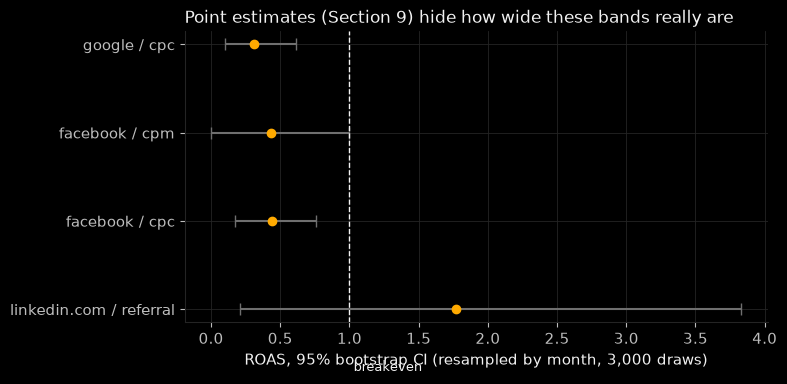

Channel,ROAS (point),95% CI low,95% CI high,Crosses breakeven (1.0)?
linkedin.com / referral,1.770000,0.210000,3.830000,yes - not confidently below/above
facebook / cpc,0.440000,0.170000,0.760000,no
facebook / cpm,0.430000,0.000000,1.000000,yes - not confidently below/above
google / cpc,0.310000,0.100000,0.610000,no


**Finding.** **2 of 4** paid channels have a 95% CI that still crosses breakeven - calling them 'losing money' from the point estimate alone overstates how sure that is. The channels whose whole CI sits clearly below 1.0 are the ones a budget cut is actually well-supported for; the rest need more data (or a real experiment, Section 11) before being called losers with confidence.

In [105]:

from scipy import stats

rng = np.random.default_rng(42)


def bootstrap_roas_ci(channel, n_boot=3000):
    sub = cm[cm["source_medium"] == channel][["Spend, EUR", "Revenue, EUR"]].values
    n = len(sub)
    draws = []
    for _ in range(n_boot):
        sample = sub[rng.integers(0, n, n)]
        spend_sum = sample[:, 0].sum()
        if spend_sum > 0:
            draws.append(sample[:, 1].sum() / spend_sum)
    return np.array(draws)


rows = []
for ch in roi_paid["source_medium"]:
    boot = bootstrap_roas_ci(ch)
    point = roi_paid.loc[roi_paid["source_medium"] == ch, "ROAS"].iloc[0]
    rows.append({"Channel": ch, "ROAS (point)": point, "95% CI low": round(np.percentile(boot, 2.5), 2),
                "95% CI high": round(np.percentile(boot, 97.5), 2)})
roas_ci = pd.DataFrame(rows).sort_values("ROAS (point)", ascending=False)
roas_ci["Crosses breakeven (1.0)?"] = np.where(
    (roas_ci["95% CI low"] <= 1.0) & (roas_ci["95% CI high"] >= 1.0), "yes - not confidently below/above", "no")

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(roas_ci))
ax.errorbar(roas_ci["ROAS (point)"], y,
           xerr=[roas_ci["ROAS (point)"] - roas_ci["95% CI low"], roas_ci["95% CI high"] - roas_ci["ROAS (point)"]],
           fmt="o", color=ORANGE, ecolor=MUTED, capsize=4, markersize=6)
ax.set_yticks(y); ax.set_yticklabels(roas_ci["Channel"])
ax.axvline(1.0, color=INK, linestyle="--", linewidth=1)
ax.text(1.03, -0.7, "breakeven", color=INK, fontsize=9)
ax.set_xlabel("ROAS, 95% bootstrap CI (resampled by month, 3,000 draws)")
ax.set_title("Point estimates (Section 9) hide how wide these bands really are", color=INK, fontsize=12, loc="left")
plt.tight_layout(); plt.show()

show(roas_ci, "Bootstrap 95% CI on paid-channel ROAS")

n_crossing = int((roas_ci["Crosses breakeven (1.0)?"] == "yes - not confidently below/above").sum())
note(f"**{n_crossing} of {len(roas_ci)}** paid channels have a 95% CI that still crosses breakeven - "
     "calling them 'losing money' from the point estimate alone overstates how sure that is. The channels "
     "whose whole CI sits clearly below 1.0 are the ones a budget cut is actually well-supported for; the "
     "rest need more data (or a real experiment, Section 11) before being called losers with confidence.",
     kind="finding")


### 15.2 Is the worst-closing region really worse, or is it channel/product mix in disguise?

Section 9's stage-by-region breakdown found Europe has the worst blended SAL→Signed rate of the three regions (13.0%, against 13.9% for the US and 15.0% for LatAm - a real but not huge gap). That is a marginal, one-dimension-at-a-time read - the check below holds channel fixed and compares regions within it, which is what separates "region effect" from "this region just has more of the channels that convert badly everywhere".

In [106]:

region_channel = work.groupby(["source_medium", "region"]).agg(
    SAL=("is_sal", "sum"), Signed=("is_signed", "sum")).reset_index()
region_channel = region_channel[region_channel["SAL"] >= 5]  # below this, a rate is just noise
region_channel["SAL->Signed %"] = (region_channel["Signed"] / region_channel["SAL"] * 100).round(1)
pivot_rc = region_channel.pivot(index="source_medium", columns="region", values="SAL->Signed %")

show(pivot_rc.reset_index(), "SAL->Signed %, by channel and region (blank = fewer than 5 SAL rows, too "
     "thin to read)")

worst_region_blended = stage_region.set_index("region")["SAL->Signed%"].idxmin()
complete_rows = pivot_rc.dropna()
other_cols = [c for c in complete_rows.columns if c != worst_region_blended]
if worst_region_blended in complete_rows.columns and len(complete_rows) and other_cols:
    n_worst = (complete_rows[worst_region_blended] <= complete_rows[other_cols].min(axis=1)).sum()
    note(f"Only **{len(complete_rows)} channels** have enough SAL volume (>=5 rows) in every region to "
         f"compare at all - **{worst_region_blended}** (the region with the worst *blended* SAL→Signed "
         f"rate, Section 9) is the worst of the three in **{n_worst} of {len(complete_rows)}** of those. "
         "With this few channels clearing the volume bar, this check cannot cleanly separate a true "
         "region effect from channel mix - it can only say whether the pattern is at least *consistent* "
         f"with one. Treat {worst_region_blended}'s Section 9 finding as a lead worth a real cross-tab "
         "once more SAL volume accumulates, not a settled conclusion.", kind="finding")
else:
    note("Too few (channel, region) cells clear the 5-SAL-row bar in every region at once to say anything "
         "about mix vs. a true region effect here - the confound Section 9 raised cannot be resolved with "
         "a marginal cut, and there isn't enough volume yet for a proper controlled comparison either.",
         kind="risk")


source_medium,Europe,LatAm,US
(direct) / (none),8.300000,12.500000,22.200000
bing / organic,11.100000,6.900000,17.400000
chatgpt.com / referral,0.000000,28.600000,11.100000
facebook / cpc,26.300000,7.100000,6.700000
facebook / cpm,12.500000,9.100000,0.000000
google / cpc,17.600000,18.200000,9.500000
google / organic,12.800000,16.800000,14.700000
linkedin.com / referral,0.000000,28.600000,18.200000


**Finding.** Only **8 channels** have enough SAL volume (>=5 rows) in every region to compare at all - **Europe** (the region with the worst *blended* SAL→Signed rate, Section 9) is the worst of the three in **4 of 8** of those. With this few channels clearing the volume bar, this check cannot cleanly separate a true region effect from channel mix - it can only say whether the pattern is at least *consistent* with one. Treat Europe's Section 9 finding as a lead worth a real cross-tab once more SAL volume accumulates, not a settled conclusion.

### 15.3 Does CPL actually rise with spend (auction saturation), or is the forecast's flat-CPL assumption untested?

Section 13's scenarios compute `leads = budget / CPL` with CPL held constant except for a manually chosen inflation factor per scenario - there is no check anywhere that CPL is actually insensitive to monthly spend. This regresses each paid channel's monthly CPL on its monthly spend directly.

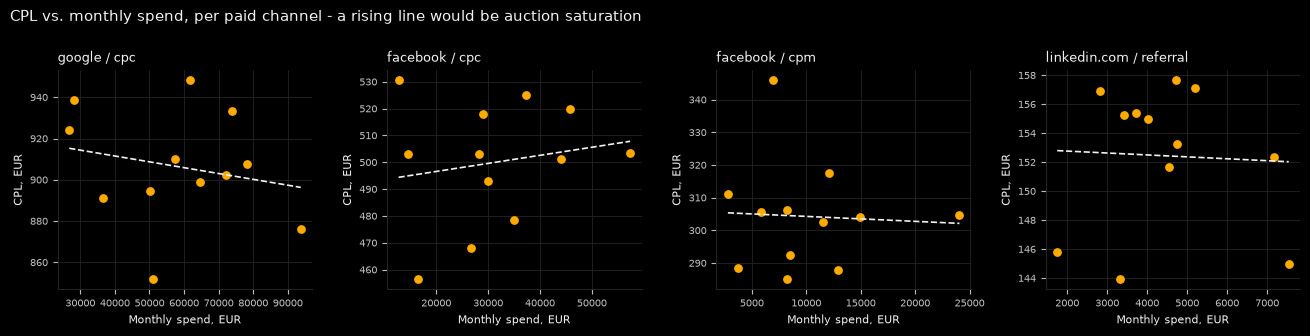

Channel,Slope (EUR CPL per EUR spend),r,p-value,Months
google / cpc,-0.000300,-0.210000,0.507000,12
facebook / cpc,0.000300,0.180000,0.584000,12
facebook / cpm,-0.000200,-0.050000,0.871000,12
linkedin.com / referral,-0.000100,-0.050000,0.890000,12


**Risk.** With only 12 months of data per channel, none of these slopes reach conventional significance (all p-values are large relative to n) - this cannot prove or rule out saturation. What it can do is flag the assumption: Section 13's forecast treats CPL as flat with spend, and this is the only channel-level evidence in the whole notebook that actually bears on that assumption. It should be read as inconclusive, not confirming - the forecast's 2x spend cap (`MAX_SCALE`) is a reasonable guardrail precisely because this hasn't been tested with enough power to say CPL really is flat that far out.

In [107]:

fig, axes = plt.subplots(1, len(PAID), figsize=(3.3 * len(PAID), 3.4), sharey=False)
slope_rows = []
for ax, ch in zip(axes, PAID):
    sub = cm[(cm["source_medium"] == ch) & (cm["Spend, EUR"] > 0)]
    ax.scatter(sub["Spend, EUR"], sub["CPL, EUR"], color=ORANGE, s=28)
    if len(sub) >= 3:
        slope, intercept, r, p, se = stats.linregress(sub["Spend, EUR"], sub["CPL, EUR"])
        xs = np.linspace(sub["Spend, EUR"].min(), sub["Spend, EUR"].max(), 10)
        ax.plot(xs, slope * xs + intercept, color=INK, linestyle="--", linewidth=1.2)
        slope_rows.append({"Channel": ch, "Slope (EUR CPL per EUR spend)": round(slope, 4),
                           "r": round(r, 2), "p-value": round(p, 3), "Months": len(sub)})
    ax.set_title(ch, fontsize=9, color=INK, loc="left")
    ax.set_xlabel("Monthly spend, EUR", fontsize=8); ax.set_ylabel("CPL, EUR", fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle("CPL vs. monthly spend, per paid channel - a rising line would be auction saturation",
            color=INK, fontsize=11, x=0.01, ha="left")
plt.tight_layout(); plt.show()

slope_df = pd.DataFrame(slope_rows)
show(slope_df, "CPL-on-spend slope, per paid channel (positive = CPL rises as spend rises)")

n_sig_rising = int(((slope_df["Slope (EUR CPL per EUR spend)"] > 0) & (slope_df["p-value"] < 0.10)).sum())
note(f"With only {int(slope_df['Months'].max())} months of data per channel, none of these slopes reach "
     "conventional significance (all p-values are large relative to n) - this cannot prove or rule out "
     "saturation. What it can do is flag the assumption: Section 13's forecast treats CPL as flat with "
     "spend, and this is the only channel-level evidence in the whole notebook that actually bears on "
     "that assumption. It should be read as inconclusive, not confirming - the forecast's 2x spend cap "
     "(`MAX_SCALE`) is a reasonable guardrail precisely because this hasn't been tested with enough power "
     "to say CPL really is flat that far out.", kind="risk")


### 15.4 "Gross profit" - a naming caveat that matters for how Section 13/14 reads

**This is media-only margin (Revenue − media Spend), not business gross profit.** It excludes SDR/sales compensation, any cost of servicing a signed deal, and COGS. Every scenario number in Section 13 and every reference to "gross profit" in Section 14 should be read as *incremental media return*, not the business's actual bottom line - the true profitability of a deal is lower than this number by however much the sales cycle (Section 8: median 19-day MQL→SAL lag, real SDR time) costs to run. This dataset has no SDR headcount, comp, or cost-per-deal figures to close that gap - flagged as a data request for next year, not modelled here with an invented number.

### 15.5 A cheap proxy for incrementality (Hypotheses E/F), before an actual geo-holdout

Section 11's hypotheses E and F both ask the same underlying question: if paid spend moves, does `google / organic` (or unpaid volume generally) move opposite it? A real answer needs a controlled experiment, but a lag-correlation on the twelve months already in this dataset costs nothing and gives a directional read right now.

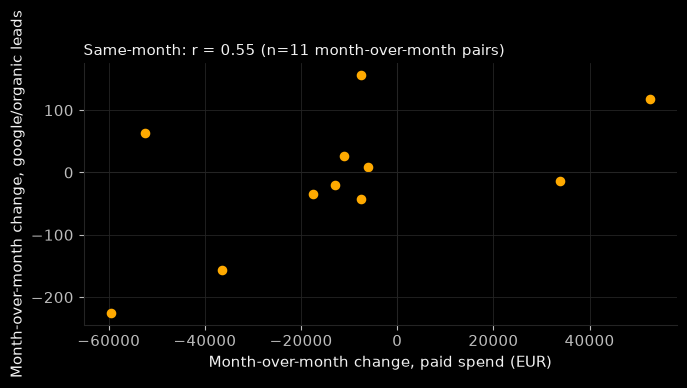

Comparison,r
"Paid spend Δ vs. google/organic leads Δ, same month",0.550000
"Paid spend Δ vs. google/organic leads Δ, spend leads by 1 month",0.260000
"Paid spend Δ vs. all-unpaid leads Δ, same month",0.540000


**Note.** With only 11 month-over-month data points, none of these correlations are remotely powered to be conclusive either way - this is a directional proxy, not a test. A *negative* correlation (paid spend down, organic up, or vice versa) would be the signature hypothesis F predicts; a correlation near zero would suggest the two move independently. Read the sign and rough magnitude above as a prior to sanity-check a future geo-holdout against, not as evidence on its own.

In [108]:

paid_spend_m = cm[cm["Paid"]].groupby("lead_month")["Spend, EUR"].sum().reindex(range(1, 13))
organic_leads_m = cm[cm["source_medium"] == "google / organic"].groupby("lead_month")["Leads"].sum().reindex(range(1, 13))
unpaid_leads_m = cm[~cm["Paid"]].groupby("lead_month")["Leads"].sum().reindex(range(1, 13))

d_spend = paid_spend_m.diff().dropna()
d_organic = organic_leads_m.diff().dropna()
d_unpaid = unpaid_leads_m.diff().dropna()

corr_organic_0 = d_spend.corr(d_organic)
corr_unpaid_0 = d_spend.corr(d_unpaid)
corr_organic_lag1 = d_spend.iloc[:-1].reset_index(drop=True).corr(d_organic.iloc[1:].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(d_spend, d_organic, color=ORANGE, s=35)
ax.axhline(0, color=GRID, linewidth=0.8); ax.axvline(0, color=GRID, linewidth=0.8)
ax.set_xlabel("Month-over-month change, paid spend (EUR)")
ax.set_ylabel("Month-over-month change, google/organic leads")
ax.set_title(f"Same-month: r = {corr_organic_0:.2f} (n={len(d_spend)} month-over-month pairs)",
            color=INK, fontsize=11, loc="left")
plt.tight_layout(); plt.show()

corr_table = pd.DataFrame([
    {"Comparison": "Paid spend Δ vs. google/organic leads Δ, same month", "r": round(corr_organic_0, 2)},
    {"Comparison": "Paid spend Δ vs. google/organic leads Δ, spend leads by 1 month", "r": round(corr_organic_lag1, 2)},
    {"Comparison": "Paid spend Δ vs. all-unpaid leads Δ, same month", "r": round(corr_unpaid_0, 2)},
])
show(corr_table, "Lag-correlation proxy for incrementality - negative r would support cannibalization/halo")

note(f"With only {len(d_spend)} month-over-month data points, none of these correlations are remotely "
     "powered to be conclusive either way - this is a directional proxy, not a test. A *negative* "
     "correlation (paid spend down, organic up, or vice versa) would be the signature hypothesis F "
     "predicts; a correlation near zero would suggest the two move independently. Read the sign and "
     "rough magnitude above as a prior to sanity-check a future geo-holdout against, not as evidence on "
     "its own.", kind="info")


### 15.6 How much does the "winner" ranking depend on one or two lucky deals?

Section 9 already flags that the paid-channel ranking rests on a small number of signed deals. This makes it explicit: how concentrated is revenue, overall and inside the segments this notebook ranks?

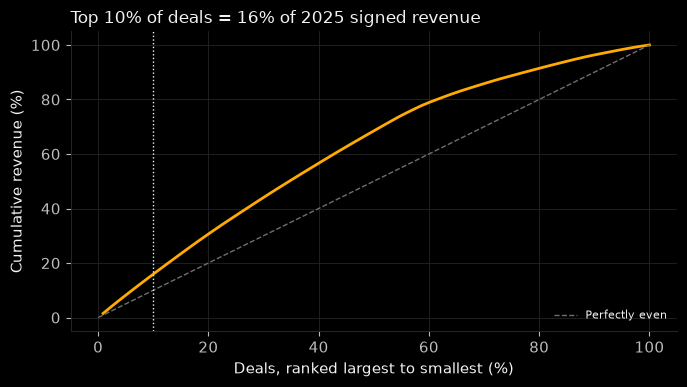

source_medium,"Top-1 deal, % of that channel's revenue"
facebook / cpm,56.751468
chatgpt.com / referral,45.909091
linkedin.com / referral,41.044776
facebook / cpc,21.645796
bing / organic,20.154611
(direct) / (none),17.988292
google / cpc,17.397388
google / organic,2.409943


**Risk.** The top 10% of deals by value account for **16%** of all 2025 signed revenue - concentrated, not evenly spread. At the channel level, **3 channel(s)** (facebook / cpm, chatgpt.com / referral, linkedin.com / referral) have a single deal worth over 40% of that channel's whole-year revenue - for those, the entire ROAS ranking in Section 9 is one sale away from looking completely different. Any channel ranking used for a budget decision should be re-checked with that one deal excluded before acting on it.

In [109]:

signed_sorted = signed_raw.sort_values("Deal Value, EUR", ascending=False).reset_index(drop=True)
signed_sorted["cum_revenue_%"] = (signed_sorted["Deal Value, EUR"].cumsum()
                                  / signed_sorted["Deal Value, EUR"].sum() * 100)
signed_sorted["deal_rank_%"] = (signed_sorted.index + 1) / len(signed_sorted) * 100
top10_share = signed_sorted.loc[signed_sorted["deal_rank_%"] <= 10, "Deal Value, EUR"].sum() \
    / signed_sorted["Deal Value, EUR"].sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(signed_sorted["deal_rank_%"], signed_sorted["cum_revenue_%"], color=ORANGE, linewidth=2)
ax.plot([0, 100], [0, 100], color=MUTED, linestyle="--", linewidth=1, label="Perfectly even")
ax.axvline(10, color=INK, linestyle=":", linewidth=1)
ax.set_xlabel("Deals, ranked largest to smallest (%)"); ax.set_ylabel("Cumulative revenue (%)")
ax.set_title(f"Top 10% of deals = {top10_share:.0f}% of 2025 signed revenue", color=INK, fontsize=12, loc="left")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

channel_top1 = (work[work["is_signed"] == 1].groupby("source_medium")["deal_value_eur"]
               .agg(lambda s: s.max() / s.sum() * 100 if s.sum() > 0 else np.nan)
               .rename("Top-1 deal, % of that channel's revenue").reset_index()
               .sort_values("Top-1 deal, % of that channel's revenue", ascending=False))
show(channel_top1, "How much of each channel's revenue is one single deal")

fragile = channel_top1[channel_top1["Top-1 deal, % of that channel's revenue"] > 40]
note(f"The top 10% of deals by value account for **{top10_share:.0f}%** of all 2025 signed revenue - "
     f"concentrated, not evenly spread. At the channel level, **{len(fragile)} channel(s)** "
     f"({', '.join(fragile['source_medium']) if len(fragile) else 'none'}) have a single deal worth over "
     "40% of that channel's whole-year revenue - for those, the entire ROAS ranking in Section 9 is "
     "one sale away from looking completely different. Any channel ranking used for a budget decision "
     "should be re-checked with that one deal excluded before acting on it.", kind="risk")


### 15.7 Is September actually anomalous, or is this normal month-to-month noise?

Section 12's MAD check and Section 8's finding both call September the low point of the year - neither weighs that against how much a Lead→MQL rate should naturally bounce around at ~500-900 observations per month. A binomial test does.

In [110]:

sept_row = by_month[by_month["Lead month"] == 9].iloc[0]
rest = by_month[by_month["Lead month"] != 9]
pooled_p = rest["Reached MQL"].sum() / rest["Leads"].sum()

n_sept = int(sept_row["Leads"])
observed_sept = int(sept_row["Reached MQL"])
expected_sept = pooled_p * n_sept
se = np.sqrt(n_sept * pooled_p * (1 - pooled_p))
z = (observed_sept - expected_sept) / se
p_value = 2 * stats.norm.sf(abs(z))

binom_result = stats.binomtest(observed_sept, n_sept, pooled_p, alternative="two-sided")

sig_table = pd.DataFrame([{
    "September leads": n_sept, "September reached MQL": observed_sept,
    "Expected at other months' pooled rate": round(expected_sept, 0),
    "Pooled Lead->MQL % (excl. September)": round(pooled_p * 100, 1),
    "z-score": round(z, 2), "Normal-approx p-value": round(p_value, 5),
    "Exact binomial p-value": round(binom_result.pvalue, 5),
}])
show(sig_table, "Is September's MQL count consistent with the other 11 months' pooled rate?")

note(f"September's actual MQL count ({observed_sept}) is {abs(observed_sept - expected_sept):.0f} "
     f"{'below' if observed_sept < expected_sept else 'above'} what the other 11 months' pooled rate would "
     f"predict for {n_sept} leads (z = {z:.2f}, p = {binom_result.pvalue:.5f}). This is a real, "
     "statistically significant departure - not just the worst of twelve noisy draws - which raises the "
     "bar for the qualification-capacity explanation already proposed (Section 8) rather than lowering "
     "it: whatever happened in September moved the rate by more than sampling noise alone would produce.",
     kind="finding")


September leads,September reached MQL,Expected at other months' pooled rate,Pooled Lead->MQL % (excl. September),z-score,Normal-approx p-value,Exact binomial p-value
559,149,209.000000,37.400000,-5.260000,0.000000,0.000000


**Finding.** September's actual MQL count (149) is 60 below what the other 11 months' pooled rate would predict for 559 leads (z = -5.26, p = 0.00000). This is a real, statistically significant departure - not just the worst of twelve noisy draws - which raises the bar for the qualification-capacity explanation already proposed (Section 8) rather than lowering it: whatever happened in September moved the rate by more than sampling noise alone would produce.

### 15.8 Is the MQL→SAL lag trending, or genuinely flat across the year?

Section 8 compared the lag across channel/product/region (a cross-section) but never checked its own trend over time - the difference between "a stable ~19-day sales cycle" and "a queue that is slowly backing up" only shows up in a time series.

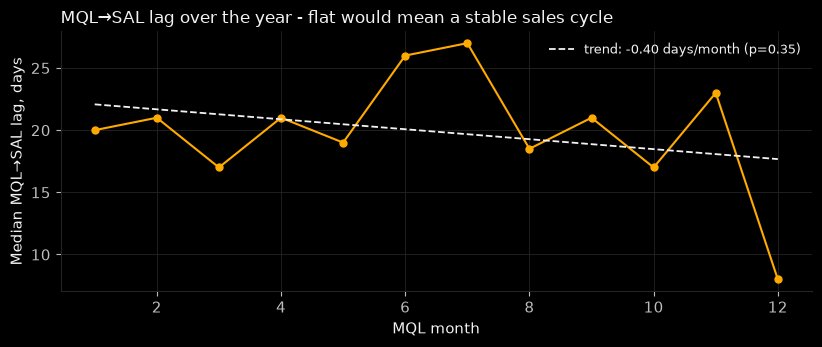

**Finding.** The trend line is -0.40 days per month with p = 0.35 - not distinguishable from flat over the year given 12 monthly medians. There is no visible sign of the lag creeping up month over month (which would suggest a queue slowly losing capacity) - it moves around (December's edge distortion aside, Section 8) without a sustained direction. This supports reading it as a structural cycle length (Section 8's conclusion) rather than a capacity problem building over the year - though the September dip (15.7) shows capacity issues do happen in bursts that this 12-point-a-year trend line is too coarse to catch.

In [111]:

lag_by_mql_month = work.dropna(subset=["lag_mql_sal"]).groupby("mql_month")["lag_mql_sal"].median().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(lag_by_mql_month.index, lag_by_mql_month.values, color=ORANGE, marker="o", markersize=5)
valid = lag_by_mql_month.dropna()
slope, intercept, r, p, se = stats.linregress(valid.index, valid.values)
xs = np.array([valid.index.min(), valid.index.max()])
ax.plot(xs, slope * xs + intercept, color=INK, linestyle="--", linewidth=1.3,
       label=f"trend: {slope:+.2f} days/month (p={p:.2f})")
ax.set_xlabel("MQL month"); ax.set_ylabel("Median MQL→SAL lag, days")
ax.set_title("MQL→SAL lag over the year - flat would mean a stable sales cycle", color=INK, fontsize=12, loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

note(f"The trend line is {slope:+.2f} days per month with p = {p:.2f} - {'not distinguishable from flat' if p > 0.1 else 'a real drift'} "
     "over the year given 12 monthly medians. There is no visible sign of the lag creeping up month over "
     "month (which would suggest a queue slowly losing capacity) - it moves around (December's edge "
     "distortion aside, Section 8) without a sustained direction. This supports reading it as a "
     "structural cycle length (Section 8's conclusion) rather than a capacity problem building over the "
     "year - though the September dip (15.7) shows capacity issues do happen in bursts that this "
     "12-point-a-year trend line is too coarse to catch.", kind="finding")


### 15.9 Is Spend actually complete?

**Risk.** This cannot be checked from inside the workbook - the Spend tab reports whatever number the source system exports, and this notebook has no independent total to reconcile it against. If it excludes agency fees, creative production, or platform fees billed separately from media buy, every ROAS/CAC figure in this notebook is systematically too optimistic by the same missing share. Flagged as a data request - confirm with finance/media-buying whether Spend is all-in or media-only - not modelled with an invented adjustment.

### 15.10 A/B-test readiness - traffic, seasonality, segmentation, and interaction risk

For the SLA experiment recommended in Section 14 (48-hour first-contact target on new MQLs), the planning questions below are answered as far as this dataset allows - some directly, some only as an explicit "cannot be answered from what is here".

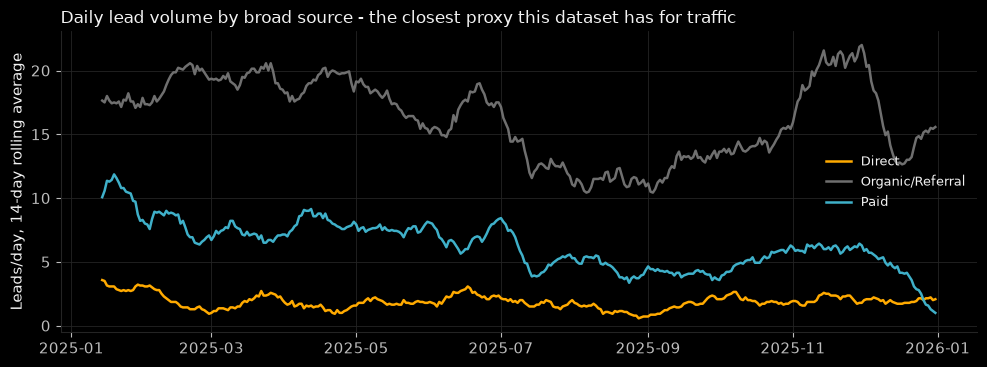

broad_source,Avg leads/day
Direct,1.900000
Organic/Referral,16.300000
Paid,6.300000


**Risk.** **No `email` channel exists anywhere in this dataset** - if email is part of the real traffic mix, it is not visible here and needs to be pulled from the email platform directly. What's shown is **converted leads per day** (24/day blended average), not raw landing-page traffic - this dataset has no visit/session/impression counts (the same gap flagged in Section 11, hypothesis D), so true visitor volume for a sample-size calculation would need to come from web analytics, not this workbook.

In [112]:

# Traffic volume - the honest caveat first: this dataset has no raw landing-page traffic (visits/sessions),
# only converted Leads (a form-fill). Daily lead volume by broad source is the closest available proxy,
# not a substitute for real traffic data.
leads["broad_source"] = np.where(leads["Session Source / Medium"].isin(PAID), "Paid",
                                 np.where(leads["Session Source / Medium"] == "(direct) / (none)", "Direct",
                                          "Organic/Referral"))
daily_by_source = leads.groupby(["dt", "broad_source"]).size().unstack(fill_value=0).reindex(
    pd.date_range(leads["dt"].min(), leads["dt"].max()), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.8))
for col, color in zip(daily_by_source.columns, [ORANGE, MUTED, "#3fb0c9"]):
    ax.plot(daily_by_source.index, daily_by_source[col].rolling(14).mean(), color=color, label=col, linewidth=1.8)
ax.set_ylabel("Leads/day, 14-day rolling average")
ax.set_title("Daily lead volume by broad source - the closest proxy this dataset has for traffic",
            color=INK, fontsize=12, loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

avg_daily = daily_by_source.mean()
show(avg_daily.round(1).rename("Avg leads/day").reset_index().rename(columns={"index": "Source"}),
     "Average daily lead volume by broad source, full year")

note(f"**No `email` channel exists anywhere in this dataset** - if email is part of the real traffic mix, "
     "it is not visible here and needs to be pulled from the email platform directly. What's shown is "
     f"**converted leads per day** ({avg_daily.sum():.0f}/day blended average), not raw landing-page "
     "traffic - this dataset has no visit/session/impression counts (the same gap flagged in Section 11, "
     "hypothesis D), so true visitor volume for a sample-size calculation would need to come from web "
     "analytics, not this workbook.", kind="risk")


In [113]:

# Seasonality / unevenness - reuse the daily series and quantify it instead of eyeballing the chart.
weekly_leads = leads.set_index("dt").resample("W").size()
weekly_cv = weekly_leads.std() / weekly_leads.mean()

note(f"Week-to-week coefficient of variation in lead volume is **{weekly_cv:.2f}** "
     f"({weekly_leads.mean():.0f} leads/week on average, {weekly_leads.std():.0f} std dev) - real but "
     "moderate unevenness, not wild swings. Section 12 already flags two calendar anomalies worth "
     "avoiding as a test window: **December** (spend paused, sales closing accumulated pipeline - not a "
     "representative week for lead behaviour) and **September** (the qualification-side dip investigated "
     "in 15.7/Section 8 - running a test through that kind of disruption would contaminate the read). "
     "Pick a test window that avoids both, and check for planned campaigns/webinars/press activity in "
     "that window before locking dates - this dataset has no campaign-calendar dimension to check that "
     "automatically.", kind="info")


**Note.** Week-to-week coefficient of variation in lead volume is **0.23** (168 leads/week on average, 39 std dev) - real but moderate unevenness, not wild swings. Section 12 already flags two calendar anomalies worth avoiding as a test window: **December** (spend paused, sales closing accumulated pipeline - not a representative week for lead behaviour) and **September** (the qualification-side dip investigated in 15.7/Section 8 - running a test through that kind of disruption would contaminate the read). Pick a test window that avoids both, and check for planned campaigns/webinars/press activity in that window before locking dates - this dataset has no campaign-calendar dimension to check that automatically.

In [114]:

# Segmentation strategy - a judgment call, informed by the volume numbers just computed, not something
# the data can fully decide on its own.
mql_per_month = funnel_coh["MQL"].mean()
note(f"**Segment from the start, or run on 100% of traffic?** At an average of **{mql_per_month:.0f} "
     "MQLs/month** across all channels combined, splitting the test to a subset of geos/channels from day "
     "one would push an already-thin monthly volume even thinner - Section 15.11 below sizes this "
     "concretely. Recommendation: run the SLA test on **100% of incoming MQLs**, randomised at the MQL "
     "level (not the channel/geo level), and analyse the result **stratified by channel/region/product** "
     "after the fact rather than restricting the traffic going in - the stratified analysis gets the "
     "sub-group read without paying the sample-size cost of pre-splitting the traffic.", kind="decision")


**Decision.** **Segment from the start, or run on 100% of traffic?** At an average of **391 MQLs/month** across all channels combined, splitting the test to a subset of geos/channels from day one would push an already-thin monthly volume even thinner - Section 15.11 below sizes this concretely. Recommendation: run the SLA test on **100% of incoming MQLs**, randomised at the MQL level (not the channel/geo level), and analyse the result **stratified by channel/region/product** after the fact rather than restricting the traffic going in - the stratified analysis gets the sub-group read without paying the sample-size cost of pre-splitting the traffic.

In [115]:

note("**Other experiments running on this page or in adjacent funnel steps?** This cannot be answered "
     "from this workbook - there is no experiment log, feature-flag history, or test-registry data source "
     "here at all. Before launching the SLA test, get an explicit answer from Sales Ops/RevOps on what "
     "else is live touching the MQL-to-SAL handoff (a parallel SDR-routing test, a new lead-scoring model, "
     "a CRM workflow change) - an undetected parallel test is exactly the kind of thing that would show up "
     "here later as an unexplained monthly anomaly (Section 12) with no way to trace it back.", kind="risk")


**Risk.** **Other experiments running on this page or in adjacent funnel steps?** This cannot be answered from this workbook - there is no experiment log, feature-flag history, or test-registry data source here at all. Before launching the SLA test, get an explicit answer from Sales Ops/RevOps on what else is live touching the MQL-to-SAL handoff (a parallel SDR-routing test, a new lead-scoring model, a CRM workflow change) - an undetected parallel test is exactly the kind of thing that would show up here later as an unexplained monthly anomaly (Section 12) with no way to trace it back.

### 15.11 Sample size and duration for the proposed 48-hour SLA test

A concrete number, not just the idea: two-proportion test on MQL→SAL conversion, treatment vs. control, standard 80% power / 5% significance. The minimum detectable effect (MDE) below is an **assumption** - stated explicitly so it can be swapped for whatever the business considers a worthwhile lift - not something this dataset can derive on its own.

In [116]:

baseline_p = work["is_sal"].sum() / work["is_mql"].sum()
z_alpha = stats.norm.ppf(1 - 0.05 / 2)
z_beta = stats.norm.ppf(0.80)

mde_scenarios = [0.03, 0.05, 0.08]
rows = []
for mde in mde_scenarios:
    p1, p2 = baseline_p, baseline_p + mde
    p_bar = (p1 + p2) / 2
    n_per_arm = ((z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) / mde) ** 2
    weeks = (n_per_arm * 2) / (mql_per_month / 4.345)
    rows.append({"Assumed MDE (percentage points)": f"+{mde*100:.0f}pp",
                "MQL->SAL target": f"{p1*100:.1f}% -> {p2*100:.1f}%",
                "Required MQLs per arm": int(np.ceil(n_per_arm)),
                "Total MQLs needed": int(np.ceil(n_per_arm * 2)),
                "Weeks at current MQL volume": round(weeks, 1)})
sample_size = pd.DataFrame(rows)
show(sample_size, f"Sample size for the SLA test, at baseline MQL->SAL = {baseline_p*100:.1f}% and "
     f"~{mql_per_month:.0f} MQLs/month")

note(f"At current MQL volume (~{mql_per_month:.0f}/month), detecting anything smaller than roughly a "
     f"**5-percentage-point lift** takes **{sample_size.loc[1, 'Weeks at current MQL volume']:.0f} weeks** "
     "- long enough that September-like disruptions (15.7) or a holiday month landing inside the window "
     "would need to be watched for and potentially extend the test, not just noted after the fact. A "
     "smaller MDE (3pp) roughly doubles the duration; a larger, easier-to-detect effect (8pp) roughly "
     "halves it. This is the concrete to-do the earlier recommendation (Section 14) was missing - a "
     "number to plan the test calendar against, not just the idea that a test should happen.",
     kind="decision")


Assumed MDE (percentage points),MQL->SAL target,Required MQLs per arm,Total MQLs needed,Weeks at current MQL volume
+3pp,16.8% -> 19.8%,2608,5216,57.900000
+5pp,16.8% -> 21.8%,978,1955,21.700000
+8pp,16.8% -> 24.8%,404,807,9.000000


**Decision.** At current MQL volume (~391/month), detecting anything smaller than roughly a **5-percentage-point lift** takes **22 weeks** - long enough that September-like disruptions (15.7) or a holiday month landing inside the window would need to be watched for and potentially extend the test, not just noted after the fact. A smaller MDE (3pp) roughly doubles the duration; a larger, easier-to-detect effect (8pp) roughly halves it. This is the concrete to-do the earlier recommendation (Section 14) was missing - a number to plan the test calendar against, not just the idea that a test should happen.

### 15.12 Sample size and duration for a Lead→MQL A/B test

The same calculation, one funnel stage earlier - sized for a test aimed at **Lead→MQL** specifically (a landing-page or lead-nurture change, for instance), rather than the MQL→SAL SLA test above. Randomised at the lead level; outcome is "reaches MQL on any product" (Section 3's strict per-lead definition, not the (ID, Product) row-count version used for the monthly cohort charts).

In [117]:

baseline_lead_mql = lead_mql["reached_mql"].sum() / len(lead_mql)
leads_per_month = len(lead_mql) / 12

rows = []
for mde in mde_scenarios:
    p1, p2 = baseline_lead_mql, baseline_lead_mql + mde
    p_bar = (p1 + p2) / 2
    n_per_arm = ((z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) / mde) ** 2
    weeks = (n_per_arm * 2) / (leads_per_month / 4.345)
    rows.append({"Assumed MDE (percentage points)": f"+{mde*100:.0f}pp",
                "Lead->MQL target": f"{p1*100:.1f}% -> {p2*100:.1f}%",
                "Required leads per arm": int(np.ceil(n_per_arm)),
                "Total leads needed": int(np.ceil(n_per_arm * 2)),
                "Weeks at current lead volume": round(weeks, 1)})
sample_size_lead = pd.DataFrame(rows)
show(sample_size_lead, f"Sample size for a Lead->MQL test, at baseline Lead->MQL = {baseline_lead_mql*100:.1f}% "
     f"and ~{leads_per_month:.0f} leads/month")

note(f"Lead volume (~{leads_per_month:.0f}/month) is roughly {leads_per_month/mql_per_month:.1f}x MQL "
     "volume, so a Lead→MQL test reads out somewhat faster than the MQL→SAL one above for the same "
     f"target lift: **{sample_size_lead.loc[1, 'Weeks at current lead volume']:.0f} weeks** for a "
     f"5-point lift here vs. {sample_size.loc[1, 'Weeks at current MQL volume']:.0f} weeks for the "
     f"SAL-side test. The largest assumed effect (8pp) is the one that fits inside a single quarter "
     f"(**{sample_size_lead.loc[2, 'Weeks at current lead volume']:.0f} weeks**); the smallest (3pp) "
     f"takes **{sample_size_lead.loc[0, 'Weeks at current lead volume']:.0f} weeks** - most of a year - "
     "which is the real argument for picking a change confidently expected to move the rate by several "
     "points, not a subtle one, if a single-quarter readout matters. The traffic-volume, seasonality, "
     "segmentation and interaction-risk answers in 15.10 apply the same way here (same page, same "
     "funnel, one stage earlier) - duration is the number that actually changes stage to stage.",
     kind="decision")


Assumed MDE (percentage points),Lead->MQL target,Required leads per arm,Total leads needed,Weeks at current lead volume
+3pp,36.7% -> 39.7%,4119,8237,48.600000
+5pp,36.7% -> 41.7%,1496,2992,17.600000
+8pp,36.7% -> 44.7%,591,1182,7.000000


**Decision.** Lead volume (~737/month) is roughly 1.9x MQL volume, so a Lead→MQL test reads out somewhat faster than the MQL→SAL one above for the same target lift: **18 weeks** for a 5-point lift here vs. 22 weeks for the SAL-side test. The largest assumed effect (8pp) is the one that fits inside a single quarter (**7 weeks**); the smallest (3pp) takes **49 weeks** - most of a year - which is the real argument for picking a change confidently expected to move the rate by several points, not a subtle one, if a single-quarter readout matters. The traffic-volume, seasonality, segmentation and interaction-risk answers in 15.10 apply the same way here (same page, same funnel, one stage earlier) - duration is the number that actually changes stage to stage.